In [25]:
import getpass
username = getpass.getuser()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys

# sys.path.append('/Volumes/Neurobio/MICROSCOPE/Kevin/3-Experiments/2-Behavior/5-code/freemoving_100323')


# sys.path.append('/Volumes/Neurobio/MICROSCOPE/Kevin/3-Experiments/2-Behavior/5-code/freemoving/bandit_models')
sys.path.append('/Users/kevinmastro/Library/Mobile Documents/com~apple~CloudDocs/Documents 2/Github/ssm/bandit_models') 
import bandit_plots as bp
import bandit_preprocessing as bpp

sys.path.append('/Users/kevinmastro/Library/Mobile Documents/com~apple~CloudDocs/Documents 2/Github/ssm/bandit_models/bandit_models')
import plot_models_v_mouse as plots
import conditional_probs as cp

%matplotlib inline
sns.set(style='ticks', font_scale=1.6, rc={'axes.labelsize':18, 'axes.titlesize':18}) 


data_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/preprocessed_master_merged_data.csv'
df = pd.read_csv(data_path) 



/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/2142692326.py:28: DtypeWarning: Columns (39,47,50,51,52,53,54,63,64,69,70,75) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


In [26]:
df['Reward'] = (
    df['Reward']
    .map({'Rewarded': 1, 'Unrewarded': 0})
    .fillna(10)
)

In [ ]:
# # Check if NaNs are concentrated in specific sessions or monkeys
# print("NaN distribution by SessionID:")
# print(df[df['Reward'].isna()].groupby('Session_ID').size().sort_values(ascending=False).head(20))

# # Check if there's a pattern with monkey
# if 'Monkey' in df.columns or 'MonkeyID' in df.columns:
#     monkey_col = 'Monkey' if 'Monkey' in df.columns else 'MonkeyID'
#     print(f"\nNaN distribution by {monkey_col}:")
#     print(df[df['Reward'].isna()][monkey_col].value_counts())

# # Check if NaNs are at specific positions in sessions
# print("\nAre NaNs at the beginning/end of sessions?")
# nan_rows = df[df['Reward'].isna()].copy()
# nan_rows['trial_in_session'] = nan_rows.groupby('Session_ID').cumcount() + 1
# print(nan_rows['trial_in_session'].describe())

# # Check a few examples
# print("\nSample rows with NaN Reward:")
# print(df[df['Reward'].isna()][['Session_ID', 'Decision', 'Reward']].head(20))

NaN distribution by SessionID:
Session_ID
2020-12-29_Raven      753
2021-03-16_Griffin    707
2021-03-02_Griffin    702
2021-01-07_Raven      702
2021-02-26_Griffin    673
2021-01-06_Raven      670
2021-01-05_Raven      656
2020-12-16_Raven      654
2021-01-07_Griffin    651
2020-12-16_Griffin    645
2021-03-09_Griffin    644
2021-01-04_Raven      628
2021-02-25_Griffin    628
2021-02-04_Griffin    622
2021-03-08_Griffin    616
2020-12-15_Griffin    616
2021-01-05_Griffin    611
2021-01-04_Griffin    606
2021-03-04_Griffin    604
2021-03-05_Griffin    600
dtype: int64

Are NaNs at the beginning/end of sessions?
count    68809.000000
mean       207.429784
std        147.935891
min          1.000000
25%         89.000000
50%        182.000000
75%        295.000000
max        753.000000
Name: trial_in_session, dtype: float64

Sample rows with NaN Reward:
            Session_ID  Decision  Reward
82906  2021-08-11_Zazu       0.0     NaN
82907  2021-08-11_Zazu       0.0     NaN
82908  2021-0

In [7]:
# Pick one of the sessions with many NaNs (e.g., 2020-12-29_Raven with 753 NaNs)
session_to_examine = '2020-12-29_Raven'

# Get all trials from this session
session_df = df[df['Session_ID'] == session_to_examine].copy()

print(f"Session: {session_to_examine}")
print(f"Total trials: {len(session_df)}")
print(f"Trials with reward info: {session_df['Reward'].notna().sum()}")
print(f"Trials with NaN: {session_df['Reward'].isna().sum()}")
print(f"\nReward value counts:")
print(session_df['Reward'].value_counts(dropna=False))

# Look at all columns to see patterns
print(f"\nAll columns in dataset:")
print(df.columns.tolist())

# Display the full session (or first 50 rows if very long)
print(f"\nFirst 50 trials of session:")
print(session_df.head(50))

# Check for patterns in NaN locations
print(f"\nNaN pattern (1=NaN, 0=has value):")
session_df['is_nan'] = session_df['Reward'].isna().astype(int)
print(session_df[['Decision', 'Reward', 'is_nan']].head(30))

Session: 2020-12-29_Raven
Total trials: 753
Trials with reward info: 753
Trials with NaN: 0

Reward value counts:
Reward
10.0    753
Name: count, dtype: int64

All columns in dataset:
['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition', 'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver', 'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4', 'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1', 'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5', 'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes', 'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1', 'Eye2Offset_2', 'RewardVolume', 'RewardType', 'BlockLength', 'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward', 'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2', 'filename_part_3', 'filename_part_4', 'filename_part_5', 'filename_part_6', 'TaskObject1_Typ

(1000.0, 1050.0)

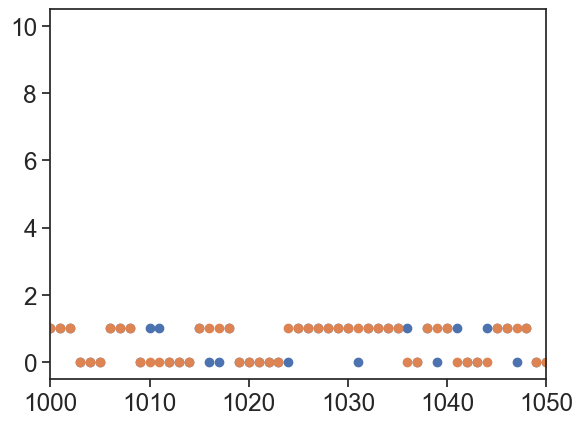

In [8]:
plt.plot(df['Reward'], 'o')
plt.plot(df['Decision'], 'o')

plt.xlim([1000,1050])


In [27]:
import pandas as pd

birth_data = {
    'Animal_Name': [
        'Fiona',
        'Salmon',
        'Zazu',
        'Sunflower',
        'Sonic',
        'Ace',
        'Coral',
        'Knuckles',
        'Rick',
        'Morty'
    ],
    'Birth Date': [
        '02/29/2016',
        '01/10/2021',
        '02/24/2019',
        '08/03/2021',
        '06/09/2022',
        '07/26/2021',
        '08/14/2022',
        '06/09/2022',
        '05/19/2023',
        '05/19/2023'
    ]
}

birth_df = pd.DataFrame(birth_data)
df = df.merge(birth_df, on='Animal_Name', how='left')
# df['Reward'] = df['Reward'].replace({'Rewarded': 1, 'Unrewarded': 0})

# Example dataframe
# df has columns: ['Animal_Name', 'Date', 'Birth Date']
# Make sure both are datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Birth Date'] = pd.to_datetime(df['Birth Date'], errors='coerce')

# --- Compute current age in years ---
df['Current_Age_Years'] = (df['Date'] - df['Birth Date']).dt.days / 365.25

# --- (Optional) also compute in months if you prefer ---
df['Current_Age_Months'] = df['Current_Age_Years'] * 12

# Round if desired
df['Current_Age_Years'] = df['Current_Age_Years'].round(2)
df['Current_Age_Months'] = df['Current_Age_Months'].round(1)

# Check result
print(df[['Animal_Name', 'Date', 'Birth Date', 'Current_Age_Years', 'Current_Age_Months']].head())

tmp_8020 = df[df['prob_Condition']=='80-20']
tmp_8020


  Animal_Name       Date Birth Date  Current_Age_Years  Current_Age_Months
0       Fiona 2024-03-06 2016-02-29               8.02                96.2
1       Fiona 2024-03-06 2016-02-29               8.02                96.2
2       Fiona 2024-03-06 2016-02-29               8.02                96.2
3       Fiona 2024-03-06 2016-02-29               8.02                96.2
4       Fiona 2024-03-06 2016-02-29               8.02                96.2


,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,Task_Type,filename,Birth Date,Current_Age_Years,Current_Age_Months
336,1,1,1,1,1,0,NaN,0.000000e+00,2022,2,...,1.0,1,0.000000,0.000000,NaN,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
337,2,1,2,1,1,0,NaN,2.246574e+04,2022,2,...,1.0,1,22.465744,0.374429,22.465744,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
338,3,1,3,1,1,6,NaN,3.624458e+04,2022,2,...,0.0,1,36.244577,0.604076,13.778833,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
339,4,1,4,1,1,0,NaN,1.285005e+05,2022,2,...,1.0,1,128.500518,2.141675,92.255942,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
340,5,1,5,1,1,0,NaN,1.367672e+05,2022,2,...,1.0,1,136.767240,2.279454,8.266722,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308604,337,17,17,1,1,0,NaN,3.686018e+06,2023,11,...,1.0,1,3686.018455,61.433641,2.766322,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3
308605,338,17,18,1,1,0,NaN,3.692084e+06,2023,11,...,1.0,1,3692.084432,61.534741,6.065978,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3
308606,339,17,19,1,1,0,NaN,3.696984e+06,2023,11,...,1.0,1,3696.983879,61.616398,4.899447,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3
308607,340,17,20,1,1,0,NaN,3.702433e+06,2023,11,...,1.0,1,3702.433299,61.707222,5.449420,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3


In [28]:
tmp_8020.columns.unique()


Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'BlockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Col

In [29]:
tmp_8020.Task_Type.unique()

array(['WhereTask', 'Reversal'], dtype=object)

In [30]:
tmp_8020_wheretask = tmp_8020[tmp_8020['Task_Type'] == 'WhereTask']
tmp_8020_wheretask

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,Task_Type,filename,Birth Date,Current_Age_Years,Current_Age_Months
336,1,1,1,1,1,0,NaN,0.000000e+00,2022,2,...,1.0,1,0.000000,0.000000,NaN,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
337,2,1,2,1,1,0,NaN,2.246574e+04,2022,2,...,1.0,1,22.465744,0.374429,22.465744,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
338,3,1,3,1,1,6,NaN,3.624458e+04,2022,2,...,0.0,1,36.244577,0.604076,13.778833,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
339,4,1,4,1,1,0,NaN,1.285005e+05,2022,2,...,1.0,1,128.500518,2.141675,92.255942,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
340,5,1,5,1,1,0,NaN,1.367672e+05,2022,2,...,1.0,1,136.767240,2.279454,8.266722,WhereTask,20220217 Fiona 100%Con WhereBlocks3.23.csv nan...,2016-02-29,5.97,71.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264730,474,24,14,12,12,0,NaN,4.611027e+06,2021,11,...,1.0,1,4611.026567,76.850443,4.631282,WhereTask,20211115 Griffin 100%Con WhereBlocks3.1.csv na...,NaT,NaN,NaN
264731,475,24,15,12,12,0,NaN,4.614176e+06,2021,11,...,1.0,1,4614.176224,76.902937,3.149657,WhereTask,20211115 Griffin 100%Con WhereBlocks3.1.csv na...,NaT,NaN,NaN
264732,476,24,16,12,12,0,NaN,4.618392e+06,2021,11,...,1.0,1,4618.392331,76.973206,4.216107,WhereTask,20211115 Griffin 100%Con WhereBlocks3.1.csv na...,NaT,NaN,NaN
264733,477,24,17,12,12,0,NaN,4.622542e+06,2021,11,...,1.0,1,4622.541847,77.042364,4.149516,WhereTask,20211115 Griffin 100%Con WhereBlocks3.1.csv na...,NaT,NaN,NaN


In [31]:
tmp_8020_reversal = tmp_8020[tmp_8020['Task_Type'] == 'Reversal']
tmp_8020_reversal

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,Task_Type,filename,Birth Date,Current_Age_Years,Current_Age_Months
4702,1,1,1,5,5,6,NaN,0.000000e+00,2022,4,...,0.0,1,0.000000,0.000000,NaN,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,2016-02-29,6.15,73.8
4703,2,1,2,5,5,0,NaN,1.360519e+05,2022,4,...,1.0,1,136.051937,2.267532,136.051937,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,2016-02-29,6.15,73.8
4704,3,1,3,5,5,0,NaN,1.431673e+05,2022,4,...,1.0,1,143.167328,2.386122,7.115391,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,2016-02-29,6.15,73.8
4705,4,1,4,5,5,6,NaN,1.549159e+05,2022,4,...,0.0,1,154.915893,2.581932,11.748565,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,2016-02-29,6.15,73.8
4706,5,1,5,5,5,0,NaN,1.627993e+05,2022,4,...,1.0,1,162.799264,2.713321,7.883370,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,2016-02-29,6.15,73.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308604,337,17,17,1,1,0,NaN,3.686018e+06,2023,11,...,1.0,1,3686.018455,61.433641,2.766322,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3
308605,338,17,18,1,1,0,NaN,3.692084e+06,2023,11,...,1.0,1,3692.084432,61.534741,6.065978,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3
308606,339,17,19,1,1,0,NaN,3.696984e+06,2023,11,...,1.0,1,3696.983879,61.616398,4.899447,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3
308607,340,17,20,1,1,0,NaN,3.702433e+06,2023,11,...,1.0,1,3702.433299,61.707222,5.449420,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,2021-08-03,2.28,27.3


In [32]:
tmp_8020_reversal['Reward'].unique()

array([0., 1.])

In [33]:
import pandas as pd
import numpy as np

def build_session_summary(df):
    # Ensure correct dtypes
    if not np.issubdtype(df['Date'].dtype, np.datetime64):
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    if 'Birth Date' in df.columns and not np.issubdtype(df['Birth Date'].dtype, np.datetime64):
        df['Birth Date'] = pd.to_datetime(df['Birth Date'], errors='coerce')

    # Trial duration (already computed, but recalculate if needed)
    if 'trial_duration' not in df.columns:
        df['trial_duration'] = df['EndTimes'].astype(float) - df['StartTimes'].astype(float)

    # Previous-trial reward (already exists as 'prev_reward', but ensure it's correct)
    if 'prev_reward' not in df.columns:
        df['prev_reward'] = df.groupby('Session_ID')['Reward'].shift(1)

    # Helper to compute precision/recall/F1 with 1 as positive label
    def prf1(y_true, y_pred):
        # filter valid
        mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
        y_true = pd.Series(y_true)[mask].astype(int)
        y_pred = pd.Series(y_pred)[mask].astype(int)
        if len(y_true) == 0:
            return np.nan, np.nan, np.nan
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = (2 * precision * recall / (precision + recall)) if (precision > 0 and recall > 0) else (0.0 if (precision == 0 or recall == 0) else np.nan)
        return precision, recall, f1

    rows = []
    for sid, sub in df.groupby('Session_ID', sort=False):
        n_trials = len(sub)
        n_rewards = sub['Reward'].sum()
        n_trials_rewarded = int((sub['Reward'] == 1).sum())
        n_trials_not_rewarded = int((sub['Reward'] == 0).sum())
        n_trials_nan_reward = int(sub['Reward'].isna().sum())
        n_switches = sub['Switch'].sum()

        # Means
        iti_mean = sub['ITI'].mean()
        dur_mean = sub['trial_duration'].mean()

        # Previous-trial-conditioned stats
        iti_win = sub.loc[sub['prev_reward'] == 1, 'ITI'].mean()
        iti_loss = sub.loc[sub['prev_reward'] == 0, 'ITI'].mean()

        trial_duration_win = sub.loc[sub['prev_reward'] == 1, 'trial_duration'].mean()
        trial_duration_loss = sub.loc[sub['prev_reward'] == 0, 'trial_duration'].mean()

        # Switch / stay rates
        switch_rate = sub['Switch'].mean()
        stay_rate = 1 - switch_rate if pd.notna(switch_rate) else np.nan

        lose_switch = sub.loc[sub['prev_reward'] == 0, 'Switch'].mean()
        win_switch = sub.loc[sub['prev_reward'] == 1, 'Switch'].mean()
        lose_stay = 1 - lose_switch if pd.notna(lose_switch) else np.nan
        win_stay = 1 - win_switch if pd.notna(win_switch) else np.nan

        # Accuracy & PRF1
        correct = (sub['Decision'] == sub['Target'])
        accuracy = correct.mean()
        precision, recall, f1 = prf1(sub['Target'], sub['Decision'])

        # Reward rate
        reward_rate = n_rewards / n_trials if n_trials > 0 else np.nan

        # Session metadata
        animal = sub['Animal_Name'].mode().iat[0] if not sub['Animal_Name'].mode().empty else sub['Animal_Name'].iloc[0]
        date = sub['Date'].min()
        age_y = sub['Current_Age_Years'].mean()
        age_m = sub['Current_Age_Months'].mean()
        task = sub['Task_Type'].mode().iat[0] if not sub['Task_Type'].mode().empty else sub['Task_Type'].iloc[0]

        # Additional stats
        mean_reaction_time = sub['ReactionTime'].mean()
        n_blocks = sub['Block'].nunique()

        rows.append({
            'Session_ID': sid,
            'Animal_Name': animal,
            'Date': date,
            'Task_Type': task,
            'Current_Age_Years': age_y,
            'Current_Age_Months': age_m,

            'n_trials': n_trials,
            'n_trials_rewarded': n_trials_rewarded,
            'n_trials_not_rewarded': n_trials_not_rewarded,
            'n_trials_nan_reward': n_trials_nan_reward,
            'n_rewards': n_rewards,
            'n_switches': n_switches,
            'n_blocks': n_blocks,

            'reward_rate': reward_rate,
            'switch_rate': switch_rate,
            'stay_rate': stay_rate,

            'iti_mean': iti_mean,
            'iti_win_prev1': iti_win,
            'iti_loss_prev0': iti_loss,

            'trial_duration_mean': dur_mean,
            'trial_duration_win_prev1': trial_duration_win,
            'trial_duration_loss_prev0': trial_duration_loss,

            'mean_reaction_time': mean_reaction_time,

            'win_switch_rate_prev1': win_switch,
            'lose_switch_rate_prev0': lose_switch,
            'win_stay_rate_prev1': win_stay,
            'lose_stay_rate_prev0': lose_stay,

            'accuracy': accuracy,
            'precision_pos1': precision,
            'recall_pos1': recall,
            'f1_pos1': f1
        })

    summary_df = pd.DataFrame(rows).sort_values(['Animal_Name', 'Date', 'Session_ID']).reset_index(drop=True)
    return summary_df

# ---- run it ----
# tmp_8020 = df[df['prob_Condition']=='80-20']
summary_df = build_session_summary(tmp_8020_reversal)

# Quick peek
print(summary_df.head())
print(f"\nTotal sessions: {len(summary_df)}")

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/971745638.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trial_duration'] = df['EndTimes'].astype(float) - df['StartTimes'].astype(float)
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/971745638.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prev_reward'] = df.groupby('Session_ID')['Reward'].shift(1)


         Session_ID Animal_Name       Date Task_Type  Current_Age_Years  \
0  2022-04-25_Fiona       Fiona 2022-04-25  Reversal               6.15   
1  2022-04-26_Fiona       Fiona 2022-04-26  Reversal               6.15   
2  2022-05-02_Fiona       Fiona 2022-05-02  Reversal               6.17   
3  2022-05-03_Fiona       Fiona 2022-05-03  Reversal               6.17   
4  2022-05-04_Fiona       Fiona 2022-05-04  Reversal               6.18   

   Current_Age_Months  n_trials  n_trials_rewarded  n_trials_not_rewarded  \
0                73.8       497                303                    194   
1                73.9       378                231                    147   
2                74.1       432                270                    162   
3                74.1       181                112                     69   
4                74.1       263                174                     89   

   n_trials_nan_reward  ...  trial_duration_loss_prev0  mean_reaction_time  \
0       

In [105]:
for sid, sub in df.groupby('Session_ID', sort=False):
    n_trials = len(sub)
    print(sub.Reward.sum())
    

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


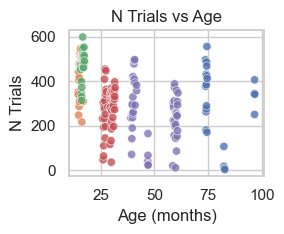

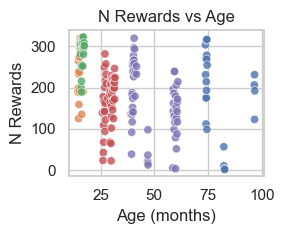

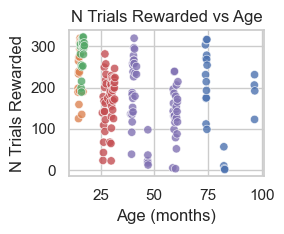

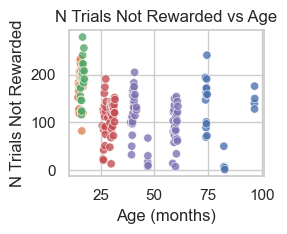

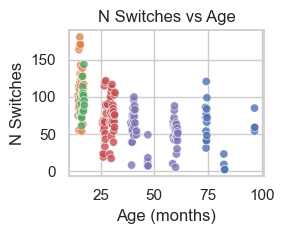

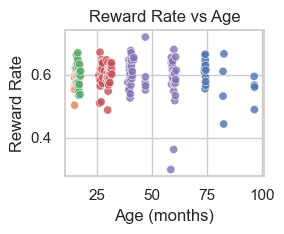

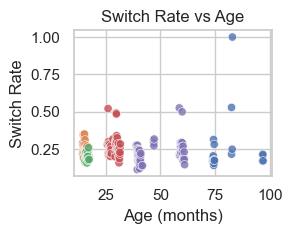

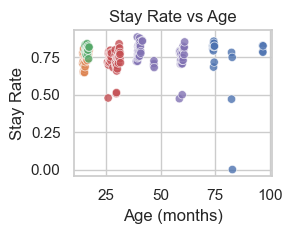

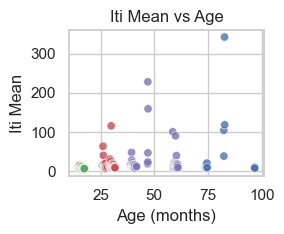

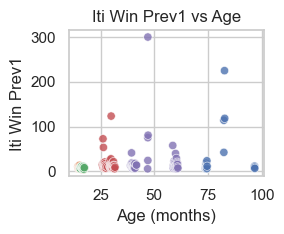

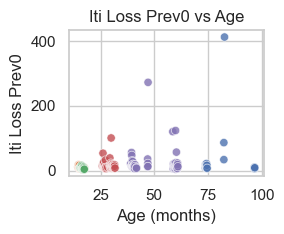

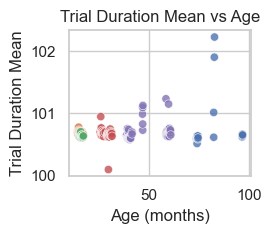

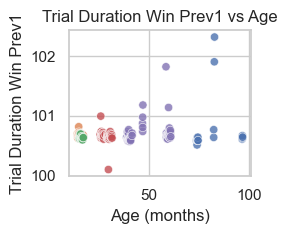

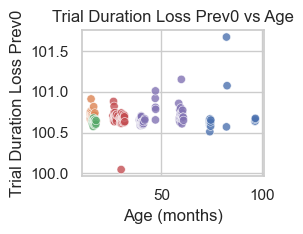

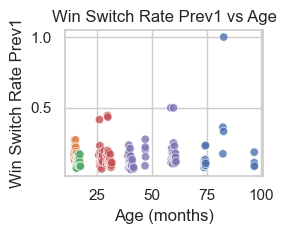

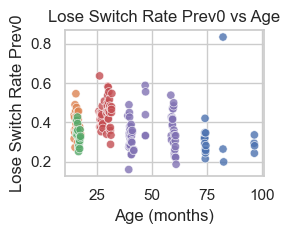

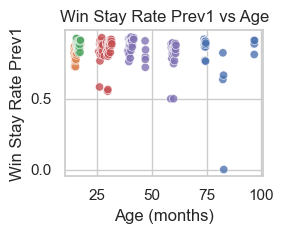

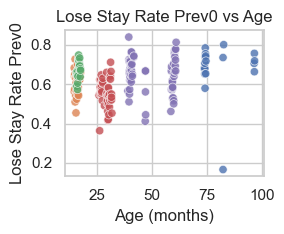

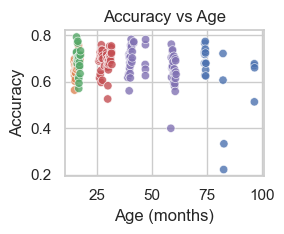

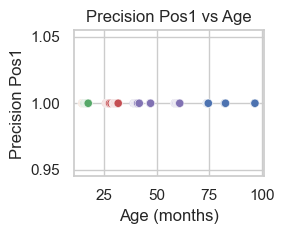

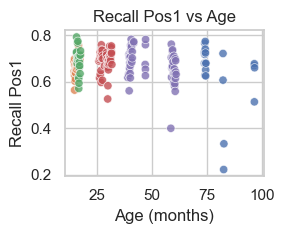

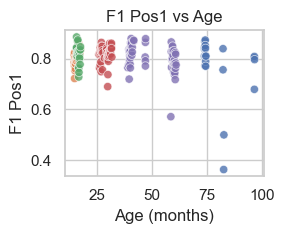

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_of_interest = [
    'n_trials', 'n_rewards', 'n_trials_rewarded', 'n_trials_not_rewarded',
    'n_switches', 'reward_rate', 'switch_rate', 'stay_rate', 'iti_mean',
    'iti_win_prev1', 'iti_loss_prev0', 'trial_duration_mean',
    'trial_duration_win_prev1', 'trial_duration_loss_prev0',
    'win_switch_rate_prev1', 'lose_switch_rate_prev0',
    'win_stay_rate_prev1', 'lose_stay_rate_prev0',
    'accuracy', 'precision_pos1', 'recall_pos1', 'f1_pos1'
]

# Use seaborn styling
sns.set(style='whitegrid')

# Loop and plot each variable vs age
for col in cols_of_interest:
    if col not in summary_df.columns:
        print(f"⚠️ Skipping {col}: not found in dataframe.")
        continue

    plt.figure(figsize=(3, 2.5))
    sns.scatterplot(
        data=summary_df,
        x='Current_Age_Months',  # or 'Current_Age_Years' if preferred
        y=col,
        hue='Animal_Name',
        alpha=0.8
    )


    plt.xlabel('Age (months)')
    plt.ylabel(col.replace('_', ' ').title())
    plt.title(f'{col.replace("_", " ").title()} vs Age')
    plt.tight_layout()
    plt.legend().set_visible(False)  # ensures no legend appears

    plt.show()


In [35]:
for col in summary_df.columns:
    print(col)

Session_ID
Animal_Name
Date
Task_Type
Current_Age_Years
Current_Age_Months
n_trials
n_trials_rewarded
n_trials_not_rewarded
n_trials_nan_reward
n_rewards
n_switches
n_blocks
reward_rate
switch_rate
stay_rate
iti_mean
iti_win_prev1
iti_loss_prev0
trial_duration_mean
trial_duration_win_prev1
trial_duration_loss_prev0
mean_reaction_time
win_switch_rate_prev1
lose_switch_rate_prev0
win_stay_rate_prev1
lose_stay_rate_prev0
accuracy
precision_pos1
recall_pos1
f1_pos1


Pearson r: -0.336, p-value: 0.000
Spearman r: -0.318, p-value: 0.000


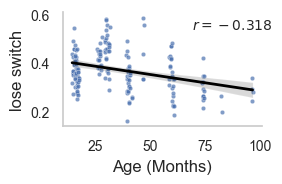

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(3, 2))

summary_df_filtered = summary_df[summary_df['switch_rate']<0.5]
# Scatter plot with different colors for each animal
# sns.scatterplot(data=summary_df_filtered, x='Current_Age_Months', y='lose_switch_rate_prev0', 
                # hue='Animal_Name', s=10, alpha=0.7)
sns.scatterplot(data=summary_df_filtered, x='Current_Age_Months', y='lose_switch_rate_prev0', 
                 s=10, alpha=0.7)

# Add a regression line
sns.regplot(data=summary_df_filtered, x='Current_Age_Months', y='lose_switch_rate_prev0', 
            scatter=False, color='black', line_kws={'linewidth': 2, 'linestyle': '-'})

plt.xlabel('Age (Months)', fontsize=12)
plt.ylabel('lose switch', fontsize=12)
# plt.title('Switch Rate vs Age', fontsize=14, fontweight='bold')
plt.grid(False)
# plt.legend(title='Animal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
sns.despine()
# add tick marks for x and y axis to 0.5 thickness
plt.tick_params(axis='both', which='major', width=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Optional: Print correlation
from scipy.stats import pearsonr, spearmanr

# Remove any NaN values for correlation
valid_data = summary_df_filtered[['Current_Age_Months', 'lose_switch_rate_prev0']].dropna()

r_pearson, p_pearson = pearsonr(
    valid_data['Current_Age_Months'],
    valid_data['lose_switch_rate_prev0']
)
r_spearman, p_spearman = spearmanr(
    valid_data['Current_Age_Months'],
    valid_data['lose_switch_rate_prev0']
)
print(f"Pearson r: {r_pearson:.3f}, p-value: {p_pearson:.3f}")
print(f"Spearman r: {r_spearman:.3f}, p-value: {p_spearman:.3f}")

# Compute R^2
r = r_spearman 

# Get current axis
ax = plt.gca()

# Annotate R^2 on the plot
ax.text(
    0.65, 0.95,
    f"$r = {r:.3f}$",
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=10
)

# print correlation coefficients and p-values on graph
fig_path = "/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/forVictoria/2-outputs/1-Marmoset_8020"
# save as svg, make sure text is perserved
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(os.path.join(fig_path, 'lose_switch_rate_vs_age_WHEREtask.svg'), format='svg', dpi=300)
plt.show()



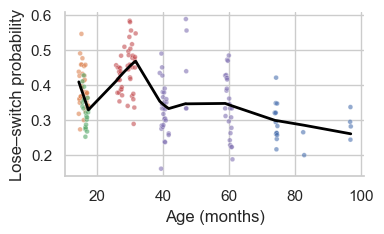

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Create a local plotting dataframe (DO NOT TOUCH MASTER)
plot_df = summary_df_filtered[
    ['Current_Age_Months', 'lose_switch_rate_prev0', 'Animal_Name']
].dropna().copy()

# LOWESS fit (descriptive)
lowess_fit = lowess(
    plot_df['lose_switch_rate_prev0'],
    plot_df['Current_Age_Months'],
    frac=0.35
)

plt.figure(figsize=(4, 2.5))

sns.scatterplot(
    data=plot_df,
    x='Current_Age_Months',
    y='lose_switch_rate_prev0',
    hue='Animal_Name',
    s=12,
    alpha=0.6,
    legend=False
)

plt.plot(
    lowess_fit[:, 0],
    lowess_fit[:, 1],
    color='black',
    linewidth=2
)

plt.xlabel('Age (months)')
plt.ylabel('Lose–switch probability')
plt.tight_layout()
sns.despine()
plt.show()


In [38]:
import statsmodels.formula.api as smf
import numpy as np

summary_df_filtered['age_c'] = summary_df_filtered['Current_Age_Months'] - summary_df_filtered['Current_Age_Months'].mean()

m_lin = smf.ols('lose_switch_rate_prev0 ~ age_c', data=summary_df_filtered).fit(cov_type='HC3')
m_quad = smf.ols('lose_switch_rate_prev0 ~ age_c + I(age_c**2)', data=summary_df_filtered).fit(cov_type='HC3')

print("Linear AIC:", m_lin.aic)
print("Quadratic AIC:", m_quad.aic)
print(m_quad.summary())


Linear AIC: -399.0586975020449
Quadratic AIC: -404.25419197816916
                              OLS Regression Results                              
Dep. Variable:     lose_switch_rate_prev0   R-squared:                       0.148
Model:                                OLS   Adj. R-squared:                  0.138
Method:                     Least Squares   F-statistic:                     16.86
Date:                    Wed, 07 Jan 2026   Prob (F-statistic):           1.96e-07
Time:                            16:59:38   Log-Likelihood:                 205.13
No. Observations:                     182   AIC:                            -404.3
Df Residuals:                         179   BIC:                            -394.6
Df Model:                               2                                         
Covariance Type:                      HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/1486787389.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df_filtered['age_c'] = summary_df_filtered['Current_Age_Months'] - summary_df_filtered['Current_Age_Months'].mean()


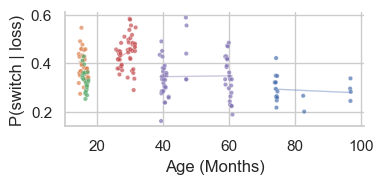

In [39]:
plt.figure(figsize=(4, 2))

sns.scatterplot(
    data=summary_df_filtered,
    x='Current_Age_Months',
    y='lose_switch_rate_prev0',
    hue='Animal_Name',
    s=10,
    alpha=0.7,
    legend=False
)

# plot per-animal regression lines
for animal, df_a in summary_df_filtered.groupby('Animal_Name'):
    if len(df_a) >= 3:
        sns.regplot(
            data=df_a,
            x='Current_Age_Months',
            y='lose_switch_rate_prev0',
            scatter=False,
            ci=None,
            line_kws={'alpha': 0.4, 'linewidth': 1}
        )

plt.xlabel('Age (Months)')
plt.ylabel('P(switch | loss)')
sns.despine()
plt.tight_layout()
plt.show()


In [40]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "lose_switch_rate_prev0 ~ Current_Age_Months",
    summary_df_filtered,
    groups=summary_df_filtered["Animal_Name"]
)

result = model.fit()
print(result.summary())


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: lose_switch_rate_prev0
No. Observations: 182     Method:             REML                  
No. Groups:       5       Scale:              0.0048                
Min. group size:  20      Log-Likelihood:     211.5544              
Max. group size:  58      Converged:          Yes                   
Mean group size:  36.4                                              
---------------------------------------------------------------------
                      Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept              0.377     0.037  10.333  0.000   0.306   0.449
Current_Age_Months    -0.000     0.001  -0.661  0.508  -0.002   0.001
Group Var              0.003     0.035                               



/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [41]:
import statsmodels.api as sm

X = summary_df_filtered['Current_Age_Months']
y = summary_df_filtered['lose_switch_rate_prev0']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type='HC3')  # robust SEs
print(model.summary())


                              OLS Regression Results                              
Dep. Variable:     lose_switch_rate_prev0   R-squared:                       0.113
Model:                                OLS   Adj. R-squared:                  0.108
Method:                     Least Squares   F-statistic:                     32.78
Date:                    Wed, 07 Jan 2026   Prob (F-statistic):           4.25e-08
Time:                            16:59:47   Log-Likelihood:                 201.53
No. Observations:                     182   AIC:                            -399.1
Df Residuals:                         180   BIC:                            -392.7
Df Model:                               1                                         
Covariance Type:                      HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

behavior_features = [
    'switch_rate',
    'win_stay_rate_prev1',
    'lose_switch_rate_prev0',
    # 'mean_reaction_time',
    'iti_mean'
]

X = summary_df[behavior_features].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.65096465 0.24407947 0.10325927 0.00169662]


In [43]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=behavior_features
)

print(loadings[['PC1', 'PC2']])


                             PC1       PC2
switch_rate             0.604305 -0.190633
win_stay_rate_prev1    -0.553652 -0.204040
lose_switch_rate_prev0  0.468426 -0.549757
iti_mean                0.329943  0.787270


In [44]:
summary_df.loc[X.index, 'PC1'] = X_pca[:, 0]
summary_df.loc[X.index, 'PC2'] = X_pca[:, 1]


In [45]:
import statsmodels.api as sm

df = summary_df.loc[X.index, ['Current_Age_Months', 'PC1', 'PC2']].dropna()
X_age = sm.add_constant(df['Current_Age_Months'])

m1 = sm.OLS(df['PC1'], X_age).fit(cov_type='HC3')
m2 = sm.OLS(df['PC2'], X_age).fit(cov_type='HC3')

print("PC1 ~ age"); print(m1.summary())
print("\nPC2 ~ age"); print(m2.summary())


PC1 ~ age
                            OLS Regression Results                            
Dep. Variable:                    PC1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1347
Date:                Wed, 07 Jan 2026   Prob (F-statistic):              0.714
Time:                        16:59:53   Log-Likelihood:                -352.83
No. Observations:                 186   AIC:                             709.7
Df Residuals:                     184   BIC:                             716.1
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0

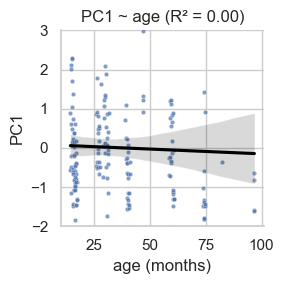

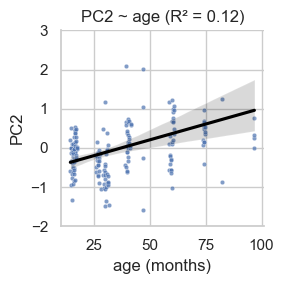

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

for pc in ['PC1','PC2']:
    plt.figure(figsize=(3,3))
    sns.scatterplot(data=df, x='Current_Age_Months', y=pc, s=10, alpha=0.7)
    sns.regplot(data=df, x='Current_Age_Months', y=pc, scatter=False, color='black', line_kws={'linestyle':'-'})
    # add R^2
    r2 = df[[pc, 'Current_Age_Months']].corr().iloc[0, 1]**2
    plt.title(f'{pc} ~ age (R² = {r2:.2f})')
    plt.xlabel('age (months)')
    plt.ylim([-2,3])
    plt.tight_layout(); sns.despine(); plt.show()


In [47]:
import numpy as np
import statsmodels.api as sm

df = summary_df.loc[X.index, ['Current_Age_Months', 'PC2']].dropna()

# Winsorize PC2 at 5–95%
low, high = np.percentile(df['PC2'], [10, 90])
df['PC2_w'] = df['PC2'].clip(low, high)

X_age = sm.add_constant(df['Current_Age_Months'])
m_w = sm.OLS(df['PC2_w'], X_age).fit(cov_type='HC3')
print(m_w.summary())


                            OLS Regression Results                            
Dep. Variable:                  PC2_w   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     39.28
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           2.54e-09
Time:                        16:59:58   Log-Likelihood:                -121.11
No. Observations:                 186   AIC:                             246.2
Df Residuals:                     184   BIC:                             252.7
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.4406      0

In [48]:
import statsmodels.api as sm

df_iti = summary_df[['Current_Age_Months', 'iti_mean']].dropna()

X = sm.add_constant(df_iti['Current_Age_Months'])
m_iti = sm.OLS(df_iti['iti_mean'], X).fit(cov_type='HC3')

print(m_iti.summary())


                            OLS Regression Results                            
Dep. Variable:               iti_mean   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     4.794
Date:                Wed, 07 Jan 2026   Prob (F-statistic):             0.0298
Time:                        17:00:02   Log-Likelihood:                -922.06
No. Observations:                 187   AIC:                             1848.
Df Residuals:                     185   BIC:                             1855.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.8425      5

## Building on Lose-switch behavior: Thinking about new metrics that are more senstive 

In [120]:
# ============================================================
# Compute "number of losses to switch" per session
# Primary metric: consecutive losses-to-switch (CLS)
# Optional metric: losses-since-last-switch (LSLS)
#
# Requirements in trial-level df:
#   - Session_ID
#   - Decision (0/1)
#   - Reward (0/1)
#
# This code does NOT modify your master dataframe in place.
# ============================================================

import numpy as np
import pandas as pd

def compute_losses_to_switch_for_session(session_df):
    """
    Returns a DataFrame with one row per switch event containing:
      - CLS: consecutive losses immediately before the switch (recommended)
      - LSLS: number of losses since last switch (optional)
    """
    # --- Make a safe copy and ensure stable trial order ---
    s = session_df[['Session_ID', 'Decision', 'Reward']].copy()

    # If your df index is chronological trial order, keep it; otherwise replace with explicit Trial column
    s = s.sort_index()

    # --- Drop rows with missing Decision or Reward ---
    s = s.dropna(subset=['Decision', 'Reward']).copy()

    # Need at least 2 trials to define a switch
    if len(s) < 2:
        return pd.DataFrame(columns=['Session_ID', 'switch_trial_idx', 'CLS', 'LSLS'])

    decisions = s['Decision'].to_numpy(dtype=float)
    rewards   = s['Reward'].to_numpy(dtype=float)

    # Identify switch trials t where Decision[t] != Decision[t-1]
    switches = np.where(decisions[1:] != decisions[:-1])[0] + 1  # indices in the array

    out_rows = []
    last_switch_idx = 0  # track last switch boundary for LSLS

    for t in switches:
        # We define the "pre-switch choice" as the choice at t-1
        pre_choice = decisions[t - 1]

        # ----------------------------
        # CLS: consecutive losses immediately prior to switch
        # ----------------------------
        cls = 0
        j = t - 1
        while j >= 0:
            # Stop if choice changed (we crossed a previous switch boundary)
            if decisions[j] != pre_choice:
                break
            # Count only consecutive losses; stop at first win
            if rewards[j] == 0:
                cls += 1
                j -= 1
            else:
                break

        # ----------------------------
        # LSLS: total losses since last switch (optional)
        # ----------------------------
        # Count losses from last_switch_idx ... t-1 (inclusive), on the pre-switch segment.
        # Note: segment includes wins; this is NOT "consecutive."
        seg_rewards = rewards[last_switch_idx:t]  # trials since last switch up to (not including) switch trial t
        lsls = int(np.sum(seg_rewards == 0))

        out_rows.append({
            'Session_ID': s['Session_ID'].iloc[0],
            'switch_trial_idx': s.index[t],   # keeps your original index as the "trial id"
            'CLS': cls,
            'LSLS': lsls
        })

        last_switch_idx = t  # update boundary

    return pd.DataFrame(out_rows)


def compute_session_level_losses_to_switch(trial_df):
    """
    Produces:
      1) switch_event_df: one row per switch event (CLS/LSLS)
      2) session_summary_df: per-session summary stats of CLS/LSLS
    """
    tmp_trials = trial_df[['Session_ID', 'Decision', 'Reward']].copy()

    # --- Compute switch-event metrics per session ---
    switch_event_df = (
        tmp_trials
        .groupby('Session_ID', group_keys=False)
        .apply(compute_losses_to_switch_for_session)
        .reset_index(drop=True)
    )

    # --- Session-level summaries ---
    if len(switch_event_df) == 0:
        session_summary_df = pd.DataFrame(columns=[
            'Session_ID', 'n_switch_events',
            'CLS_mean', 'CLS_median', 'CLS_p75',
            'LSLS_mean', 'LSLS_median'
        ])
        return switch_event_df, session_summary_df

    session_summary_df = (
        switch_event_df
        .groupby('Session_ID')
        .agg(
            n_switch_events=('CLS', 'size'),
            CLS_mean=('CLS', 'mean'),
            CLS_median=('CLS', 'median'),
            CLS_p75=('CLS', lambda x: np.percentile(x, 75)),
            LSLS_mean=('LSLS', 'mean'),
            LSLS_median=('LSLS', 'median'),
        )
        .reset_index()
    )

    return switch_event_df, session_summary_df


# ============================================================
# Example usage (using your trial-level dataframe)
# ============================================================

# --- Use your trial-level df; do NOT use master df ---
trial_df_tmp = tmp_8020_reversal[['Session_ID', 'Decision', 'Reward']].copy()

switch_event_df, session_loss_summary_df = compute_session_level_losses_to_switch(trial_df_tmp)

print(session_loss_summary_df.head())
print(switch_event_df.head())


         Session_ID  n_switch_events  CLS_mean  CLS_median  CLS_p75  \
0  2022-04-25_Fiona               86  1.348837         1.0     2.00   
1  2022-04-26_Fiona               73  1.123288         1.0     2.00   
2  2022-05-02_Fiona               77  1.207792         1.0     2.00   
3  2022-05-03_Fiona               31  1.129032         1.0     2.00   
4  2022-05-04_Fiona               54  1.055556         1.0     1.75   

   LSLS_mean  LSLS_median  
0   2.244186          2.0  
1   2.013699          1.0  
2   2.077922          2.0  
3   2.161290          2.0  
4   1.648148          1.0  
         Session_ID  switch_trial_idx  CLS  LSLS
0  2022-04-25_Fiona              4703    1     1
1  2022-04-25_Fiona              4705    0     0
2  2022-04-25_Fiona              4706    1     1
3  2022-04-25_Fiona              4708    0     0
4  2022-04-25_Fiona              4711    3     3


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/2453828937.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_trials


In [121]:
# ============================================================
# A) Fix the pandas DeprecationWarning (groupby.apply)
#    - We explicitly select only the needed columns
#    - This avoids apply receiving grouping columns implicitly
# ============================================================

import numpy as np
import pandas as pd

def compute_session_level_losses_to_switch(trial_df):
    """
    Produces:
      1) switch_event_df: one row per switch event (CLS/LSLS)
      2) session_summary_df: per-session summary stats (two variants):
          - CLS_mean_all: includes CLS=0 events (switches not preceded by loss)
          - CLS_mean_loss: excludes CLS=0 events (strict "losses to switch")
    """
    # --- Select only required columns (prevents groupby.apply deprecation behavior) ---
    tmp_trials = trial_df.loc[:, ['Session_ID', 'Decision', 'Reward']].copy()

    # --- Compute switch-event metrics per session ---
    switch_event_df = (
        tmp_trials
        .groupby('Session_ID', group_keys=False)[['Session_ID', 'Decision', 'Reward']]
        .apply(compute_losses_to_switch_for_session)
        .reset_index(drop=True)
    )

    # --- Session-level summaries ---
    if len(switch_event_df) == 0:
        session_summary_df = pd.DataFrame(columns=[
            'Session_ID', 'n_switch_events',
            'CLS_mean_all', 'CLS_median_all', 'CLS_p75_all',
            'CLS_mean_loss', 'CLS_median_loss', 'CLS_p75_loss',
            'LSLS_mean', 'LSLS_median'
        ])
        return switch_event_df, session_summary_df

    # Variant 1: include CLS=0 (switches after win / after non-loss)
    g_all = (
        switch_event_df
        .groupby('Session_ID')
        .agg(
            n_switch_events=('CLS', 'size'),
            CLS_mean_all=('CLS', 'mean'),
            CLS_median_all=('CLS', 'median'),
            CLS_p75_all=('CLS', lambda x: np.percentile(x, 75)),
            LSLS_mean=('LSLS', 'mean'),
            LSLS_median=('LSLS', 'median'),
        )
        .reset_index()
    )

    # Variant 2: strict losses-to-switch (exclude CLS=0)
    switch_event_loss = switch_event_df[switch_event_df['CLS'] > 0].copy()

    g_loss = (
        switch_event_loss
        .groupby('Session_ID')
        .agg(
            CLS_mean_loss=('CLS', 'mean'),
            CLS_median_loss=('CLS', 'median'),
            CLS_p75_loss=('CLS', lambda x: np.percentile(x, 75)),
        )
        .reset_index()
    )

    # Merge both summaries
    session_summary_df = g_all.merge(g_loss, on='Session_ID', how='left')

    return switch_event_df, session_summary_df


# --- Recompute using your trial df (safe copy) ---
trial_df_tmp = tmp_8020_reversal[['Session_ID', 'Decision', 'Reward']].copy()
switch_event_df, session_loss_summary_df = compute_session_level_losses_to_switch(trial_df_tmp)

print(session_loss_summary_df.head())
print("Switch events total:", len(switch_event_df))
print("Switch events with CLS>0:", (switch_event_df['CLS'] > 0).sum())
print("Fraction CLS==0:", (switch_event_df['CLS'] == 0).mean())


         Session_ID  n_switch_events  CLS_mean_all  CLS_median_all  \
0  2022-04-25_Fiona               86      1.348837             1.0   
1  2022-04-26_Fiona               73      1.123288             1.0   
2  2022-05-02_Fiona               77      1.207792             1.0   
3  2022-05-03_Fiona               31      1.129032             1.0   
4  2022-05-04_Fiona               54      1.055556             1.0   

   CLS_p75_all  LSLS_mean  LSLS_median  CLS_mean_loss  CLS_median_loss  \
0         2.00   2.244186          2.0       1.870968              1.0   
1         2.00   2.013699          1.0       1.744681              2.0   
2         2.00   2.077922          2.0       1.788462              2.0   
3         2.00   2.161290          2.0       1.750000              1.0   
4         1.75   1.648148          1.0       1.838710              1.0   

   CLS_p75_loss  
0          2.75  
1          2.00  
2          2.00  
3          2.00  
4          3.00  
Switch events total: 14054

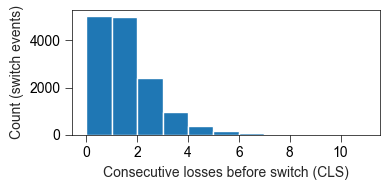

count    14054.000000
mean         1.114914
std          1.206597
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: CLS, dtype: float64
count    9015.000000
mean        1.738103
std         1.089243
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: CLS, dtype: float64


In [122]:
# ============================================================
# B) Sanity checks: make sure CLS behaves as expected
#    - CLS should generally be small (often 1–3) in probabilistic tasks
#    - Check distribution + whether CLS==0 is common (it can be!)
# ============================================================

import matplotlib.pyplot as plt

# Distribution of CLS at the event level
plt.figure(figsize=(4, 2))
plt.hist(switch_event_df['CLS'].dropna(), bins=range(0, int(switch_event_df['CLS'].max()) + 2))
plt.xlabel("Consecutive losses before switch (CLS)")
plt.ylabel("Count (switch events)")
plt.tight_layout()
plt.show()

# Quick summary stats
print(switch_event_df['CLS'].describe())

# If you want the strict loss-triggered switches only:
print(switch_event_df.loc[switch_event_df['CLS'] > 0, 'CLS'].describe())


In [123]:
# ============================================================
# C) Merge session-level losses-to-switch metrics into summary_df
#    - This will let you test:
#        CLS_mean_loss vs age, CLS_mean_loss vs PC2, CLS_mean_loss vs kappa
#    - We merge on Session_ID and DO NOT overwrite summary_df
# ============================================================

# Keep only columns we need from the CLS summary
cls_cols = [
    'Session_ID',
    'n_switch_events',
    'CLS_mean_all', 'CLS_median_all', 'CLS_p75_all',
    'CLS_mean_loss', 'CLS_median_loss', 'CLS_p75_loss',
    'LSLS_mean', 'LSLS_median'
]
cls_summary_small = session_loss_summary_df[cls_cols].copy()

# Create a new merged table (safe; summary_df unchanged)
summary_with_cls = summary_df.merge(cls_summary_small, on='Session_ID', how='left')

print(summary_with_cls[['Session_ID', 'CLS_mean_all', 'CLS_mean_loss', 'LSLS_mean']].head())
print("Sessions with CLS computed:", summary_with_cls['CLS_mean_all'].notna().sum())


         Session_ID  CLS_mean_all  CLS_mean_loss  LSLS_mean
0  2022-04-25_Fiona      1.348837       1.870968   2.244186
1  2022-04-26_Fiona      1.123288       1.744681   2.013699
2  2022-05-02_Fiona      1.207792       1.788462   2.077922
3  2022-05-03_Fiona      1.129032       1.750000   2.161290
4  2022-05-04_Fiona      1.055556       1.838710   1.648148
Sessions with CLS computed: 187


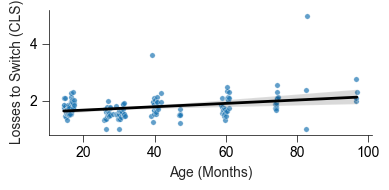

In [124]:
# ============================================================
# Plot CLS (losses-to-switch) vs age
#   - Uses CLS_mean_loss (strict: excludes CLS=0 events)
#   - Each dot = one session
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Choose which CLS metric to analyze
cls_metric = 'CLS_mean_loss'   # alternative: 'CLS_mean_all'

# Drop sessions without CLS estimates
plot_df = summary_with_cls.dropna(subset=[cls_metric, 'Current_Age_Months']).copy()

plt.figure(figsize=(4, 2))

sns.scatterplot(
    data=plot_df,
    x='Current_Age_Months',
    y=cls_metric,
    s=15,
    alpha=0.7
)

# Add linear trend (for visualization only)
sns.regplot(
    data=plot_df,
    x='Current_Age_Months',
    y=cls_metric,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)

plt.xlabel('Age (Months)')
plt.ylabel('Losses to Switch (CLS)')
sns.despine()
plt.tight_layout()
plt.show()


In [125]:
# ============================================================
# OLS regression: CLS ~ age
#   - Robust (HC3) SEs
#   - Cross-sectional interpretation
# ============================================================

import statsmodels.api as sm

X = sm.add_constant(plot_df['Current_Age_Months'])
y = plot_df[cls_metric]

model_cls_age = sm.OLS(y, X).fit(cov_type='HC3')
print(model_cls_age.summary())


                            OLS Regression Results                            
Dep. Variable:          CLS_mean_loss   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     8.755
Date:                Wed, 07 Jan 2026   Prob (F-statistic):            0.00349
Time:                        17:26:03   Log-Likelihood:                -78.800
No. Observations:                 186   AIC:                             161.6
Df Residuals:                     184   BIC:                             168.1
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.5469      0

In [126]:
# ============================================================
# OLS regression: CLS ~ PC2
# Tests whether losses-to-switch align with the aging axis
# ============================================================

import statsmodels.api as sm

# Select variables and drop missing values
cls_pc2_df = summary_with_cls.dropna(
    subset=['CLS_mean_loss', 'PC2']
).copy()

X = sm.add_constant(cls_pc2_df['PC2'])
y = cls_pc2_df['CLS_mean_loss']

model_cls_pc2 = sm.OLS(y, X).fit(cov_type='HC3')
print(model_cls_pc2.summary())


                            OLS Regression Results                            
Dep. Variable:          CLS_mean_loss   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     8.232
Date:                Wed, 07 Jan 2026   Prob (F-statistic):            0.00460
Time:                        17:26:07   Log-Likelihood:                -28.522
No. Observations:                 186   AIC:                             61.04
Df Residuals:                     184   BIC:                             67.49
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7691      0.023     78.084      0.0

In [127]:
# ============================================================
# OLS regression: CLS ~ age
# Baseline cross-sectional aging effect
# ============================================================

X = sm.add_constant(cls_pc2_df['Current_Age_Months'])
y = cls_pc2_df['CLS_mean_loss']

model_cls_age = sm.OLS(y, X).fit(cov_type='HC3')
print(model_cls_age.summary())


                            OLS Regression Results                            
Dep. Variable:          CLS_mean_loss   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     8.755
Date:                Wed, 07 Jan 2026   Prob (F-statistic):            0.00349
Time:                        17:26:09   Log-Likelihood:                -78.800
No. Observations:                 186   AIC:                             161.6
Df Residuals:                     184   BIC:                             168.1
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.5469      0

In [128]:
# ============================================================
# OLS regression: CLS ~ age + PC2
# Tests whether PC2 absorbs the age effect
# ============================================================

X = sm.add_constant(
    cls_pc2_df[['Current_Age_Months', 'PC2']]
)

model_cls_age_pc2 = sm.OLS(y, X).fit(cov_type='HC3')
print(model_cls_age_pc2.summary())


                            OLS Regression Results                            
Dep. Variable:          CLS_mean_loss   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     10.80
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           3.70e-05
Time:                        17:26:11   Log-Likelihood:                -27.118
No. Observations:                 186   AIC:                             60.24
Df Residuals:                     183   BIC:                             69.91
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.7040      0

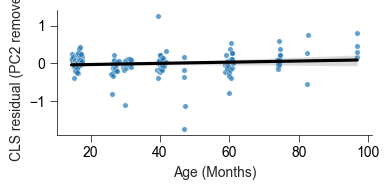

In [129]:
# ============================================================
# Residualize CLS by PC2 and test remaining age effect
# ============================================================

# Regress CLS on PC2
resid_model = sm.OLS(
    cls_pc2_df['CLS_mean_loss'],
    sm.add_constant(cls_pc2_df['PC2'])
).fit()

# Add residuals back to dataframe
cls_pc2_df['CLS_resid_PC2'] = resid_model.resid

# Plot residual CLS vs age
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 2))

sns.scatterplot(
    data=cls_pc2_df,
    x='Current_Age_Months',
    y='CLS_resid_PC2',
    s=15,
    alpha=0.7
)

sns.regplot(
    data=cls_pc2_df,
    x='Current_Age_Months',
    y='CLS_resid_PC2',
    scatter=False,
    color='black'
)

plt.xlabel('Age (Months)')
plt.ylabel('CLS residual (PC2 removed)')
sns.despine()
plt.tight_layout()
plt.show()


In [130]:
summary_with_cls.columns

Index(['Session_ID', 'Animal_Name', 'Date', 'Task_Type', 'Current_Age_Years',
       'Current_Age_Months', 'n_trials', 'n_trials_rewarded',
       'n_trials_not_rewarded', 'n_trials_nan_reward', 'n_rewards',
       'n_switches', 'n_blocks', 'reward_rate', 'switch_rate', 'stay_rate',
       'iti_mean', 'iti_win_prev1', 'iti_loss_prev0', 'trial_duration_mean',
       'trial_duration_win_prev1', 'trial_duration_loss_prev0',
       'mean_reaction_time', 'win_switch_rate_prev1', 'lose_switch_rate_prev0',
       'win_stay_rate_prev1', 'lose_stay_rate_prev0', 'accuracy',
       'precision_pos1', 'recall_pos1', 'f1_pos1', 'PC1', 'PC2', 'alpha',
       'beta', 'nll', 'converged', 'n_trials_fit', 'n_switch_events',
       'CLS_mean_all', 'CLS_median_all', 'CLS_p75_all', 'CLS_mean_loss',
       'CLS_median_loss', 'CLS_p75_loss', 'LSLS_mean', 'LSLS_median'],
      dtype='object')

In [141]:
# ============================================================
# Merge sticky RL fit parameters back into summary_df
# Uses existing fit_sticky_df
# ============================================================

# Sanity check: inspect columns in fit_sticky_df
print(fit_sticky_df.columns)
print(fit_sticky_df.head())

# Expected columns (at minimum):
# ['Session_ID', 'alpha_y', 'beta_x', 'kappa_s', 'converged', 'n_trials_fit']

# Merge into a NEW dataframe (do NOT overwrite summary_df)
summary_with_params = summary_with_cls.merge(
    fit_sticky_df[
        ['Session_ID', 'alpha_s', 'beta_s', 'kappa_s', 'converged_s', 'n_trials_fit']
    ],
    on='Session_ID',
    how='left'
)

# Check merge success
print(
    summary_with_params[
        ['alpha_s', 'beta_s', 'kappa_s']
    ].isna().mean()
)


Index(['Session_ID', 'alpha_s', 'beta_s', 'kappa_s', 'nll_s', 'converged_s',
       'n_trials_fit'],
      dtype='object')
         Session_ID   alpha_s    beta_s   kappa_s       nll_s  converged_s  \
0  2022-04-25_Fiona  0.776332  1.169407  1.246960  209.121894         True   
1  2022-04-26_Fiona  0.505178  0.836107  1.276976  177.725112         True   
2  2022-05-02_Fiona  0.436960  1.164968  1.220348  185.262206         True   
3  2022-05-03_Fiona  0.696080  1.024036  1.313643   77.811131         True   
4  2022-05-04_Fiona  0.339237  1.110015  1.117410  125.143495         True   

   n_trials_fit  
0           497  
1           378  
2           432  
3           181  
4           263  
alpha_s    0.037433
beta_s     0.037433
kappa_s    0.037433
dtype: float64


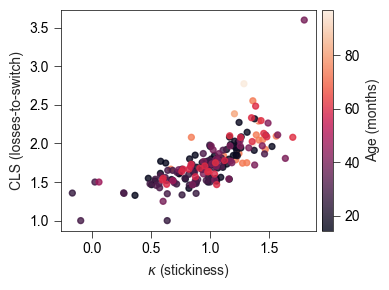

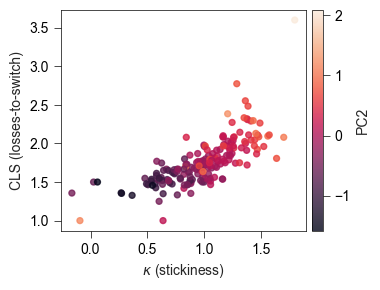

In [142]:
# ============================================================
# Joint plots: kappa vs CLS
#   1) colored by age (Current_Age_Months) with a colorbar
#   2) colored by PC2 with a colorbar
#
# Assumes you have a session-level dataframe:
#   summary_with_cls with columns: kappa_s, CLS_mean_loss, Current_Age_Months, PC2
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Global plotting style: black axes, 0.5pt lines, no grids ---
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
})

# --- Build a clean plotting df (do NOT modify your master df) ---
plot_df = summary_with_params.dropna(
    subset=['kappa_s', 'CLS_mean_loss', 'Current_Age_Months', 'PC2']
).copy()

# Optional: if you want to avoid pathological values (comment out if not needed)
# plot_df = plot_df[(plot_df['kappa_s'] >= 0) & (plot_df['CLS_mean_loss'] >= 0)].copy()

# ============================================================
# 1) kappa vs CLS colored by age
# ============================================================
fig, ax = plt.subplots(figsize=(4, 3))

sc = ax.scatter(
    plot_df['kappa_s'],
    plot_df['CLS_mean_loss'],
    c=plot_df['Current_Age_Months'],
    s=18,
    alpha=0.8
)

ax.set_xlabel(r'$\kappa$ (stickiness)')
ax.set_ylabel('CLS (losses-to-switch)')
ax.grid(False)

# Colorbar for age
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Age (months)')
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.5)

# Clean spines
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()


# ============================================================
# 2) kappa vs CLS colored by PC2
# ============================================================
fig, ax = plt.subplots(figsize=(4, 3))

sc = ax.scatter(
    plot_df['kappa_s'],
    plot_df['CLS_mean_loss'],
    c=plot_df['PC2'],
    s=18,
    alpha=0.8
)

ax.set_xlabel(r'$\kappa$ (stickiness)')
ax.set_ylabel('CLS (losses-to-switch)')
ax.grid(False)

# Colorbar for PC2
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('PC2')
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.5)

# Clean spines
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()


In [145]:
tmp_8020.columns

Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'BlockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Col

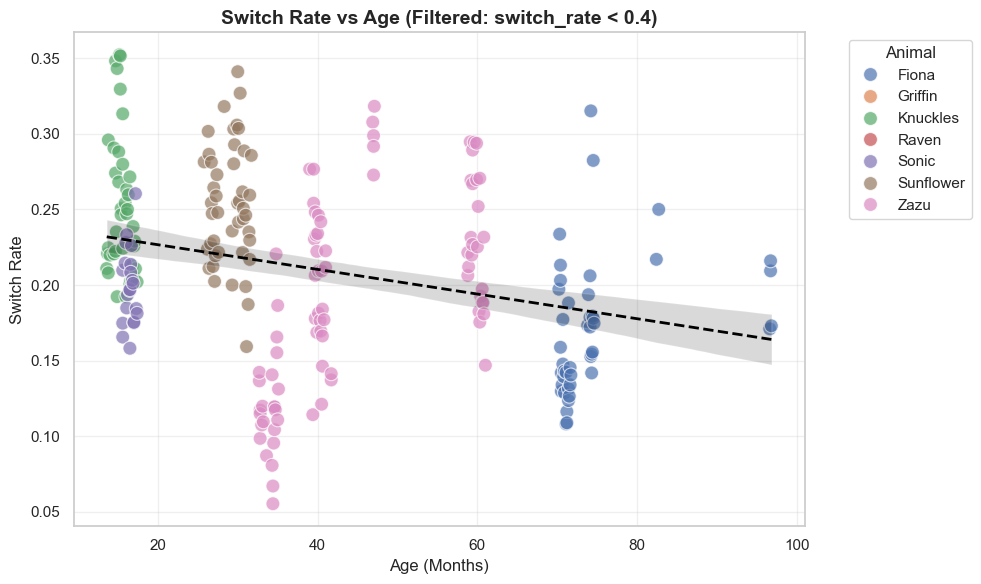

Filtered data (n=234 sessions):
Pearson r = -0.293, p = 0.0000
Spearman r = -0.367, p = 0.0000


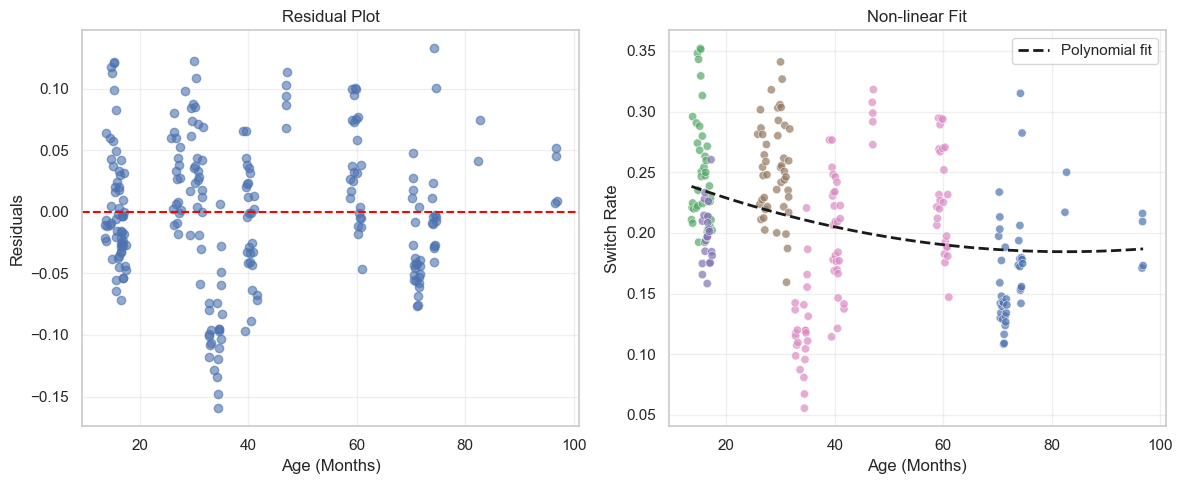

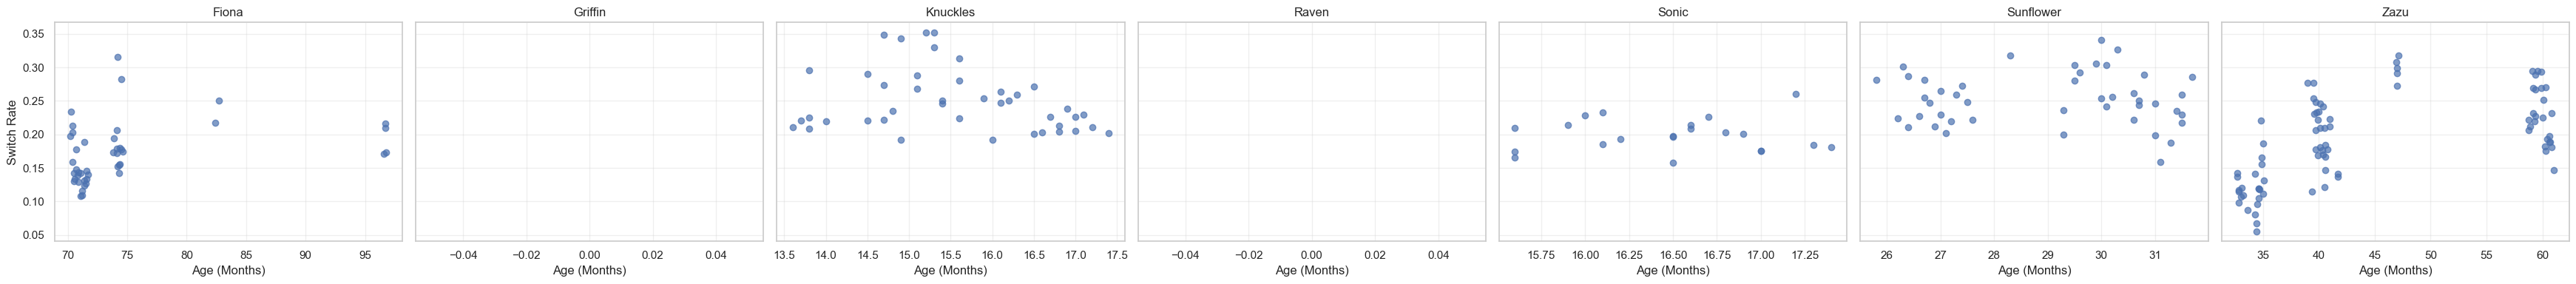

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Plot switch rate vs age with filtered data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary_df_filtered, x='Current_Age_Months', y='switch_rate', 
                hue='Animal_Name', s=100, alpha=0.7)
sns.regplot(data=summary_df_filtered, x='Current_Age_Months', y='switch_rate', 
            scatter=False, color='black', line_kws={'linewidth': 2, 'linestyle': '--'})
plt.xlabel('Age (Months)', fontsize=12)
plt.ylabel('Switch Rate', fontsize=12)
plt.title('Switch Rate vs Age (Filtered: switch_rate < 0.4)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(title='Animal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Calculate correlations on filtered data
valid_data = summary_df_filtered[['Current_Age_Months', 'switch_rate']].dropna()
if len(valid_data) > 0:
    r_pearson, p_pearson = pearsonr(valid_data['Current_Age_Months'], valid_data['switch_rate'])
    r_spearman, p_spearman = spearmanr(valid_data['Current_Age_Months'], valid_data['switch_rate'])
    print(f"Filtered data (n={len(valid_data)} sessions):")
    print(f"Pearson r = {r_pearson:.3f}, p = {p_pearson:.4f}")
    print(f"Spearman r = {r_spearman:.3f}, p = {p_spearman:.4f}")

# Explore non-linearity
from scipy.stats import linregress

slope, intercept, r, p, se = linregress(valid_data['Current_Age_Months'], valid_data['switch_rate'])
valid_data_copy = valid_data.copy()
valid_data_copy['predicted'] = slope * valid_data_copy['Current_Age_Months'] + intercept
valid_data_copy['residuals'] = valid_data_copy['switch_rate'] - valid_data_copy['predicted']

plt.figure(figsize=(12, 5))

# Residual plot
plt.subplot(1, 2, 1)
plt.scatter(valid_data_copy['Current_Age_Months'], valid_data_copy['residuals'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Age (Months)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# Polynomial fit
plt.subplot(1, 2, 2)
sns.scatterplot(data=summary_df_filtered, x='Current_Age_Months', y='switch_rate', 
                hue='Animal_Name', alpha=0.7, legend=False)
z = np.polyfit(valid_data['Current_Age_Months'], valid_data['switch_rate'], 2)
p_poly = np.poly1d(z)
x_smooth = np.linspace(valid_data['Current_Age_Months'].min(), 
                       valid_data['Current_Age_Months'].max(), 100)
plt.plot(x_smooth, p_poly(x_smooth), "k--", linewidth=2, label='Polynomial fit')
plt.xlabel('Age (Months)')
plt.ylabel('Switch Rate')
plt.title('Non-linear Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Individual animal trends
animals = summary_df_filtered['Animal_Name'].unique()
n_animals = len(animals)
fig, axes = plt.subplots(1, n_animals, figsize=(5*n_animals, 4), sharey=True)
if n_animals == 1:
    axes = [axes]

for i, animal in enumerate(animals):
    animal_data = summary_df_filtered[summary_df_filtered['Animal_Name'] == animal]
    axes[i].scatter(animal_data['Current_Age_Months'], animal_data['switch_rate'], alpha=0.7)
    axes[i].set_xlabel('Age (Months)')
    axes[i].set_title(animal)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel('Switch Rate')
plt.tight_layout()
plt.show()


Sessions per age group:
Age_Group
0-18     63
18-36    45
36-60    47
60+      55
Name: count, dtype: int64


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_76958/1987945568.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feature,
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_76958/1987945568.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feature,
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_76958/1987945568.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feat

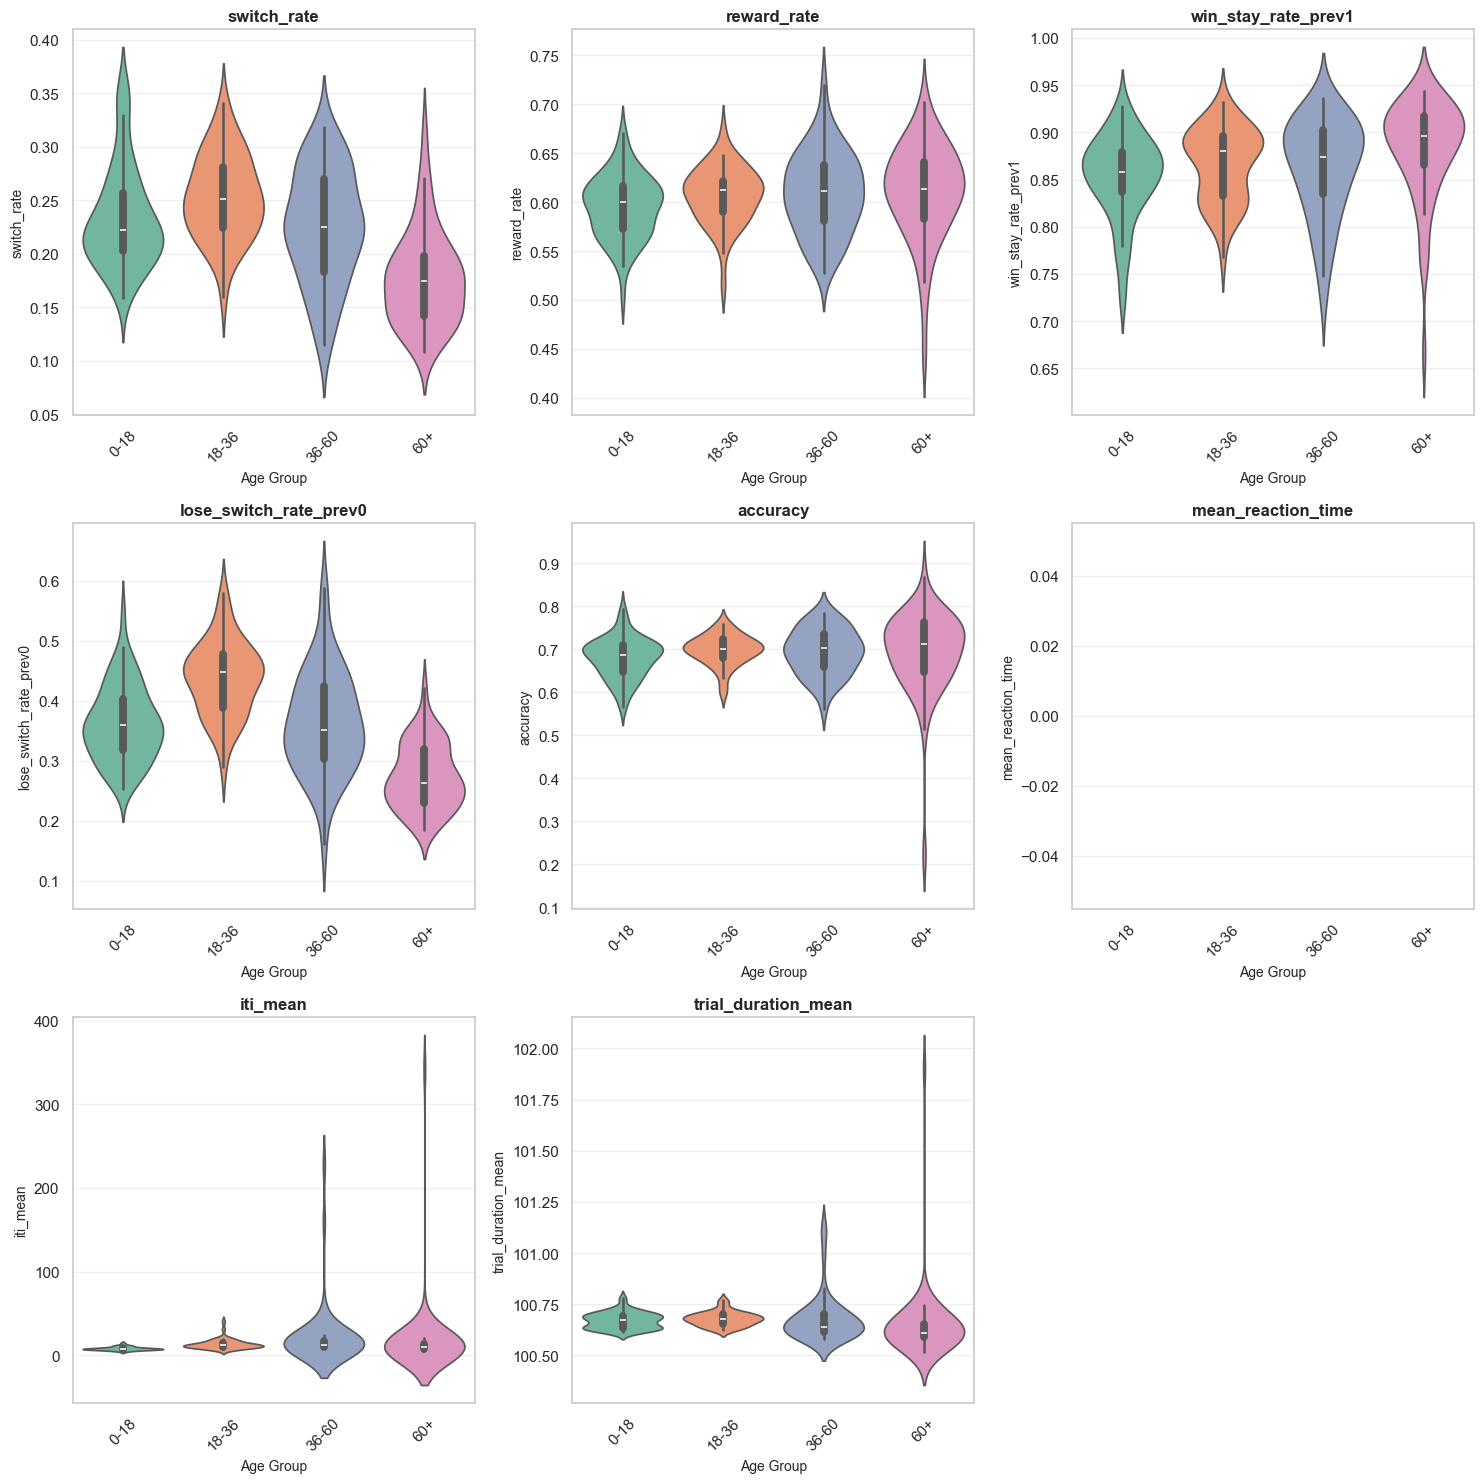

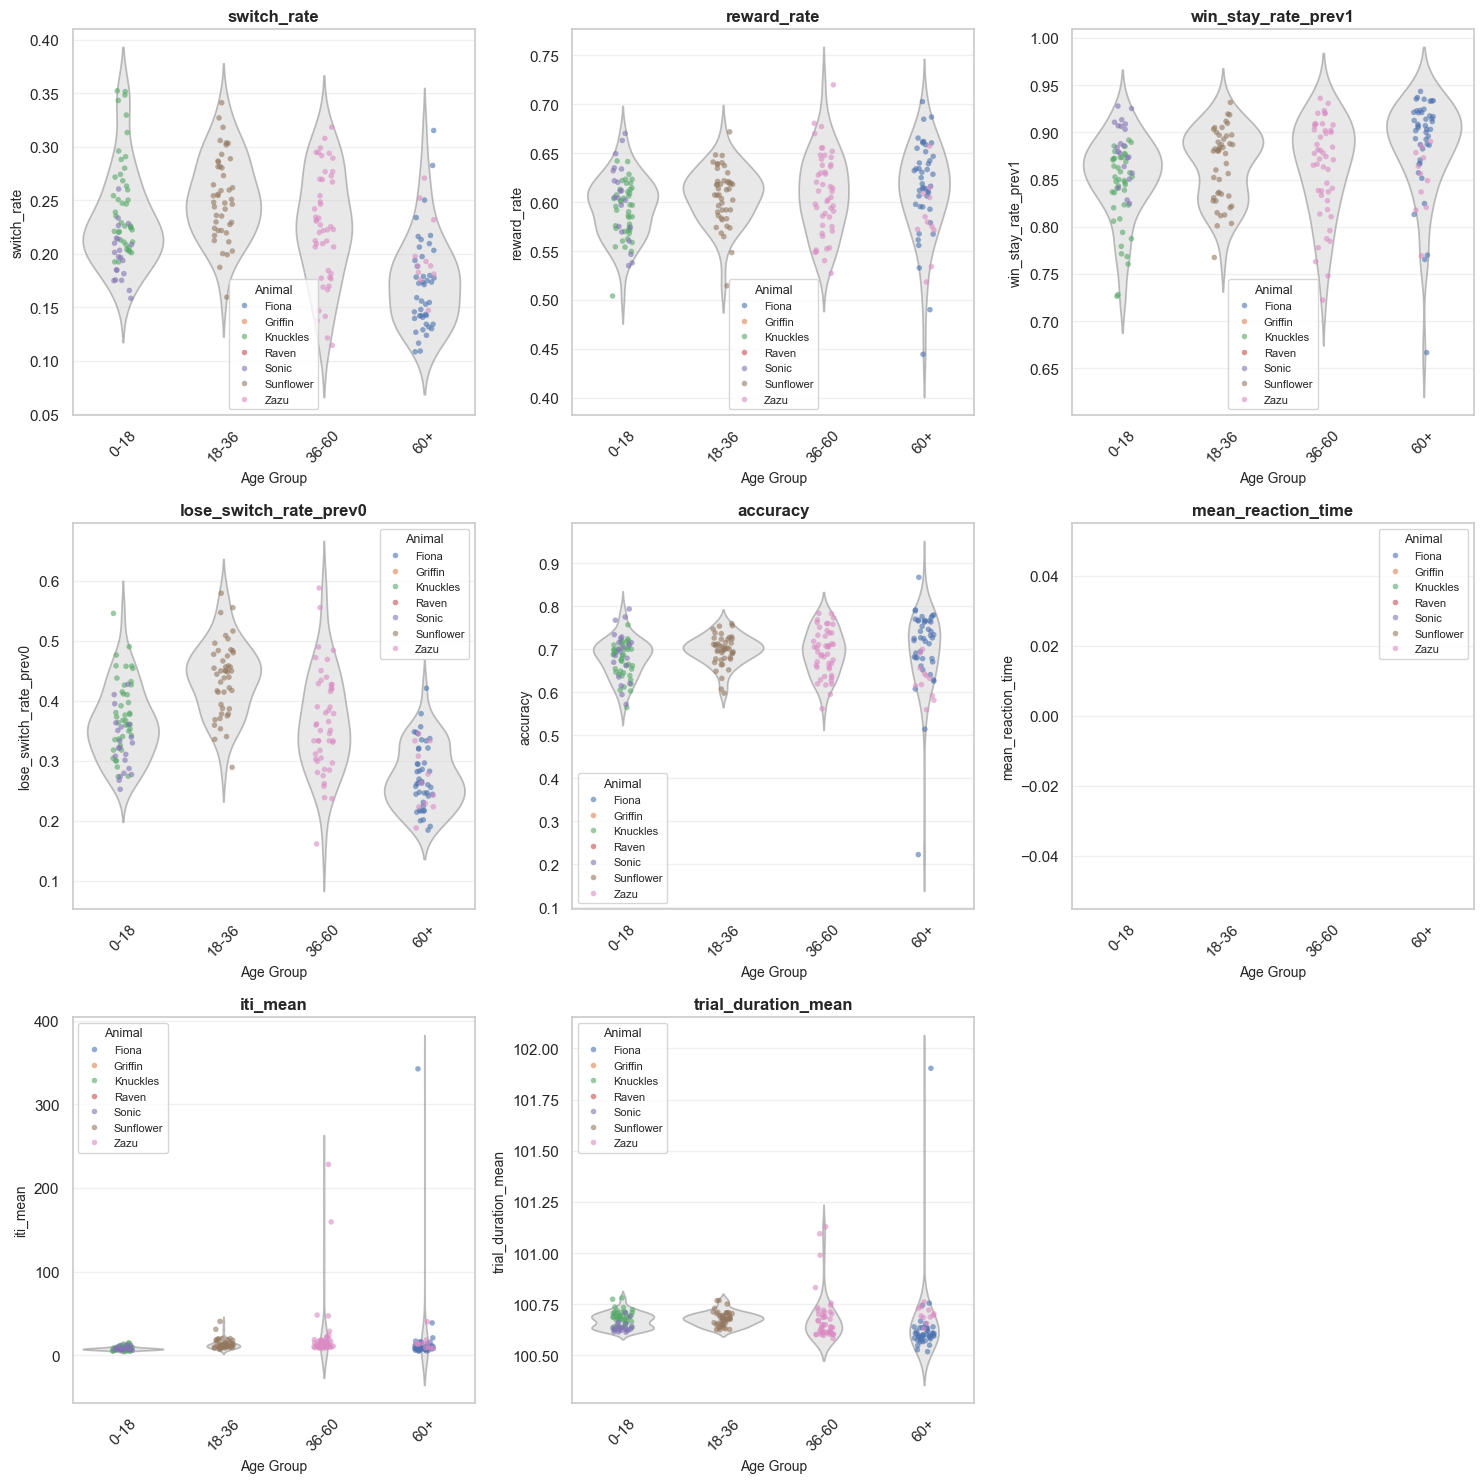

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create Age_Group bins
# Option 1: Equal-width bins

summary_df_filtered['Age_Group'] = pd.cut(summary_df_filtered['Current_Age_Months'], 
                                           bins=[0, 18, 36, 60, 100],
                                           labels=['0-18', '18-36', '36-60', '60+'])

# Remove Animal_Name = 'Zazu' from 18-36 months sessions
summary_df_filtered = summary_df_filtered[
    ~((summary_df_filtered['Animal_Name'] == 'Zazu') & 
      (summary_df_filtered['Current_Age_Months'] >= 18) & 
      (summary_df_filtered['Current_Age_Months'] <= 36))
]

# # Option 2: Custom bins based on your data range
# # First check the age range
# print(f"Age range: {summary_df_filtered['Current_Age_Months'].min():.1f} to {summary_df_filtered['Current_Age_Months'].max():.1f} months")

# # Then create appropriate bins (adjust as needed)
# summary_df_filtered['Age_Group'] = pd.cut(summary_df_filtered['Current_Age_Months'], 
#                                            bins=5,  # Creates 5 equal-width bins
#                                            precision=0)

# # Option 3: Quantile-based bins (equal number of sessions per bin)
# summary_df_filtered['Age_Group'] = pd.qcut(summary_df_filtered['Current_Age_Months'], 
#                                             q=4,  # Creates 4 quartiles
#                                             labels=['Young', 'Young-Adult', 'Adult', 'Mature'])

# Check distribution
print("\nSessions per age group:")
print(summary_df_filtered['Age_Group'].value_counts().sort_index())

# Now create violin plots for multiple features
features_to_plot = ['switch_rate', 'reward_rate', 'win_stay_rate_prev1', 
                    'lose_switch_rate_prev0', 'accuracy', 'mean_reaction_time',
                    'iti_mean', 'trial_duration_mean']

# Create a grid of violin plots
n_features = len(features_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feature, 
                   ax=axes[i], inner='box', palette='Set2')
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Age Group', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3, axis='y')

# Remove extra subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Alternative: Plot with individual animal colors
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feature, 
                   ax=axes[i], inner=None, color='lightgray', alpha=0.5)
    sns.stripplot(data=summary_df_filtered, x='Age_Group', y=feature, 
                  hue='Animal_Name', ax=axes[i], alpha=0.6, size=4)
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Age Group', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].legend(title='Animal', fontsize=8, title_fontsize=9, loc='best')

for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [104]:
session_id = tmp_8020_reversal['Session_ID'].iloc[0]

trial_df = tmp_8020_reversal[
    tmp_8020_reversal['Session_ID'] == session_id
][['Decision', 'Reward']].copy()

print(trial_df)
print(len(trial_df))


      Decision  Reward
4702       0.0     0.0
4703       1.0     1.0
4704       1.0     1.0
4705       0.0     0.0
4706       1.0     1.0
...        ...     ...
5194       0.0     0.0
5195       0.0     0.0
5196       1.0     1.0
5197       1.0     1.0
5198       0.0     0.0

[497 rows x 2 columns]
497


In [77]:
import numpy as np

def q_learning_loglik(params, choices, rewards):
    alpha, beta = params
    Q = np.zeros(2)
    loglik = 0.0

    for c, r in zip(choices, rewards):
        p = 1 / (1 + np.exp(-beta * (Q[1] - Q[0])))
        p_choice = p if c == 1 else (1 - p)
        loglik += np.log(p_choice + 1e-10)

        # update
        Q[c] += alpha * (r - Q[c])

    return -loglik  # negative LL for minimization


In [78]:
choices = trial_df['Decision'].values.astype(int)
rewards = trial_df['Reward'].values.astype(int)

print(q_learning_loglik([0.2, 5.0], choices, rewards))


59550.812134415915


In [79]:
from scipy.optimize import minimize

# Extract trial-level data
choices = trial_df['Decision'].values.astype(int)
rewards = trial_df['Reward'].values.astype(int)

# Parameter bounds: alpha in [0,1], beta > 0
bounds = [(0, 1), (1e-3, 20)]

# Fit model
res = minimize(
    q_learning_loglik,
    x0=[0.2, 5.0],
    args=(choices, rewards),
    bounds=bounds,
    method='L-BFGS-B'
)

# Print fitted parameters and loss
print(res.x, res.fun)


[0.60867715 1.32385421] 37153.21602806696


In [80]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def fit_session_qlearning(trial_df):
    # Extract choices and rewards
    choices = trial_df['Decision'].values.astype(int)
    rewards = trial_df['Reward'].values.astype(int)

    # Fit with bounds
    res = minimize(
        q_learning_loglik,
        x0=[0.2, 5.0],
        args=(choices, rewards),
        bounds=[(0, 1), (1e-3, 20)],
        method='L-BFGS-B'
    )

    # Return fit results
    return {
        'alpha': res.x[0],
        'beta': res.x[1],
        'nll': res.fun,
        'converged': bool(res.success)
    }

# Fit model per session
fit_rows = []
for session_id, sub in tmp_8020_reversal.groupby('Session_ID'):
    sub_local = sub[['Session_ID', 'Decision', 'Reward']].dropna().copy()
    out = fit_session_qlearning(sub_local)
    out['Session_ID'] = session_id
    out['n_trials_fit'] = len(sub_local)
    fit_rows.append(out)

fits_df = pd.DataFrame(fit_rows)

# Merge into summary_df (session-level)
summary_df = summary_df.merge(fits_df, on='Session_ID', how='left')


In [81]:
summary_df

,Session_ID,Animal_Name,Date,Task_Type,Current_Age_Years,Current_Age_Months,n_trials,n_trials_rewarded,n_trials_not_rewarded,n_trials_nan_reward,...,precision_pos1,recall_pos1,f1_pos1,PC1,PC2,alpha,beta,nll,converged,n_trials_fit
0,2022-04-25_Fiona,Fiona,2022-04-25,Reversal,6.15,73.8,497,303,194,0,...,1.0,0.726358,0.841492,-1.488862,0.075004,0.775002,1.794710,262.430399,True,497
1,2022-04-26_Fiona,Fiona,2022-04-26,Reversal,6.15,73.9,378,231,147,0,...,1.0,0.679894,0.809449,-1.029853,0.191304,0.521488,1.297276,229.936800,True,378
2,2022-05-02_Fiona,Fiona,2022-05-02,Reversal,6.17,74.1,432,270,162,0,...,1.0,0.766204,0.867628,-1.321187,0.141086,0.412015,1.804964,229.835366,True,432
3,2022-05-03_Fiona,Fiona,2022-05-03,Reversal,6.17,74.1,181,112,69,0,...,1.0,0.718232,0.836013,-1.412778,0.469865,0.700103,1.633998,100.473283,True,181
4,2022-05-04_Fiona,Fiona,2022-05-04,Reversal,6.18,74.1,263,174,89,0,...,1.0,0.726236,0.841410,-0.580966,0.148995,0.330906,1.681964,151.238345,True,263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,2024-03-15_Zazu,Zazu,2024-03-15,Reversal,5.05,60.6,153,88,65,0,...,1.0,0.699346,0.823077,-1.066285,0.200634,0.077269,1.912506,87.130527,True,153
183,2024-03-18_Zazu,Zazu,2024-03-18,Reversal,5.06,60.7,309,165,144,0,...,1.0,0.614887,0.761523,-1.294173,0.483578,1.000000,0.893069,195.162847,True,309
184,2024-03-19_Zazu,Zazu,2024-03-19,Reversal,5.07,60.8,178,117,61,0,...,1.0,0.691011,0.817276,-0.047677,0.359034,0.407075,1.307021,109.528491,True,178
185,2024-03-20_Zazu,Zazu,2024-03-20,Reversal,5.07,60.8,294,172,122,0,...,1.0,0.642857,0.782609,-1.304084,0.960711,0.287740,1.008534,190.527874,True,294


In [82]:
# How many converged?
print(fits_df['converged'].value_counts(dropna=False))

# Check for parameters stuck on bounds (common failure mode)
eps = 1e-3
print("alpha near 0:", (fits_df['alpha'] <= 0 + 1e-4).sum())
print("alpha near 1:", (fits_df['alpha'] >= 1 - 1e-4).sum())
print("beta near min:", (fits_df['beta'] <= eps + 1e-4).sum())
print("beta near max:", (fits_df['beta'] >= 20 - 1e-2).sum())

# Check fit trial counts
print(fits_df['n_trials_fit'].describe())


converged
True    187
Name: count, dtype: int64
alpha near 0: 3
alpha near 1: 17
beta near min: 1
beta near max: 1
count    187.000000
mean     331.839572
std      140.478430
min        3.000000
25%      245.000000
50%      341.000000
75%      457.500000
max      600.000000
Name: n_trials_fit, dtype: float64


In [84]:
from scipy.stats import spearmanr

check_df = summary_df[['alpha','beta','PC1','PC2']].dropna()
for p in ['alpha','beta']:
    for pc in ['PC1','PC2']:
        rho, pval = spearmanr(check_df[p], check_df[pc])
        print(f"{p} vs {pc}: rho={rho:.3f}, p={pval:.3g}")


alpha vs PC1: rho=0.027, p=0.712
alpha vs PC2: rho=-0.385, p=5.69e-08
beta vs PC1: rho=-0.262, p=0.000298
beta vs PC2: rho=-0.051, p=0.486


In [85]:
import statsmodels.api as sm

reg_df = summary_df[['Current_Age_Months','alpha','beta']].dropna()

X_age = sm.add_constant(reg_df['Current_Age_Months'])
m_a = sm.OLS(reg_df['alpha'], X_age).fit(cov_type='HC3')
m_b = sm.OLS(reg_df['beta'],  X_age).fit(cov_type='HC3')

print("alpha ~ age"); print(m_a.summary())
print("\nbeta ~ age"); print(m_b.summary())


alpha ~ age
                            OLS Regression Results                            
Dep. Variable:                  alpha   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     6.963
Date:                Wed, 07 Jan 2026   Prob (F-statistic):            0.00903
Time:                        17:17:16   Log-Likelihood:                -16.994
No. Observations:                 187   AIC:                             37.99
Df Residuals:                     185   BIC:                             44.45
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0

In [86]:
import statsmodels.api as sm

# Select required columns and drop missing values
reg_df = summary_df[
    ['Current_Age_Months', 'alpha', 'PC2']
].dropna().copy()

# Add intercept
X = sm.add_constant(reg_df[['Current_Age_Months', 'PC2']])

# Fit OLS with heteroscedasticity-robust errors
m_alpha_age_pc2 = sm.OLS(reg_df['alpha'], X).fit(cov_type='HC3')

# Print model summary
print(m_alpha_age_pc2.summary())



                            OLS Regression Results                            
Dep. Variable:                  alpha   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     4.495
Date:                Wed, 07 Jan 2026   Prob (F-statistic):             0.0124
Time:                        17:17:26   Log-Likelihood:                -3.4889
No. Observations:                 186   AIC:                             12.98
Df Residuals:                     183   BIC:                             22.66
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6238      0

In [87]:
import statsmodels.api as sm

# Select required columns and drop missing values
reg_df_beta = summary_df[
    ['Current_Age_Months', 'beta', 'PC1']
].dropna().copy()

# Add intercept
X = sm.add_constant(reg_df_beta[['Current_Age_Months', 'PC1']])

# Fit OLS with heteroscedasticity-robust errors
m_beta_age_pc1 = sm.OLS(reg_df_beta['beta'], X).fit(cov_type='HC3')

# Print model summary
print(m_beta_age_pc1.summary())


                            OLS Regression Results                            
Dep. Variable:                   beta   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     1.284
Date:                Wed, 07 Jan 2026   Prob (F-statistic):              0.279
Time:                        17:17:33   Log-Likelihood:                -402.83
No. Observations:                 186   AIC:                             811.7
Df Residuals:                     183   BIC:                             821.3
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.9523      0

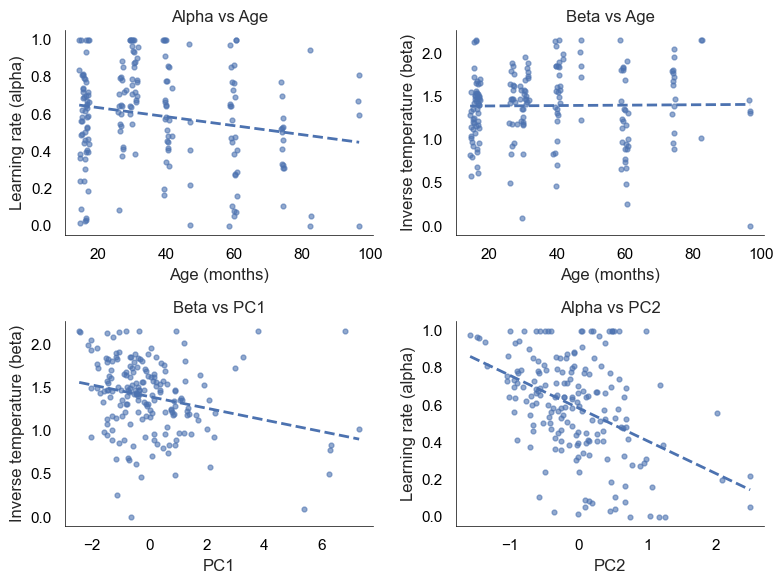

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# --- Make a local copy for plotting only (does NOT modify summary_df) ---
plot_cols = ['Current_Age_Months', 'alpha', 'beta', 'PC1', 'PC2']
plot_df = summary_df[plot_cols].dropna().copy()
plot_df['PC2'] = plot_df['PC2'].clip(-2.5, 2.5)

beta_cap = plot_df['beta'].quantile(0.97)
plot_df['beta'] = plot_df['beta'].clip(upper=beta_cap)


# --- Helper: scatter + linear best-fit line (visual sanity only) ---
def scatter_with_fit(ax, x, y, xlabel, ylabel, title):
    # Scatter points
    ax.scatter(x, y, s=12, alpha=0.6)

    # Add linear line of best fit if enough points
    if len(x) >= 2:
        m, b = np.polyfit(x, y, deg=1)
        x_line = np.linspace(np.min(x), np.max(x), 200)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, linestyle='--', linewidth=2)

    # Axes styling
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(False)
    sns.despine()

# --- Build a single summary figure (2x2 panels) ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Panel A: alpha vs age
scatter_with_fit(
    axes[0, 0],
    plot_df['Current_Age_Months'].values,
    plot_df['alpha'].values,
    xlabel='Age (months)',
    ylabel='Learning rate (alpha)',
    title='Alpha vs Age'
)

# Panel B: beta vs age
scatter_with_fit(
    axes[0, 1],
    plot_df['Current_Age_Months'].values,
    plot_df['beta'].values,
    xlabel='Age (months)',
    ylabel='Inverse temperature (beta)',
    title='Beta vs Age'
)

# Panel C: beta vs PC1
scatter_with_fit(
    axes[1, 0],
    plot_df['PC1'].values,
    plot_df['beta'].values,
    xlabel='PC1',
    ylabel='Inverse temperature (beta)',
    title='Beta vs PC1'
)

# Panel D: alpha vs PC2
scatter_with_fit(
    axes[1, 1],
    plot_df['PC2'].values,
    plot_df['alpha'].values,
    xlabel='PC2',
    ylabel='Learning rate (alpha)',
    title='Alpha vs PC2'
)

# Tight layout + clean frame
plt.tight_layout()

# Save figure (edit paths as needed)
plt.savefig(os.path.join(fig_path, "rl_summary_figure.svg"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(fig_path, "rl_summary_figure.svg"), bbox_inches="tight")

plt.show()


In [139]:
import matplotlib as mpl

# --- Global plotting style (set once per session) ---
mpl.rcParams.update({

    # Axes appearance
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.5,
    'axes.grid': False,

    # Tick appearance
    'xtick.color': 'black',
    'ytick.color': 'black',
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    # Tick length (optional but nice)
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,

    # Font color
    'text.color': 'black',
    'axes.labelcolor': 'black',

    # Remove top/right spines if you want (optional)
    'axes.spines.top': False,
    'axes.spines.right': False,
})


In [89]:
# Identify extreme PC2 sessions
extreme_pc2 = plot_df[plot_df['PC2'] > 2]

# Look at how many and basic stats
print(len(extreme_pc2))
print(extreme_pc2[['PC2', 'alpha', 'Current_Age_Months']].describe())


4
            PC2     alpha  Current_Age_Months
count  4.000000  4.000000            4.000000
mean   2.275776  0.257339           54.050000
std    0.260624  0.212744           19.437507
min    2.015025  0.053595           39.400000
25%    2.069815  0.162730           45.100000
50%    2.294039  0.209632           47.050000
75%    2.500000  0.304240           56.000000
max    2.500000  0.556496           82.700000


In [90]:
# Create a visualization-only copy
plot_df_viz = plot_df.copy()

# Clip PC2 only for plotting
plot_df_viz['PC2'] = plot_df_viz['PC2'].clip(-2.5, 2.5)


## Building a Session Level model, starting with a Q-learning with A SOFTMAX POLICY

In [91]:
summary_df.columns.unique()

Index(['Session_ID', 'Animal_Name', 'Date', 'Task_Type', 'Current_Age_Years',
       'Current_Age_Months', 'n_trials', 'n_trials_rewarded',
       'n_trials_not_rewarded', 'n_trials_nan_reward', 'n_rewards',
       'n_switches', 'n_blocks', 'reward_rate', 'switch_rate', 'stay_rate',
       'iti_mean', 'iti_win_prev1', 'iti_loss_prev0', 'trial_duration_mean',
       'trial_duration_win_prev1', 'trial_duration_loss_prev0',
       'mean_reaction_time', 'win_switch_rate_prev1', 'lose_switch_rate_prev0',
       'win_stay_rate_prev1', 'lose_stay_rate_prev0', 'accuracy',
       'precision_pos1', 'recall_pos1', 'f1_pos1', 'PC1', 'PC2', 'alpha',
       'beta', 'nll', 'converged', 'n_trials_fit'],
      dtype='object')

In [92]:
import numpy as np
import pandas as pd

# --- Helper: negative log-likelihood for random-choice baseline ---
def nll_random(choices):
    # Random choice assumes P(choice=1)=0.5 on every trial
    return -np.sum(np.log(0.5 + 1e-12)) * len(choices)

# --- Helper: negative log-likelihood for bias-only baseline ---
def nll_bias_only(choices):
    # Bias-only model: one parameter p = mean choice of 1
    p = np.clip(np.mean(choices), 1e-6, 1 - 1e-6)
    ll = np.sum(choices * np.log(p) + (1 - choices) * np.log(1 - p))
    return -ll

# --- Helper: compute AIC/BIC from NLL and parameter count ---
def aic_bic(nll, k, n):
    # AIC = 2k + 2NLL ; BIC = k*ln(n) + 2NLL
    aic = 2 * k + 2 * nll
    bic = k * np.log(max(n, 1)) + 2 * nll
    return aic, bic

# --- Build a local trial table (does NOT modify tmp_8020_reversal) ---
trial_df = tmp_8020_reversal[['Session_ID', 'Decision', 'Reward']].dropna().copy()
trial_df['Decision'] = trial_df['Decision'].astype(int)
trial_df['Reward'] = trial_df['Reward'].astype(int)

# --- Merge fitted params onto trials (safe: local merge only) ---
params_df = summary_df[['Session_ID', 'alpha', 'beta']].dropna().copy()
trial_df = trial_df.merge(params_df, on='Session_ID', how='inner')

# --- Compute per-session fit metrics ---
rows = []
for sid, sub in trial_df.groupby('Session_ID'):
    # Extract arrays
    choices = sub['Decision'].values.astype(int)
    rewards = sub['Reward'].values.astype(int)
    n = len(choices)

    # RL NLL using fitted parameters
    alpha = float(sub['alpha'].iloc[0])
    beta  = float(sub['beta'].iloc[0])
    nll_rl = q_learning_loglik([alpha, beta], choices, rewards)

    # Baselines
    nll_rand = nll_random(choices)
    nll_bias = nll_bias_only(choices)

    # Information criteria (RL has 2 params; bias-only has 1; random has 0)
    aic_rl,   bic_rl   = aic_bic(nll_rl,   k=2, n=n)
    aic_bias, bic_bias = aic_bic(nll_bias, k=1, n=n)
    aic_rand, bic_rand = aic_bic(nll_rand, k=0, n=n)

    # McFadden pseudo-R2 vs bias-only (common in choice modeling)
    # R2 = 1 - (LL_model / LL_null) ; using log-likelihoods (negative sign handled)
    ll_rl   = -nll_rl
    ll_bias = -nll_bias
    pseudo_r2 = 1 - (ll_rl / ll_bias) if ll_bias != 0 else np.nan

    rows.append({
        'Session_ID': sid,
        'n_trials_fit': n,
        'alpha': alpha,
        'beta': beta,
        'nll_rl': nll_rl,
        'nll_bias': nll_bias,
        'nll_rand': nll_rand,
        'aic_rl': aic_rl, 'bic_rl': bic_rl,
        'aic_bias': aic_bias, 'bic_bias': bic_bias,
        'aic_rand': aic_rand, 'bic_rand': bic_rand,
        'pseudo_r2_vs_bias': pseudo_r2
    })

fit_metrics_df = pd.DataFrame(rows)

# --- Quick global summary of fit quality ---
print(fit_metrics_df[['pseudo_r2_vs_bias', 'aic_rl', 'aic_bias']].describe())
print("RL better than bias-only by AIC (count):", (fit_metrics_df['aic_rl'] < fit_metrics_df['aic_bias']).sum())


       pseudo_r2_vs_bias      aic_rl    aic_bias
count         187.000000  187.000000  187.000000
mean            0.045930  393.087129  410.733403
std             0.047171  167.832104  173.950215
min            -0.174087    8.158883    5.819085
25%             0.017164  290.770507  309.276990
50%             0.041379  394.325694  413.904370
75%             0.072073  526.868514  550.030372
max             0.224290  797.585677  821.407392
RL better than bias-only by AIC (count): 161


In [93]:
import numpy as np

# --- Simulate choices given observed rewards (keeps reward sequence fixed) ---
def simulate_qlearning(alpha, beta, rewards, seed=0):
    # Simulate choices from softmax policy with Q-learning updates
    rng = np.random.default_rng(seed)
    Q = np.zeros(2, dtype=float)
    choices_sim = np.zeros(len(rewards), dtype=int)

    for t, r in enumerate(rewards):
        # Choice probability for action 1
        p1 = 1 / (1 + np.exp(-beta * (Q[1] - Q[0])))

        # Sample choice
        c = 1 if rng.random() < p1 else 0
        choices_sim[t] = c

        # Update chosen action value
        Q[c] += alpha * (r - Q[c])

    return choices_sim

# --- Simple summary metrics to compare observed vs simulated ---
def session_metrics(choices):
    # Compute switch rate and stay rate from choice series
    if len(choices) < 2:
        return {'switch_rate': np.nan, 'stay_rate': np.nan}
    switches = np.sum(choices[1:] != choices[:-1])
    return {
        'switch_rate': switches / (len(choices) - 1),
        'stay_rate': 1 - (switches / (len(choices) - 1))
    }

# --- Run PPC per session (one simulation per session; increase sims later if needed) ---
ppc_rows = []
for sid, sub in trial_df.groupby('Session_ID'):
    # Extract arrays and fitted params
    choices_obs = sub['Decision'].values.astype(int)
    rewards_obs = sub['Reward'].values.astype(int)
    alpha = float(sub['alpha'].iloc[0])
    beta  = float(sub['beta'].iloc[0])

    # Simulate choices
    choices_sim = simulate_qlearning(alpha, beta, rewards_obs, seed=42)

    # Metrics
    m_obs = session_metrics(choices_obs)
    m_sim = session_metrics(choices_sim)

    ppc_rows.append({
        'Session_ID': sid,
        'switch_rate_obs': m_obs['switch_rate'],
        'switch_rate_sim': m_sim['switch_rate'],
        'stay_rate_obs': m_obs['stay_rate'],
        'stay_rate_sim': m_sim['stay_rate'],
        'n_trials_fit': len(choices_obs)
    })

ppc_df = pd.DataFrame(ppc_rows)
print(ppc_df[['switch_rate_obs', 'switch_rate_sim']].corr())


                 switch_rate_obs  switch_rate_sim
switch_rate_obs         1.000000         0.483309
switch_rate_sim         0.483309         1.000000


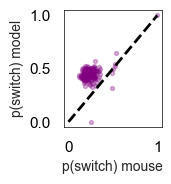

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot observed vs simulated switch rate ---
plt.figure(figsize=(2, 2))

x = ppc_df['switch_rate_obs'].values
y = ppc_df['switch_rate_sim'].values

# Scatter
plt.scatter(x, y, s=8, alpha=0.3, color = 'purple')

# Identity line
mn = np.nanmin([x.min(), y.min()])
mx = np.nanmax([x.max(), y.max()])
plt.plot([mn, mx], [mn, mx], linestyle='--', linewidth=2, color='black')

# Labels
plt.xlabel('p(switch) mouse', fontsize=10)
plt.ylabel('p(switch) model', fontsize=10)
plt.grid(False)

# SAVE FIGURE IN FIG_PATH, BUT MAKE A SUBFOLDER NAMING THIS MODEL
model_name = "q_learning"
fig_path = "/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/forVictoria/2-outputs/1-Marmoset_8020"
fig_path_model = os.path.join(fig_path, model_name)
os.makedirs(fig_path_model, exist_ok=True)
plt.savefig(os.path.join(fig_path_model, "switch_rate_comparison.svg"), dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


## Q-learning with a sticky term! 

In [132]:
import numpy as np

def qlearn_sticky_nll(params, choices, rewards):
    # Sticky Q-learning NLL with softmax over (beta*Qdiff + kappa*prev_choice)
    alpha, beta, kappa = params

    # Hard constraints (keeps optimizer from exploring invalid space)
    if not (0 < alpha < 1) or beta <= 0:
        return np.inf

    Q = np.zeros(2, dtype=float)
    nll = 0.0

    prev_choice = None  # no stickiness on first trial

    for c, r in zip(choices, rewards):
        # Stickiness term: +1 if previous choice was 1, -1 if it was 0
        stick = 0.0 if prev_choice is None else (1.0 if prev_choice == 1 else -1.0)

        # Logit for choosing 1 (stable logistic form)
        z = beta * (Q[1] - Q[0]) + kappa * stick
        p1 = 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

        # Choice probability for observed action
        p = p1 if c == 1 else (1.0 - p1)
        nll -= np.log(p + 1e-12)

        # Q update on chosen action only
        Q[c] += alpha * (r - Q[c])

        prev_choice = c

    return nll


In [133]:
from scipy.optimize import minimize
import pandas as pd

# Build a local trial table (does NOT modify tmp_8020_reversal)
trial_df = tmp_8020_reversal[['Session_ID', 'Decision', 'Reward']].dropna().copy()
trial_df['Decision'] = trial_df['Decision'].astype(int)
trial_df['Reward'] = trial_df['Reward'].astype(int)

# Fit each session independently
fit_rows = []
bounds = [(1e-4, 1-1e-4), (1e-3, 50.0), (-10.0, 10.0)]  # alpha, beta, kappa

for sid, sub in trial_df.groupby('Session_ID'):
    # Extract arrays
    choices = sub['Decision'].values.astype(int)
    rewards = sub['Reward'].values.astype(int)

    # Skip tiny sessions (fit instability)
    if len(choices) < 30:
        continue

    # Reasonable starting point (stable)
    x0 = np.array([0.3, 2.0, 0.0])  # alpha, beta, kappa

    # Optimize NLL
    res = minimize(
        qlearn_sticky_nll, x0,
        args=(choices, rewards),
        method='L-BFGS-B',
        bounds=bounds
    )

    fit_rows.append({
        'Session_ID': sid,
        'alpha_s': res.x[0],
        'beta_s': res.x[1],
        'kappa_s': res.x[2],
        'nll_s': res.fun,
        'converged_s': res.success,
        'n_trials_fit': len(choices)
    })

fit_sticky_df = pd.DataFrame(fit_rows)
print(fit_sticky_df['converged_s'].value_counts())
fit_sticky_df.head()


converged_s
True    180
Name: count, dtype: int64


,Session_ID,alpha_s,beta_s,kappa_s,nll_s,converged_s,n_trials_fit
0,2022-04-25_Fiona,0.776332,1.169407,1.246960,209.121894,True,497
1,2022-04-26_Fiona,0.505178,0.836107,1.276976,177.725112,True,378
2,2022-05-02_Fiona,0.436960,1.164968,1.220348,185.262206,True,432
3,2022-05-03_Fiona,0.696080,1.024036,1.313643,77.811131,True,181
4,2022-05-04_Fiona,0.339237,1.110015,1.117410,125.143495,True,263


In [134]:
# Merge sticky fits onto your existing fit_metrics_df (baseline RL metrics)
fit_compare = fit_metrics_df.merge(
    fit_sticky_df[['Session_ID', 'nll_s', 'n_trials_fit', 'converged_s']],
    on=['Session_ID', 'n_trials_fit'],
    how='inner'
).copy()

# Compute AIC for sticky model (k=3) and baseline (k=2)
fit_compare['aic_s'] = 2*3 + 2*fit_compare['nll_s']
fit_compare['aic_rl'] = 2*2 + 2*fit_compare['nll_rl']

# Delta AIC (negative = sticky better)
fit_compare['delta_aic'] = fit_compare['aic_s'] - fit_compare['aic_rl']

print(fit_compare['delta_aic'].describe())
print("Sticky better by AIC (count):", (fit_compare['delta_aic'] < 0).sum())


count    180.000000
mean     -61.666343
std       43.325119
min     -186.961976
25%      -88.735375
50%      -51.618957
75%      -25.502973
max        1.982473
Name: delta_aic, dtype: float64
Sticky better by AIC (count): 176


In [135]:
def simulate_qlearning_sticky(alpha, beta, kappa, rewards, seed=0):
    # Simulate choices with sticky Q-learning using the observed reward sequence
    rng = np.random.default_rng(seed)
    Q = np.zeros(2, dtype=float)
    choices_sim = np.zeros(len(rewards), dtype=int)

    prev_choice = None

    for t, r in enumerate(rewards):
        # Stickiness term from previous simulated choice
        stick = 0.0 if prev_choice is None else (1.0 if prev_choice == 1 else -1.0)

        z = beta * (Q[1] - Q[0]) + kappa * stick
        p1 = 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))

        c = 1 if rng.random() < p1 else 0
        choices_sim[t] = c

        Q[c] += alpha * (r - Q[c])
        prev_choice = c

    return choices_sim


def switch_rate(choices):
    # Compute switch rate from a binary choice series
    if len(choices) < 2:
        return np.nan
    return np.mean(choices[1:] != choices[:-1])


# Merge sticky params onto trial_df for PPC (local merge only)
ppc_df = trial_df.merge(
    fit_sticky_df[['Session_ID', 'alpha_s', 'beta_s', 'kappa_s']],
    on='Session_ID', how='inner'
)

ppc_rows = []
for sid, sub in ppc_df.groupby('Session_ID'):
    # Extract arrays and params
    choices_obs = sub['Decision'].values.astype(int)
    rewards_obs = sub['Reward'].values.astype(int)
    alpha = float(sub['alpha_s'].iloc[0])
    beta  = float(sub['beta_s'].iloc[0])
    kappa = float(sub['kappa_s'].iloc[0])

    # Simulate and compute switch rates
    choices_sim = simulate_qlearning_sticky(alpha, beta, kappa, rewards_obs, seed=42)

    ppc_rows.append({
        'Session_ID': sid,
        'switch_obs': switch_rate(choices_obs),
        'switch_sim': switch_rate(choices_sim),
        'n_trials_fit': len(choices_obs)
    })

ppc_sticky = pd.DataFrame(ppc_rows)
ppc_sticky.head()


,Session_ID,switch_obs,switch_sim,n_trials_fit
0,2022-04-25_Fiona,0.173387,0.165323,497
1,2022-04-26_Fiona,0.193634,0.206897,378
2,2022-05-02_Fiona,0.178654,0.199536,432
3,2022-05-03_Fiona,0.172222,0.177778,181
4,2022-05-04_Fiona,0.206107,0.229008,263


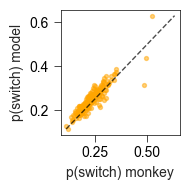

In [136]:
import matplotlib.pyplot as plt

# Scatter PPC for switch rate
plt.figure(figsize=(2, 2))

x = ppc_sticky['switch_obs'].values
y = ppc_sticky['switch_sim'].values

plt.scatter(x, y, s=8, alpha=0.5, color='orange')

# Identity line
mn = np.nanmin([x.min(), y.min()])
mx = np.nanmax([x.max(), y.max()])
plt.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1, alpha=0.7, color='black')

plt.xlabel('p(switch) monkey', fontsize=10)
plt.ylabel('p(switch) model', fontsize=10)
plt.grid(False)
plt.tight_layout()

model_name = 'sticky_rl'
fig_path_model = os.path.join(fig_path, model_name)
os.makedirs(fig_path_model, exist_ok=True)
plt.savefig(os.path.join(fig_path_model, "switch_rate_comparison_sticky.svg"), dpi=300, bbox_inches="tight")

plt.show()


ΔAIC summary (sticky - baseline):
count    180.000000
mean     -61.666343
std       43.325119
min     -186.961976
25%      -88.735375
50%      -51.618957
75%      -25.502973
max        1.982473
Name: delta_aic, dtype: float64
Sticky model better by AIC in 176 / 180 sessions


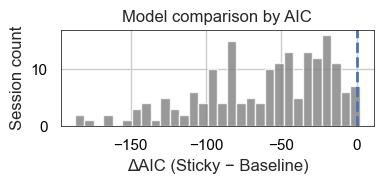

In [102]:
# ============================================================
# POINT 1: Quantify model improvement (Sticky RL vs baseline RL)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Assumes:
# - fit_compare dataframe exists
# - Columns: 'aic_rl', 'aic_s', 'delta_aic' (delta = sticky - baseline)

# --- Summary statistics for ΔAIC ---
print("ΔAIC summary (sticky - baseline):")
print(fit_compare['delta_aic'].describe())

# --- Count sessions where sticky model is better ---
n_better = (fit_compare['delta_aic'] < 0).sum()
print(f"Sticky model better by AIC in {n_better} / {len(fit_compare)} sessions")

# --- Visualize ΔAIC distribution ---
plt.figure(figsize=(4, 2))

plt.hist(fit_compare['delta_aic'], bins=30, alpha=0.8, color='grey')
plt.axvline(0, linestyle='--', linewidth=2)

plt.xlabel('ΔAIC (Sticky − Baseline)')
plt.ylabel('Session count')
plt.title('Model comparison by AIC')

plt.tight_layout()
plt.savefig(os.path.join(fig_path_model, "delta_aic_sticky_vs_baseline.svg"), dpi=300, bbox_inches="tight")
plt.show()


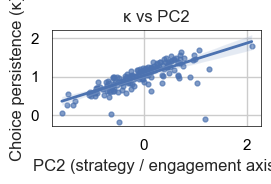

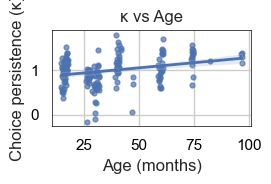

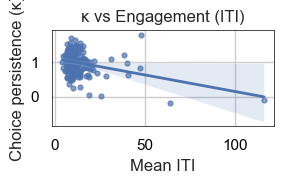

In [103]:
# ============================================================
# POINT 2: Relate stickiness (κ) to behavioral axes and age
# ============================================================

import seaborn as sns

# Build a local analysis table (safe copy)
kappa_df = fit_sticky_df.merge(
    summary_df[['Session_ID', 'PC2', 'Current_Age_Months', 'iti_mean']],
    on='Session_ID',
    how='inner'
).copy()

# --- Plot κ vs PC2 ---
plt.figure(figsize=(3, 2))
sns.regplot(
    data=kappa_df,
    x='PC2',
    y='kappa_s',
    scatter_kws={'s': 12, 'alpha': 0.7},
    line_kws={'linewidth': 2}
)
plt.xlabel('PC2 (strategy / engagement axis)')
plt.ylabel('Choice persistence (κ)')
plt.title('κ vs PC2')
plt.tight_layout()
plt.show()

# --- Plot κ vs Age ---
plt.figure(figsize=(3, 2))
sns.regplot(
    data=kappa_df,
    x='Current_Age_Months',
    y='kappa_s',
    scatter_kws={'s': 12, 'alpha': 0.7},
    line_kws={'linewidth': 2}
)
plt.xlabel('Age (months)')
plt.ylabel('Choice persistence (κ)')
plt.title('κ vs Age')
plt.tight_layout()
plt.show()

# --- Plot κ vs ITI ---
plt.figure(figsize=(3, 2))
sns.regplot(
    data=kappa_df,
    x='iti_mean',
    y='kappa_s',
    scatter_kws={'s': 12, 'alpha': 0.7},
    line_kws={'linewidth': 2}
)
plt.xlabel('Mean ITI')
plt.ylabel('Choice persistence (κ)')
plt.title('κ vs Engagement (ITI)')
plt.tight_layout()
plt.show()


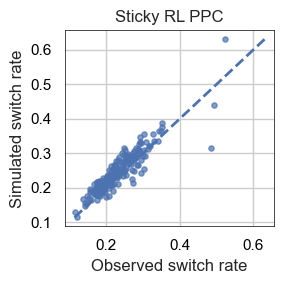

PPC Spearman rho = 0.909, p = 1.55e-69


In [104]:
# ============================================================
# POINT 3: Posterior predictive check for Sticky RL
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Assumes ppc_sticky exists with:
# - 'switch_obs' : observed switch rate
# - 'switch_sim' : simulated switch rate (sticky RL)

# --- Scatter: observed vs simulated switch rate ---
plt.figure(figsize=(3, 3))

x = ppc_sticky['switch_obs'].values
y = ppc_sticky['switch_sim'].values

plt.scatter(x, y, s=14, alpha=0.7)

# Identity line
mn = np.nanmin([x.min(), y.min()])
mx = np.nanmax([x.max(), y.max()])
plt.plot([mn, mx], [mn, mx], linestyle='--', linewidth=2)

plt.xlabel('Observed switch rate')
plt.ylabel('Simulated switch rate')
plt.title('Sticky RL PPC')

plt.tight_layout()
plt.show()

# --- Quantify PPC correlation ---
from scipy.stats import spearmanr

rho, pval = spearmanr(x, y, nan_policy='omit')
print(f"PPC Spearman rho = {rho:.3f}, p = {pval:.2e}")


In [106]:
# ============================================================
# Clean test: identify the primary aging axis (PC2 vs κ vs α)
# ============================================================
# Goal:
#   1) κ ~ age
#   2) PC2 ~ age
#   3) κ ~ PC2
#   4) κ ~ age + PC2
#   5) Repeat 1/3/4 for α
# Notes:
#   - Uses robust (HC3) SEs like your earlier regressions
#   - Uses ONLY local merged copies (does NOT modify summary_df or trial df)
# ============================================================

import pandas as pd
import statsmodels.formula.api as smf

# --- Build a single local table containing the variables we need ---
# Assumes:
#   fit_sticky_df has: Session_ID, kappa_s (and optionally converged_s)
#   summary_df has: Session_ID, alpha_y, PC2, Current_Age_Months
analysis_df = (
    fit_sticky_df[['Session_ID', 'kappa_s']]
    .merge(summary_df[['Session_ID', 'alpha', 'PC2', 'Current_Age_Months']], on='Session_ID', how='inner')
    .dropna()
    .copy()
)

# --- (Optional) If you want to exclude non-converged sticky fits, uncomment: ---
# analysis_df = analysis_df.merge(fit_sticky_df[['Session_ID','converged_s']], on='Session_ID', how='left')
# analysis_df = analysis_df[analysis_df['converged_s'] == True].copy()

def fit_ols(formula, df, label):
    """Fit OLS with HC3 robust SEs and print a compact summary."""
    m = smf.ols(formula, data=df).fit(cov_type='HC3')
    print("\n" + "="*70)
    print(label)
    print("="*70)
    print(m.summary())
    return m

# -------------------------------
# κ tests (stickiness)
# -------------------------------

# 1) κ ~ age
m_k_age = fit_ols(
    "kappa_s ~ Current_Age_Months",
    analysis_df,
    "1) kappa ~ age"
)

# 2) PC2 ~ age (sanity check / reproduce)
m_pc2_age = fit_ols(
    "PC2 ~ Current_Age_Months",
    analysis_df,
    "2) PC2 ~ age"
)

# 3) κ ~ PC2
m_k_pc2 = fit_ols(
    "kappa_s ~ PC2",
    analysis_df,
    "3) kappa ~ PC2"
)

# 4) κ ~ age + PC2 (does age drop out?)
m_k_age_pc2 = fit_ols(
    "kappa_s ~ Current_Age_Months + PC2",
    analysis_df,
    "4) kappa ~ age + PC2"
)

# -------------------------------
# α tests (learning rate)
# -------------------------------

# 5a) α ~ age
m_a_age = fit_ols(
    "alpha ~ Current_Age_Months",
    analysis_df,
    "5a) alpha ~ age"
)

# 5b) α ~ PC2
m_a_pc2 = fit_ols(
    "alpha ~ PC2",
    analysis_df,
    "5b) alpha ~ PC2"
)

# 5c) α ~ age + PC2 (does age drop out?)
m_a_age_pc2 = fit_ols(
    "alpha ~ Current_Age_Months + PC2",
    analysis_df,
    "5c) alpha ~ age + PC2"
)

# ------------------------------------------------------------
# Optional: quick coefficient table for easy comparison
# ------------------------------------------------------------
coef_table = pd.DataFrame({
    'model': [
        'kappa~age', 'PC2~age', 'kappa~PC2', 'kappa~age+PC2',
        'alpha~age', 'alpha~PC2', 'alpha~age+PC2'
    ],
    'age_coef': [
        m_k_age.params.get('Current_Age_Months', float('nan')),
        m_pc2_age.params.get('Current_Age_Months', float('nan')),
        float('nan'),
        m_k_age_pc2.params.get('Current_Age_Months', float('nan')),
        m_a_age.params.get('Current_Age_Months', float('nan')),
        float('nan'),
        m_a_age_pc2.params.get('Current_Age_Months', float('nan')),
    ],
    'age_p': [
        m_k_age.pvalues.get('Current_Age_Months', float('nan')),
        m_pc2_age.pvalues.get('Current_Age_Months', float('nan')),
        float('nan'),
        m_k_age_pc2.pvalues.get('Current_Age_Months', float('nan')),
        m_a_age.pvalues.get('Current_Age_Months', float('nan')),
        float('nan'),
        m_a_age_pc2.pvalues.get('Current_Age_Months', float('nan')),
    ],
    'pc2_coef': [
        float('nan'),
        float('nan'),
        m_k_pc2.params.get('PC2', float('nan')),
        m_k_age_pc2.params.get('PC2', float('nan')),
        float('nan'),
        m_a_pc2.params.get('PC2', float('nan')),
        m_a_age_pc2.params.get('PC2', float('nan')),
    ],
    'pc2_p': [
        float('nan'),
        float('nan'),
        m_k_pc2.pvalues.get('PC2', float('nan')),
        m_k_age_pc2.pvalues.get('PC2', float('nan')),
        float('nan'),
        m_a_pc2.pvalues.get('PC2', float('nan')),
        m_a_age_pc2.pvalues.get('PC2', float('nan')),
    ],
    'R2': [
        m_k_age.rsquared,
        m_pc2_age.rsquared,
        m_k_pc2.rsquared,
        m_k_age_pc2.rsquared,
        m_a_age.rsquared,
        m_a_pc2.rsquared,
        m_a_age_pc2.rsquared,
    ]
})

print("\n" + "="*70)
print("Compact coefficient table (robust SE models):")
print("="*70)
print(coef_table)



1) kappa ~ age
                            OLS Regression Results                            
Dep. Variable:                kappa_s   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     25.06
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           1.33e-06
Time:                        17:20:40   Log-Likelihood:                -46.574
No. Observations:                 180   AIC:                             97.15
Df Residuals:                     178   BIC:                             103.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           

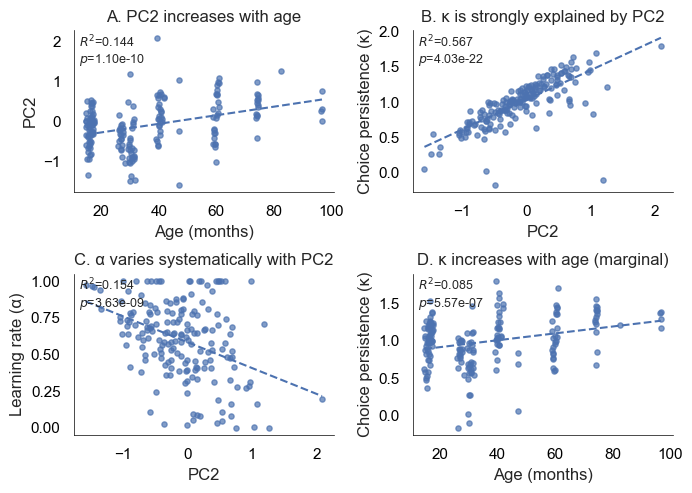

In [109]:
# ============================================================
# Summary figure: Age → PC2, and PC2 → (κ, α)
# Panels:
#   A) PC2 vs Age
#   B) κ vs PC2
#   C) α vs PC2
#   D) κ vs Age (optional sanity panel; easy to swap to α vs Age)
# Style:
#   - black axes, linewidth=0.5, no grids
#   - does NOT modify summary_df / fit_sticky_df
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ----------------------------
# Global style (axes black, 0.5, no grids)
# ----------------------------
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "font.size": 9,
})

def _despine(ax):
    """Remove top/right spines and ensure remaining spines are black and thin."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(0.5)
    ax.grid(False)

def _fit_ols(formula, df):
    """OLS with HC3 robust SEs (matches your earlier fits)."""
    return smf.ols(formula, data=df).fit(cov_type="HC3")

def _scatter_with_fit(ax, x, y, xlabel, ylabel, title, model, xlim=None, ylim=None):
    """Scatter + fitted line from statsmodels model; add R2 and p-value annotation."""
    # Scatter
    ax.scatter(x, y, s=14, alpha=0.7)

    # Fit line over x-range
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    pred_df = pd.DataFrame({model.model.exog_names[1]: x_line})  # assumes single predictor
    y_line = model.predict(pred_df)
    ax.plot(x_line, y_line, linestyle="--", linewidth=1.5)

    # Labels / title
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Optional limits
    if xlim is not None: ax.set_xlim(xlim)
    if ylim is not None: ax.set_ylim(ylim)

    # Annotation: R2 + p of predictor
    pred_name = model.model.exog_names[1]
    p_val = model.pvalues.get(pred_name, np.nan)
    r2 = model.rsquared
    ax.text(
        0.02, 0.98,
        f"$R^2$={r2:.3f}\n$p$={p_val:.2e}",
        transform=ax.transAxes,
        ha="left", va="top"
    )

    _despine(ax)

# ----------------------------
# Build local analysis table (safe merge; no master DF edits)
# ----------------------------
analysis_df = (
    fit_sticky_df[["Session_ID", "kappa_s"]]
    .merge(summary_df[["Session_ID", "alpha", "PC2", "Current_Age_Months"]], on="Session_ID", how="inner")
    .dropna()
    .copy()
)

# ----------------------------
# Fit the models (robust HC3)
# ----------------------------
m_pc2_age   = _fit_ols("PC2 ~ Current_Age_Months", analysis_df)
m_k_pc2     = _fit_ols("kappa_s ~ PC2", analysis_df)
m_a_pc2     = _fit_ols("alpha ~ PC2", analysis_df)
m_k_age     = _fit_ols("kappa_s ~ Current_Age_Months", analysis_df)  # swap to alpha_y ~ age if preferred

# ----------------------------
# Create 2x2 figure
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.0))  # adjust size as needed

# A) PC2 vs Age
ax = axes[0, 0]
_scatter_with_fit(
    ax,
    x=analysis_df["Current_Age_Months"].values,
    y=analysis_df["PC2"].values,
    xlabel="Age (months)",
    ylabel="PC2",
    title="A. PC2 increases with age",
    model=m_pc2_age
)

# B) κ vs PC2
ax = axes[0, 1]
_scatter_with_fit(
    ax,
    x=analysis_df["PC2"].values,
    y=analysis_df["kappa_s"].values,
    xlabel="PC2",
    ylabel="Choice persistence (κ)",
    title="B. κ is strongly explained by PC2",
    model=m_k_pc2
)

# C) α vs PC2
ax = axes[1, 0]
_scatter_with_fit(
    ax,
    x=analysis_df["PC2"].values,
    y=analysis_df["alpha"].values,
    xlabel="PC2",
    ylabel="Learning rate (α)",
    title="C. α varies systematically with PC2",
    model=m_a_pc2
)

# D) κ vs Age (optional sanity panel)
#    If you’d rather show alpha vs age, change y=alpha and model=m_a_age
ax = axes[1, 1]
_scatter_with_fit(
    ax,
    x=analysis_df["Current_Age_Months"].values,
    y=analysis_df["kappa_s"].values,
    xlabel="Age (months)",
    ylabel="Choice persistence (κ)",
    title="D. κ increases with age (marginal)",
    model=m_k_age
)

plt.tight_layout()
plt.show()

# ----------------------------
# Optional: save as vector for paper
# ----------------------------

fig.savefig(os.path.join(fig_path_model, "summary_age_pc2_kappa_alpha.svg"), bbox_inches="tight")


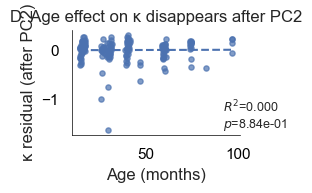

                            OLS Regression Results                            
Dep. Variable:        kappa_resid_pc2   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                   0.02117
Date:                Wed, 07 Jan 2026   Prob (F-statistic):              0.884
Time:                        17:21:26   Log-Likelihood:                 20.819
No. Observations:                 180   AIC:                            -37.64
Df Residuals:                     178   BIC:                            -31.25
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0034      0

In [110]:
# ============================================================
# Panel D (primary aging axis visualization):
#   Residualize kappa by PC2, then test residual kappa vs age.
# Interpretation:
#   If Age -> kappa disappears after controlling for PC2, then
#   kappa_resid should show ~no association with age.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Local analysis table (safe copy; does not modify master dfs) ---
analysis_df = (
    fit_sticky_df[['Session_ID', 'kappa_s']]
    .merge(summary_df[['Session_ID', 'alpha', 'PC2', 'Current_Age_Months']], on='Session_ID', how='inner')
    .dropna()
    .copy()
)

# --- Style: black axes, thin, no grids ---
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "font.size": 9,
})

def despine(ax):
    # Remove top/right spines and ensure remaining are black & thin
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(0.5)
    ax.grid(False)

# ------------------------------------------------------------
# Step 1: Residualize kappa by PC2
# ------------------------------------------------------------
# Model: kappa ~ PC2
m_k_pc2 = smf.ols("kappa_s ~ PC2", data=analysis_df).fit(cov_type="HC3")

# Residual kappa = observed - predicted (removes the PC2 component)
analysis_df["kappa_resid_pc2"] = m_k_pc2.resid

# ------------------------------------------------------------
# Step 2: Test residual kappa vs age
# ------------------------------------------------------------
m_resid_age = smf.ols("kappa_resid_pc2 ~ Current_Age_Months", data=analysis_df).fit(cov_type="HC3")

# ------------------------------------------------------------
# Step 3: Plot residual kappa vs age (this is the “primary axis” panel)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 2))

x = analysis_df["Current_Age_Months"].values
y = analysis_df["kappa_resid_pc2"].values

ax.scatter(x, y, s=14, alpha=0.7)

# Fit line from residual-age regression
x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
y_line = m_resid_age.predict(pd.DataFrame({"Current_Age_Months": x_line}))
ax.plot(x_line, y_line, linestyle="--", linewidth=1.5)

ax.set_xlabel("Age (months)")
ax.set_ylabel("κ residual (after PC2)")
ax.set_title("D. Age effect on κ disappears after PC2")

# Annotate p-value (should be non-significant if PC2 is primary axis)
p_age = m_resid_age.pvalues.get("Current_Age_Months", np.nan)
r2 = m_resid_age.rsquared
ax.text(0.9, 0.02, f"$R^2$={r2:.3f}\n$p$={p_age:.2e}", transform=ax.transAxes,
        ha="left", va="bottom")

despine(ax)
plt.tight_layout()
plt.show()

# Optional: print the regression summary for the residual test
print(m_resid_age.summary())


In [146]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# --- Q-learning with forgetting and bias ---
def q_learning_loglik_forgetting(params, choices, rewards):
    """
    Q-learning with forgetting on unchosen action and choice bias.
    
    Parameters:
    - alpha: learning rate for chosen action
    - phi: forgetting rate for unchosen action
    - beta: inverse temperature
    - bias: additive bias toward choice=1 (left spout)
    
    Returns negative log-likelihood.
    """
    alpha, phi, beta, bias = params
    
    # Parameter bounds check
    if not (0 <= alpha <= 1 and 0 <= phi <= 1 and beta > 0):
        return 1e10
    
    Q = np.array([0.5, 0.5])  # Initialize Q-values for [right=0, left=1]
    log_lik = 0.0
    
    for t in range(len(choices)):
        choice = int(choices[t])
        reward = rewards[t]
        
        # Compute choice probabilities with bias
        # P(left) gets the bias added to its Q-value
        logits = beta * np.array([Q[0], Q[1] + bias])
        logits -= logits.max()  # numerical stability
        probs = np.exp(logits) / np.sum(np.exp(logits))
        
        # Accumulate log-likelihood
        log_lik += np.log(probs[choice] + 1e-12)
        
        # Update Q-values
        chosen_idx = choice
        unchosen_idx = 1 - choice
        
        # Chosen: standard delta-rule
        Q[chosen_idx] += alpha * (reward - Q[chosen_idx])
        
        # Unchosen: forgetting/decay
        Q[unchosen_idx] -= phi * Q[unchosen_idx]
    
    return -log_lik

# --- Fit the forgetting model ---
def fit_forgetting_model(choices, rewards):
    """Fit Q-learning with forgetting and bias to choice/reward data."""
    
    # Multiple random initializations for robustness
    best_result = None
    best_nll = np.inf
    
    for _ in range(5):
        # Random initialization
        init_params = [
            np.random.uniform(0.01, 0.5),  # alpha
            np.random.uniform(0.01, 0.3),  # phi
            np.random.uniform(1, 10),      # beta
            np.random.uniform(-0.5, 0.5)   # bias
        ]
        
        result = minimize(
            q_learning_loglik_forgetting,
            init_params,
            args=(choices, rewards),
            method='L-BFGS-B',
            bounds=[(0.001, 1), (0.001, 1), (0.1, 50), (-5, 5)]
        )
        
        if result.fun < best_nll:
            best_nll = result.fun
            best_result = result
    
    alpha, phi, beta, bias = best_result.x
    return {
        'alpha': alpha,
        'phi': phi,
        'beta': beta,
        'bias': bias,
        'nll': best_result.fun,
        'success': best_result.success
    }

# --- Build trial table ---
trial_df = tmp_8020_reversal[['Session_ID', 'Decision', 'Reward']].dropna().copy()
trial_df['Decision'] = trial_df['Decision'].astype(int)
trial_df['Reward'] = trial_df['Reward'].astype(int)

# --- Fit forgetting model per session ---
forgetting_fits = []
for sid, sub in trial_df.groupby('Session_ID'):
    choices = sub['Decision'].values
    rewards = sub['Reward'].values
    
    if len(choices) < 10:  # Skip sessions with too few trials
        continue
    
    fit_result = fit_forgetting_model(choices, rewards)
    fit_result['Session_ID'] = sid
    fit_result['n_trials'] = len(choices)
    forgetting_fits.append(fit_result)

forgetting_df = pd.DataFrame(forgetting_fits)

# --- Compare models ---
def nll_bias_only(choices):
    p = np.clip(np.mean(choices), 1e-6, 1 - 1e-6)
    ll = np.sum(choices * np.log(p) + (1 - choices) * np.log(1 - p))
    return -ll

def aic_bic(nll, k, n):
    aic = 2 * k + 2 * nll
    bic = k * np.log(max(n, 1)) + 2 * nll
    return aic, bic

# Add comparison metrics
comparison_rows = []
for sid, sub in trial_df.groupby('Session_ID'):
    choices = sub['Decision'].values
    n = len(choices)
    
    if sid not in forgetting_df['Session_ID'].values:
        continue
    
    # Get forgetting model fit
    forg_row = forgetting_df[forgetting_df['Session_ID'] == sid].iloc[0]
    nll_forg = forg_row['nll']
    
    # Baselines
    nll_bias = nll_bias_only(choices)
    nll_rand = -np.log(0.5) * n
    
    # Information criteria (forgetting has 4 params)
    aic_forg, bic_forg = aic_bic(nll_forg, k=4, n=n)
    aic_bias, bic_bias = aic_bic(nll_bias, k=1, n=n)
    
    # Pseudo-R2
    pseudo_r2 = 1 - (nll_forg / nll_bias) if nll_bias != 0 else np.nan
    
    comparison_rows.append({
        'Session_ID': sid,
        'n_trials': n,
        'alpha': forg_row['alpha'],
        'phi': forg_row['phi'],
        'beta': forg_row['beta'],
        'bias': forg_row['bias'],
        'nll_forgetting': nll_forg,
        'nll_bias': nll_bias,
        'aic_forgetting': aic_forg,
        'aic_bias': aic_bias,
        'bic_forgetting': bic_forg,
        'bic_bias': bic_bias,
        'pseudo_r2_vs_bias': pseudo_r2
    })

comparison_df = pd.DataFrame(comparison_rows)

# --- Summary ---
print("\n=== Forgetting Model Parameter Summary ===")
print(comparison_df[['alpha', 'phi', 'beta', 'bias']].describe())

print("\n=== Model Comparison ===")
print(f"Forgetting better than bias-only (AIC): {(comparison_df['aic_forgetting'] < comparison_df['aic_bias']).sum()} / {len(comparison_df)}")
print(f"Mean pseudo-R²: {comparison_df['pseudo_r2_vs_bias'].mean():.3f}")

# --- Merge back to your original summary ---
# You can join this with summary_df on Session_ID if you want all parameters together


=== Forgetting Model Parameter Summary ===
            alpha         phi        beta        bias
count  185.000000  185.000000  185.000000  185.000000
mean     0.628288    0.949820    2.414618    0.012038
std      0.201716    0.177391    0.723722    0.372416
min      0.001000    0.001000    0.100000   -0.703183
25%      0.514232    1.000000    2.022818   -0.090158
50%      0.607369    1.000000    2.426094   -0.028720
75%      0.768494    1.000000    2.911181    0.035538
max      1.000000    1.000000    5.830887    4.713357

=== Model Comparison ===
Forgetting better than bias-only (AIC): 176 / 185
Mean pseudo-R²: 0.198


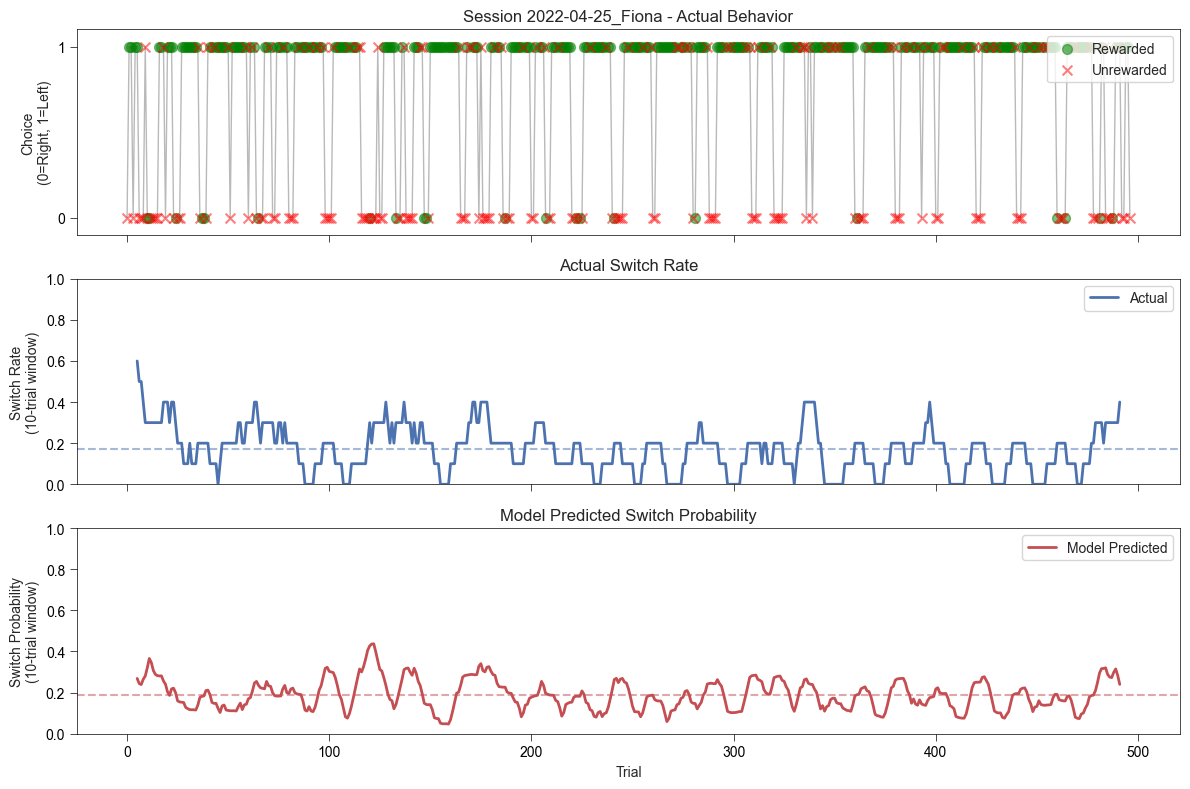

KeyboardInterrupt: 

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def simulate_forgetting_model(params, rewards, n_sims=1000):
    """
    Simulate the forgetting model to generate choice probabilities and switch predictions.
    
    Returns:
    - mean_switch_prob: average probability of switching on each trial
    - switch_samples: array of simulated switches (n_sims x n_trials)
    """
    alpha, phi, beta, bias = params
    n_trials = len(rewards)
    
    # Store switch probabilities and simulated choices
    switch_probs = np.zeros(n_trials - 1)
    all_choices = np.zeros((n_sims, n_trials))
    
    for sim in range(n_sims):
        Q = np.array([0.5, 0.5])
        choices = np.zeros(n_trials, dtype=int)
        
        for t in range(n_trials):
            # Compute choice probabilities
            logits = beta * np.array([Q[0], Q[1] + bias])
            logits -= logits.max()
            probs = np.exp(logits) / np.sum(np.exp(logits))
            
            # Sample choice
            choices[t] = np.random.choice([0, 1], p=probs)
            
            # Update Q-values
            chosen_idx = choices[t]
            unchosen_idx = 1 - choices[t]
            Q[chosen_idx] += alpha * (rewards[t] - Q[chosen_idx])
            Q[unchosen_idx] -= phi * Q[unchosen_idx]
        
        all_choices[sim, :] = choices
    
    # Compute switch rates
    switches = np.diff(all_choices, axis=1) != 0
    mean_switch_prob = switches.mean(axis=0)
    
    return mean_switch_prob, switches

def plot_switch_comparison(trial_df, comparison_df, session_id):
    """
    Plot actual vs predicted switch behavior for a single session.
    """
    # Get session data
    session_data = trial_df[trial_df['Session_ID'] == session_id].copy()
    session_params = comparison_df[comparison_df['Session_ID'] == session_id].iloc[0]
    
    choices = session_data['Decision'].values
    rewards = session_data['Reward'].values
    
    # Actual switches
    actual_switches = np.diff(choices) != 0
    
    # Model predictions
    params = [session_params['alpha'], session_params['phi'], 
              session_params['beta'], session_params['bias']]
    pred_switch_prob, _ = simulate_forgetting_model(params, rewards, n_sims=1000)
    
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
    # Panel 1: Rewards and choices
    ax = axes[0]
    trials = np.arange(len(choices))
    
    # Plot rewards as background
    reward_trials = trials[rewards == 1]
    ax.scatter(reward_trials, choices[rewards == 1], c='green', s=50, 
               alpha=0.5, label='Rewarded', zorder=2)
    no_reward_trials = trials[rewards == 0]
    ax.scatter(no_reward_trials, choices[rewards == 0], c='red', s=50, 
               alpha=0.5, marker='x', label='Unrewarded', zorder=2)
    
    ax.plot(trials, choices, 'k-', alpha=0.3, linewidth=1, zorder=1)
    ax.set_ylabel('Choice\n(0=Right, 1=Left)')
    ax.set_ylim([-0.1, 1.1])
    ax.set_yticks([0, 1])
    ax.legend(loc='upper right')
    ax.set_title(f'Session {session_id} - Actual Behavior')
    
    # Panel 2: Actual switch rate (smoothed)
    ax = axes[1]
    window = 10
    actual_switch_smooth = np.convolve(actual_switches.astype(float), 
                                       np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window//2, len(actual_switches) - window//2 + 1), 
            actual_switch_smooth, 'b-', linewidth=2, label='Actual')
    ax.axhline(actual_switches.mean(), color='b', linestyle='--', alpha=0.5)
    ax.set_ylabel('Switch Rate\n(10-trial window)')
    ax.set_ylim([0, 1])
    ax.legend(loc='upper right')
    ax.set_title('Actual Switch Rate')
    
    # Panel 3: Model predicted switch probability
    ax = axes[2]
    pred_switch_smooth = np.convolve(pred_switch_prob, 
                                     np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window//2, len(pred_switch_prob) - window//2 + 1), 
            pred_switch_smooth, 'r-', linewidth=2, label='Model Predicted')
    ax.axhline(pred_switch_prob.mean(), color='r', linestyle='--', alpha=0.5)
    ax.set_ylabel('Switch Probability\n(10-trial window)')
    ax.set_xlabel('Trial')
    ax.set_ylim([0, 1])
    ax.legend(loc='upper right')
    ax.set_title('Model Predicted Switch Probability')
    
    plt.tight_layout()
    return fig

def plot_aggregate_switch_comparison(trial_df, comparison_df):
    """
    Plot aggregate switch rate comparison across all sessions.
    """
    actual_rates = []
    predicted_rates = []
    session_ids = []
    
    for sid in comparison_df['Session_ID'].unique():
        session_data = trial_df[trial_df['Session_ID'] == sid]
        session_params = comparison_df[comparison_df['Session_ID'] == sid].iloc[0]
        
        if len(session_data) < 20:
            continue
        
        choices = session_data['Decision'].values
        rewards = session_data['Reward'].values
        
        # Actual switch rate
        actual_switches = np.diff(choices) != 0
        actual_rate = actual_switches.mean()
        
        # Model predicted
        params = [session_params['alpha'], session_params['phi'], 
                  session_params['beta'], session_params['bias']]
        pred_switch_prob, _ = simulate_forgetting_model(params, rewards, n_sims=500)
        pred_rate = pred_switch_prob.mean()
        
        actual_rates.append(actual_rate)
        predicted_rates.append(pred_rate)
        session_ids.append(sid)
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter plot
    ax = axes[0]
    ax.scatter(actual_rates, predicted_rates, alpha=0.6, s=50)
    
    # Unity line
    min_val = min(min(actual_rates), min(predicted_rates))
    max_val = max(max(actual_rates), max(predicted_rates))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Unity')
    
    # Correlation
    corr = np.corrcoef(actual_rates, predicted_rates)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Actual Switch Rate')
    ax.set_ylabel('Model Predicted Switch Rate')
    ax.set_title('Session-Level Switch Rate Comparison')
    ax.legend()
    ax.set_aspect('equal')
    
    # Distribution comparison
    ax = axes[1]
    ax.hist(actual_rates, bins=20, alpha=0.5, label='Actual', density=True)
    ax.hist(predicted_rates, bins=20, alpha=0.5, label='Model', density=True)
    ax.set_xlabel('Switch Rate')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of Switch Rates')
    ax.legend()
    
    plt.tight_layout()
    
    # Print summary stats
    print("\n=== Switch Rate Comparison ===")
    print(f"Mean actual switch rate: {np.mean(actual_rates):.3f} ± {np.std(actual_rates):.3f}")
    print(f"Mean predicted switch rate: {np.mean(predicted_rates):.3f} ± {np.std(predicted_rates):.3f}")
    print(f"Correlation: r = {corr:.3f}")
    print(f"RMSE: {np.sqrt(np.mean((np.array(actual_rates) - np.array(predicted_rates))**2)):.3f}")
    
    return fig

# --- Example usage ---

# Plot single session
example_session = comparison_df['Session_ID'].iloc[0]
fig1 = plot_switch_comparison(trial_df, comparison_df, example_session)
plt.show()

# Plot aggregate comparison
fig2 = plot_aggregate_switch_comparison(trial_df, comparison_df)
plt.show()

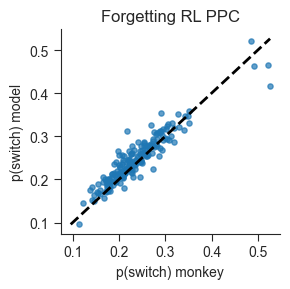

PPC Spearman rho = 0.918, p = 1.31e-74
RMSE = 0.025
Mean observed: 0.236 ± 0.063
Mean simulated: 0.247 ± 0.058


In [159]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

def compute_ppc_forgetting(trial_df, comparison_df, n_sims=1000):
    """
    Compute posterior predictive check data for the forgetting model.
    Returns DataFrame with observed and simulated switch rates per session.
    """
    ppc_rows = []
    
    for sid in comparison_df['Session_ID'].unique():
        session_data = trial_df[trial_df['Session_ID'] == sid]
        session_params = comparison_df[comparison_df['Session_ID'] == sid].iloc[0]
        
        if len(session_data) < 20:
            continue
        
        choices = session_data['Decision'].values
        rewards = session_data['Reward'].values
        
        # Observed switch rate
        actual_switches = np.diff(choices) != 0
        switch_obs = actual_switches.mean()
        
        # Simulate model predictions
        params = [session_params['alpha'], session_params['phi'], 
                  session_params['beta'], session_params['bias']]
        
        alpha, phi, beta, bias = params
        n_trials = len(rewards)
        
        # Run multiple simulations
        all_switches = []
        for sim in range(n_sims):
            Q = np.array([0.5, 0.5])
            sim_choices = np.zeros(n_trials, dtype=int)
            
            for t in range(n_trials):
                # Compute choice probabilities
                logits = beta * np.array([Q[0], Q[1] + bias])
                logits -= logits.max()
                probs = np.exp(logits) / np.sum(np.exp(logits))
                
                # Sample choice
                sim_choices[t] = np.random.choice([0, 1], p=probs)
                
                # Update Q-values
                chosen_idx = sim_choices[t]
                unchosen_idx = 1 - sim_choices[t]
                Q[chosen_idx] += alpha * (rewards[t] - Q[chosen_idx])
                Q[unchosen_idx] -= phi * Q[unchosen_idx]
            
            # Compute switch rate for this simulation
            sim_switches = np.diff(sim_choices) != 0
            all_switches.append(sim_switches.mean())
        
        # Average simulated switch rate
        switch_sim = np.mean(all_switches)
        
        ppc_rows.append({
            'Session_ID': sid,
            'switch_obs': switch_obs,
            'switch_sim': switch_sim
        })
    
    return pd.DataFrame(ppc_rows)

# ============================================================
# Compute PPC data
# ============================================================
ppc_forgetting = compute_ppc_forgetting(trial_df, comparison_df, n_sims=10)

# ============================================================
# POSTERIOR PREDICTIVE CHECK PLOT
# ============================================================

plt.figure(figsize=(3, 3))

x = ppc_forgetting['switch_obs'].values
y = ppc_forgetting['switch_sim'].values

plt.scatter(x, y, s=14, alpha=0.7)

# Identity line
mn = np.nanmin([x.min(), y.min()])
mx = np.nanmax([x.max(), y.max()])
plt.plot([mn, mx], [mn, mx], linestyle='--', linewidth=2, color='black')

plt.xlabel('p(switch) monkey')
plt.ylabel('p(switch) model')
plt.title('Forgetting RL PPC')
sns.despine()

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(f"{save_path}/ppc_forgetting.svg", dpi=300)
plt.show()

# ============================================================
# Quantify PPC correlation
# ============================================================
rho, pval = spearmanr(x, y, nan_policy='omit')
print(f"PPC Spearman rho = {rho:.3f}, p = {pval:.2e}")

# Additional diagnostics
rmse = np.sqrt(np.mean((x - y)**2))
print(f"RMSE = {rmse:.3f}")
print(f"Mean observed: {x.mean():.3f} ± {x.std():.3f}")
print(f"Mean simulated: {y.mean():.3f} ± {y.std():.3f}")

In [162]:
tmp_8020_reversal.columns

Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'BlockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Col

Fitting sessions: 100%|██████████| 187/187 [04:28<00:00,  1.44s/it]



=== Animal-Level Parameter Summary ===
  Animal_Name  alpha_mean  alpha_std  alpha_sem  phi_mean   phi_std   phi_sem  \
0       Fiona    0.557873   0.143349   0.032054  0.950050  0.223383  0.049950   
1    Knuckles    0.536424   0.122295   0.020382  0.966520  0.110752  0.018459   
2       Sonic    0.571158   0.115799   0.025269  0.993542  0.022454  0.004900   
3   Sunflower    0.796335   0.213763   0.030854  0.927203  0.209804  0.030283   
4        Zazu    0.595346   0.200183   0.025843  0.927023  0.226765  0.029275   

   beta_mean  beta_std  beta_sem  bias_mean  bias_std  bias_sem  n_sessions  
0   2.766916  0.763323  0.170684   0.103153  0.786901  0.175956          20  
1   2.357891  0.474483  0.079081  -0.023404  0.060454  0.010076          36  
2   2.788346  0.320207  0.069875  -0.059468  0.072287  0.015774          21  
3   2.015898  0.682255  0.098475   0.136515  0.690454  0.099658          48  
4   2.559857  0.833376  0.107588  -0.029688  0.163415  0.021097          60  

=== 

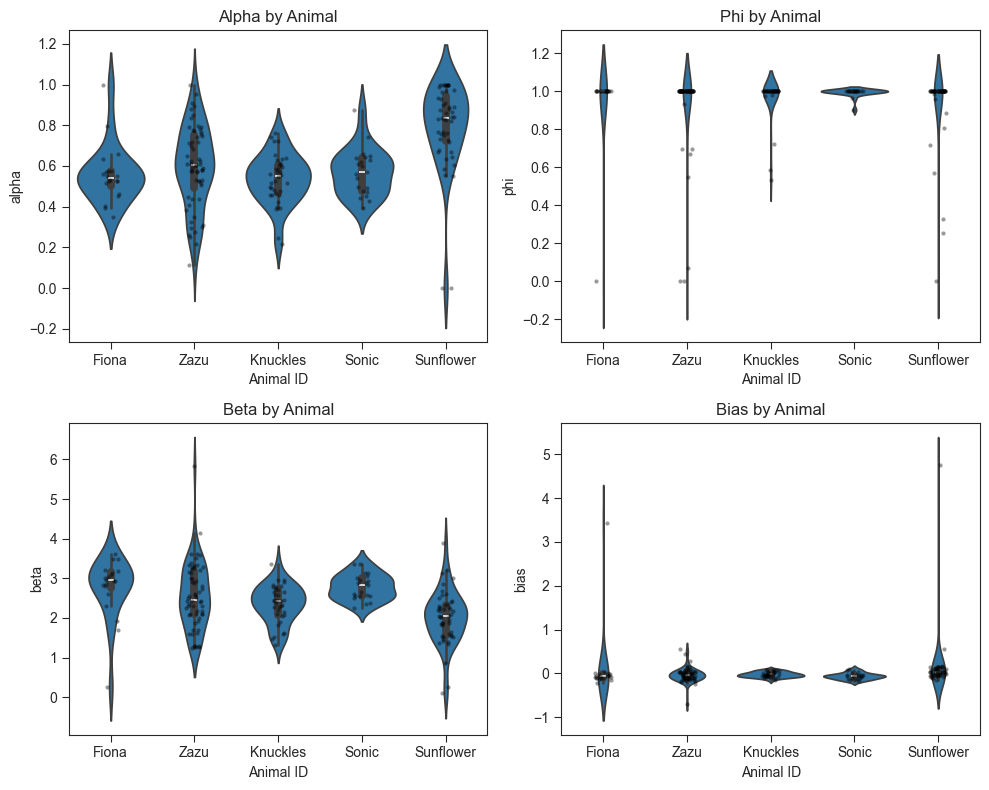

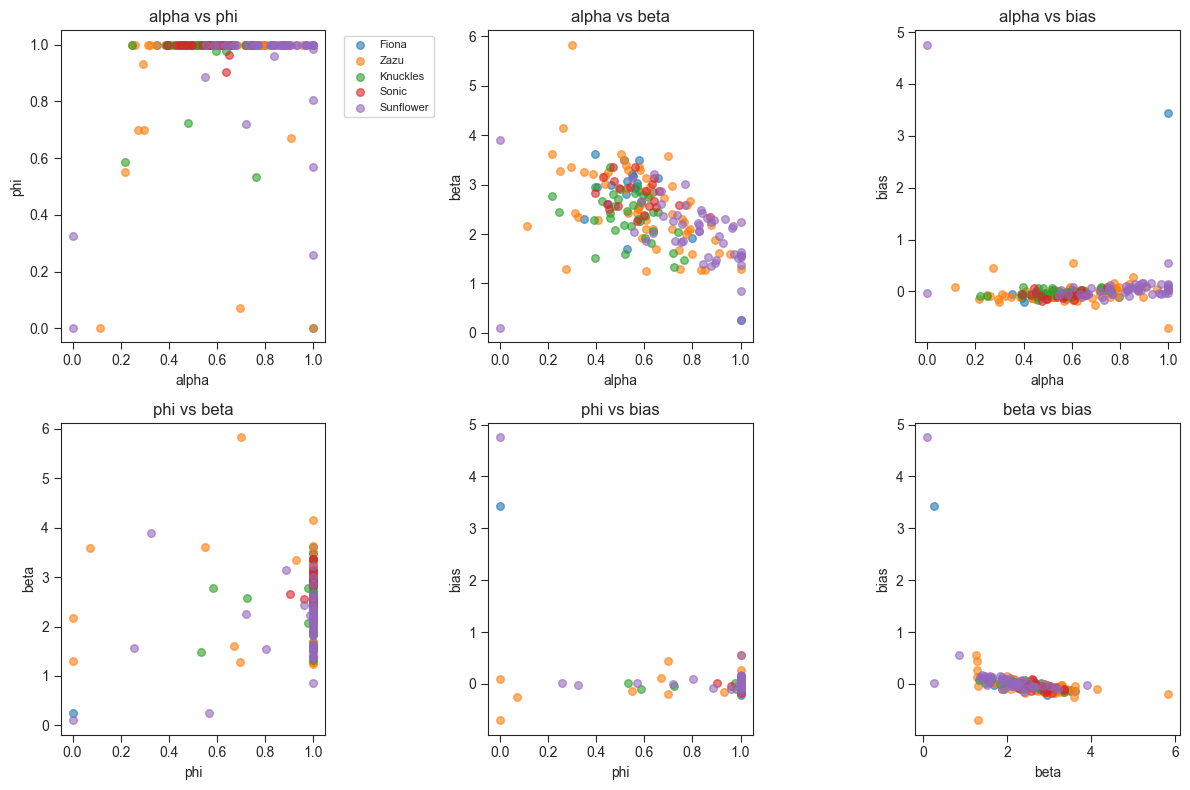

KeyError: 'Animal_ID'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats

# ============================================================
# 1. FIT ALL SESSIONS (if not already done)
# ============================================================

def q_learning_loglik_forgetting(params, choices, rewards):
    """Q-learning with forgetting and bias - returns negative log-likelihood."""
    alpha, phi, beta, bias = params
    
    if not (0 <= alpha <= 1 and 0 <= phi <= 1 and beta > 0):
        return 1e10
    
    Q = np.array([0.5, 0.5])
    log_lik = 0.0
    
    for t in range(len(choices)):
        choice = int(choices[t])
        reward = rewards[t]
        
        logits = beta * np.array([Q[0], Q[1] + bias])
        logits -= logits.max()
        probs = np.exp(logits) / np.sum(np.exp(logits))
        
        log_lik += np.log(probs[choice] + 1e-12)
        
        chosen_idx = choice
        unchosen_idx = 1 - choice
        Q[chosen_idx] += alpha * (reward - Q[chosen_idx])
        Q[unchosen_idx] -= phi * Q[unchosen_idx]
    
    return -log_lik

def fit_forgetting_model(choices, rewards):
    """Fit forgetting model with multiple random starts."""
    best_result = None
    best_nll = np.inf
    
    for _ in range(5):
        init_params = [
            np.random.uniform(0.01, 0.5),   # alpha
            np.random.uniform(0.01, 0.3),   # phi
            np.random.uniform(1, 10),       # beta
            np.random.uniform(-0.5, 0.5)    # bias
        ]
        
        result = minimize(
            q_learning_loglik_forgetting,
            init_params,
            args=(choices, rewards),
            method='L-BFGS-B',
            bounds=[(0.001, 1), (0.001, 1), (0.1, 50), (-5, 5)]
        )
        
        if result.fun < best_nll:
            best_nll = result.fun
            best_result = result
    
    alpha, phi, beta, bias = best_result.x
    return {
        'alpha': alpha,
        'phi': phi,
        'beta': beta,
        'bias': bias,
        'nll': best_result.fun,
        'success': best_result.success
    }

# Fit all sessions (with progress tracking)
from tqdm import tqdm

trial_df = tmp_8020_reversal[['Session_ID', 'Animal_Name', 'Decision', 'Reward']].dropna().copy()
trial_df['Decision'] = trial_df['Decision'].astype(int)
trial_df['Reward'] = trial_df['Reward'].astype(int)

forgetting_fits = []
for sid, sub in tqdm(trial_df.groupby('Session_ID'), desc="Fitting sessions"):
    choices = sub['Decision'].values
    rewards = sub['Reward'].values
    
    if len(choices) < 10:
        continue
    
    fit_result = fit_forgetting_model(choices, rewards)
    fit_result['Session_ID'] = sid
    fit_result['Animal_Name'] = sub['Animal_Name'].iloc[0]
    fit_result['n_trials'] = len(choices)
    forgetting_fits.append(fit_result)

session_fits = pd.DataFrame(forgetting_fits)

# ============================================================
# 2. AGGREGATE BY ANIMAL
# ============================================================

# Compute animal-level summaries
animal_params = session_fits.groupby('Animal_Name').agg({
    'alpha': ['mean', 'std', 'sem'],
    'phi': ['mean', 'std', 'sem'],
    'beta': ['mean', 'std', 'sem'],
    'bias': ['mean', 'std', 'sem'],
    'Session_ID': 'count'  # number of sessions
}).reset_index()

# Flatten column names
animal_params.columns = ['_'.join(col).strip('_') for col in animal_params.columns]
animal_params.rename(columns={'Session_ID_count': 'n_sessions'}, inplace=True)

print("\n=== Animal-Level Parameter Summary ===")
print(animal_params)

# ============================================================
# 3. STATISTICAL TESTS
# ============================================================

# Test if parameters differ across animals (one-way ANOVA)
from scipy.stats import f_oneway

params_to_test = ['alpha', 'phi', 'beta', 'bias']
print("\n=== One-way ANOVA: Do parameters differ across animals? ===")

for param in params_to_test:
    groups = [group[param].values for name, group in session_fits.groupby('Animal_Name')]
    F, p = f_oneway(*groups)
    print(f"{param}: F = {F:.3f}, p = {p:.4f}")



In [168]:
tmp_8020_reversal.columns

Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'BlockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Col


Sessions with age data: 185
Age range: 14.5 - 96.8 months


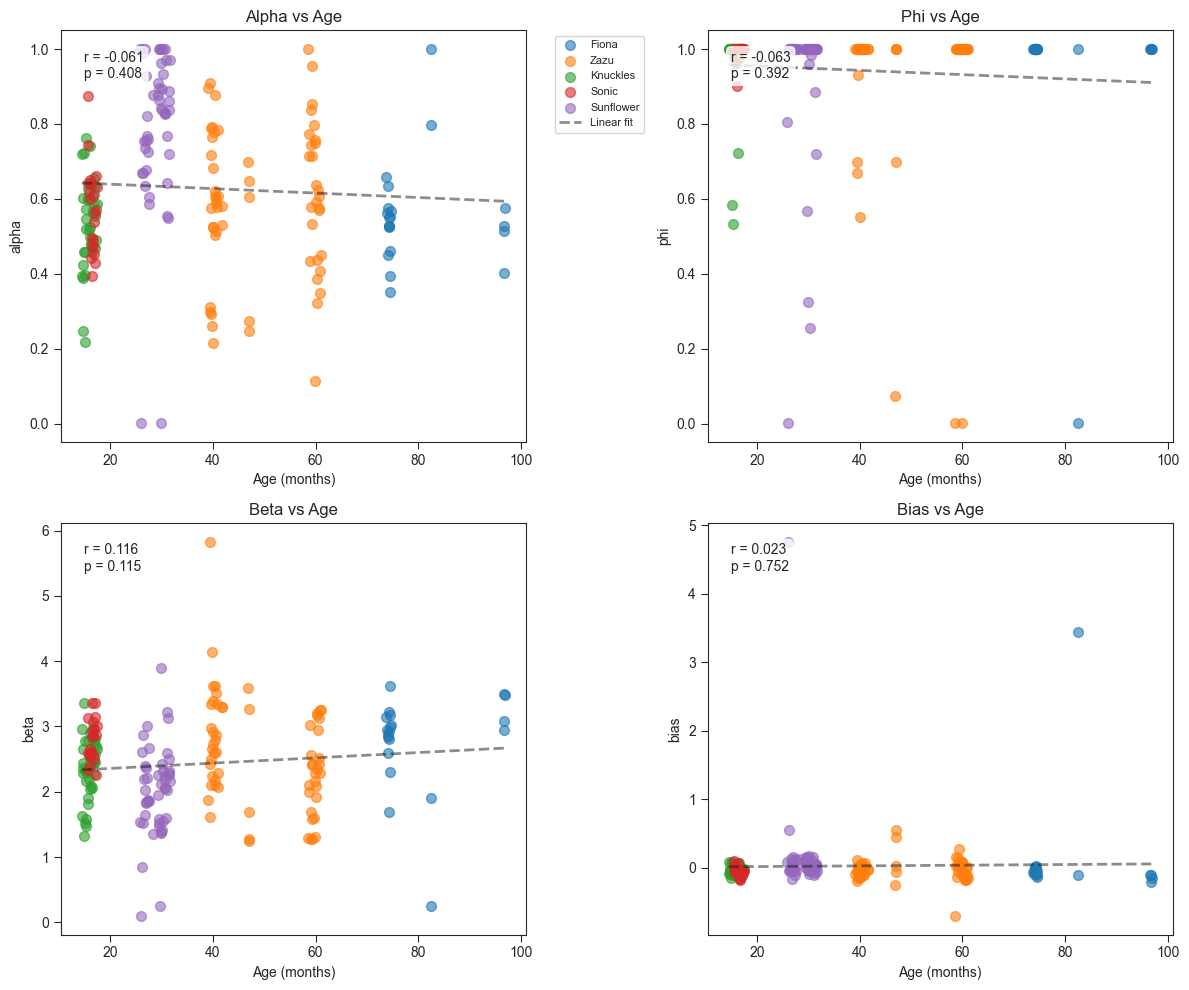

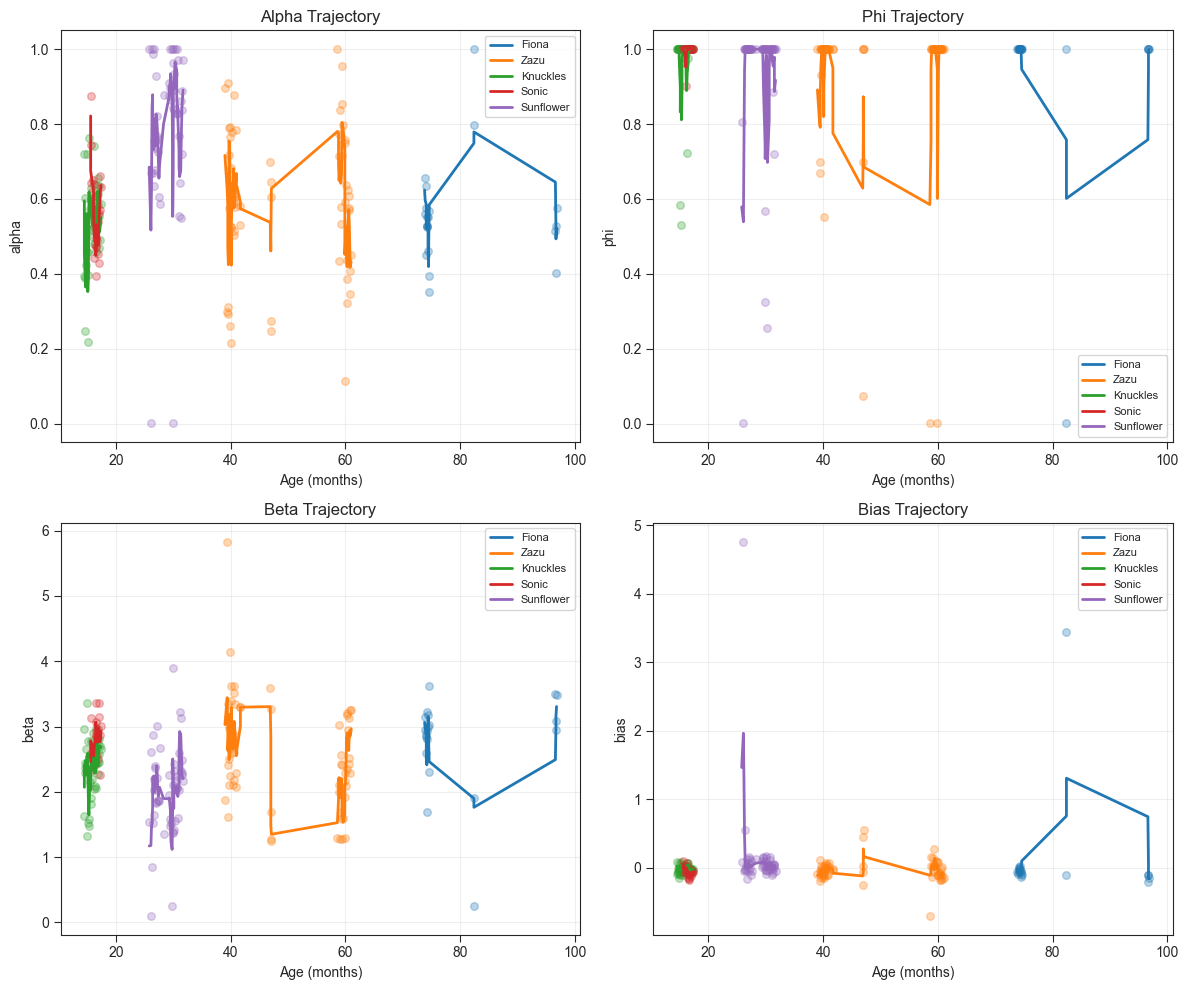

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/1159378277.py:141: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in data_clean.groupby('Age_bin')]
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/1159378277.py:141: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in data_clean.groupby('Age_bin')]
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/1159378277.py:141: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

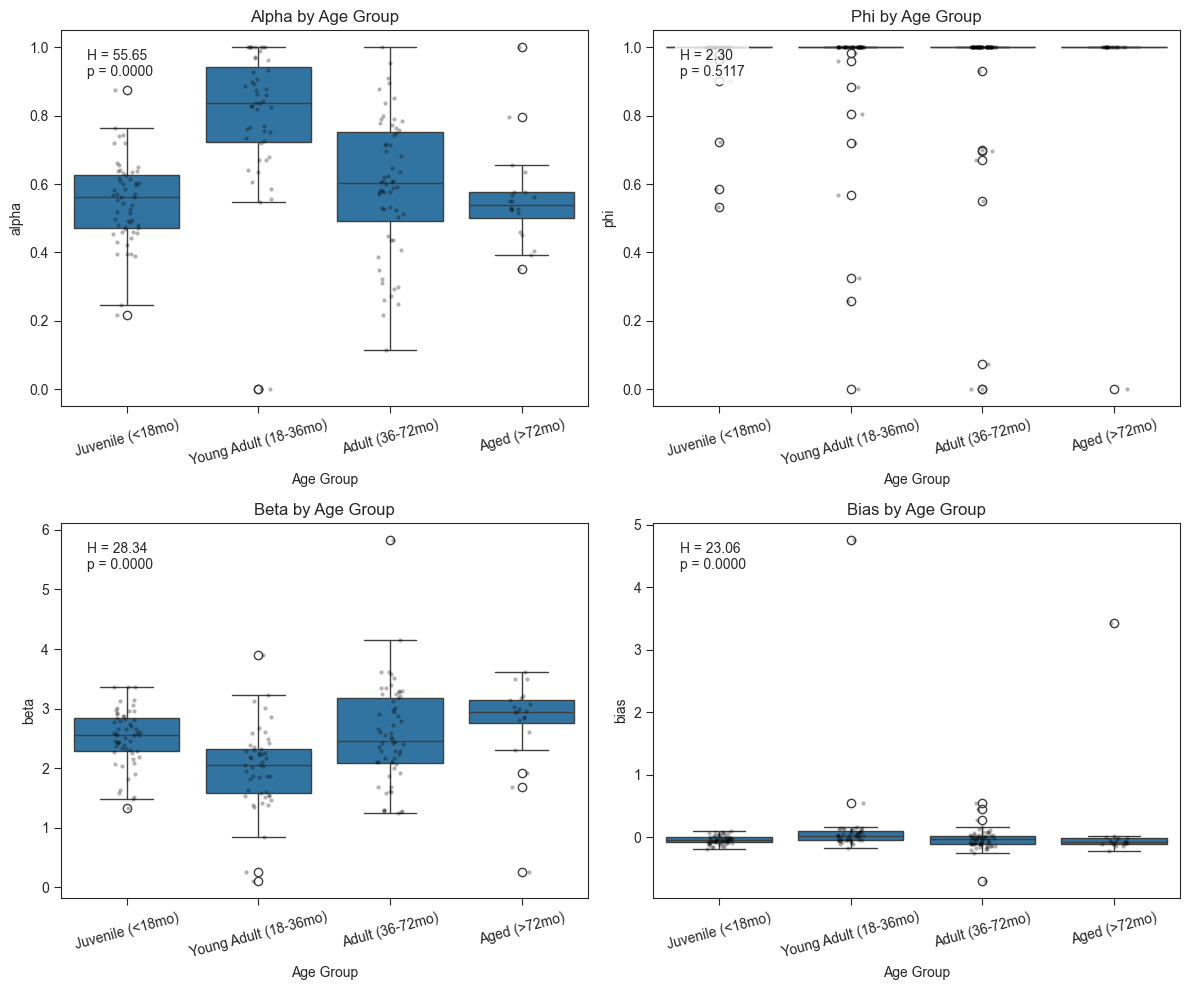


=== Mixed Effects Models: Parameters ~ Age ===

Model: alpha ~ Current_Age_Months + (1|Animal)
                    Coef. Std.Err.      z  P>|z|  [0.025 0.975]
Intercept           0.603    0.078  7.722  0.000   0.450  0.756
Current_Age_Months  0.000    0.002  0.164  0.869  -0.003  0.003
Group Var           0.012    0.055                             

Age effect: β = 0.00025, p = 0.8694

Model: phi ~ Current_Age_Months + (1|Animal)
                     Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept            0.967    0.058  16.554  0.000   0.852  1.081
Current_Age_Months  -0.001    0.001  -0.715  0.475  -0.002  0.001
Group Var            0.000    0.059                              

Age effect: β = -0.00056, p = 0.4748

Model: beta ~ Current_Age_Months + (1|Animal)
                     Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept            2.729    0.357   7.641  0.000   2.029  3.429
Current_Age_Months  -0.006    0.008  -0.812  0.417  -0.021  0.009
Group Var         

/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: Convergen


Model: bias ~ Current_Age_Months + (1|Animal)
                     Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept           -0.001    0.091  -0.010  0.992  -0.179  0.177
Current_Age_Months   0.001    0.002   0.350  0.726  -0.003  0.005
Group Var            0.006    0.024                              

Age effect: β = 0.00072, p = 0.7264


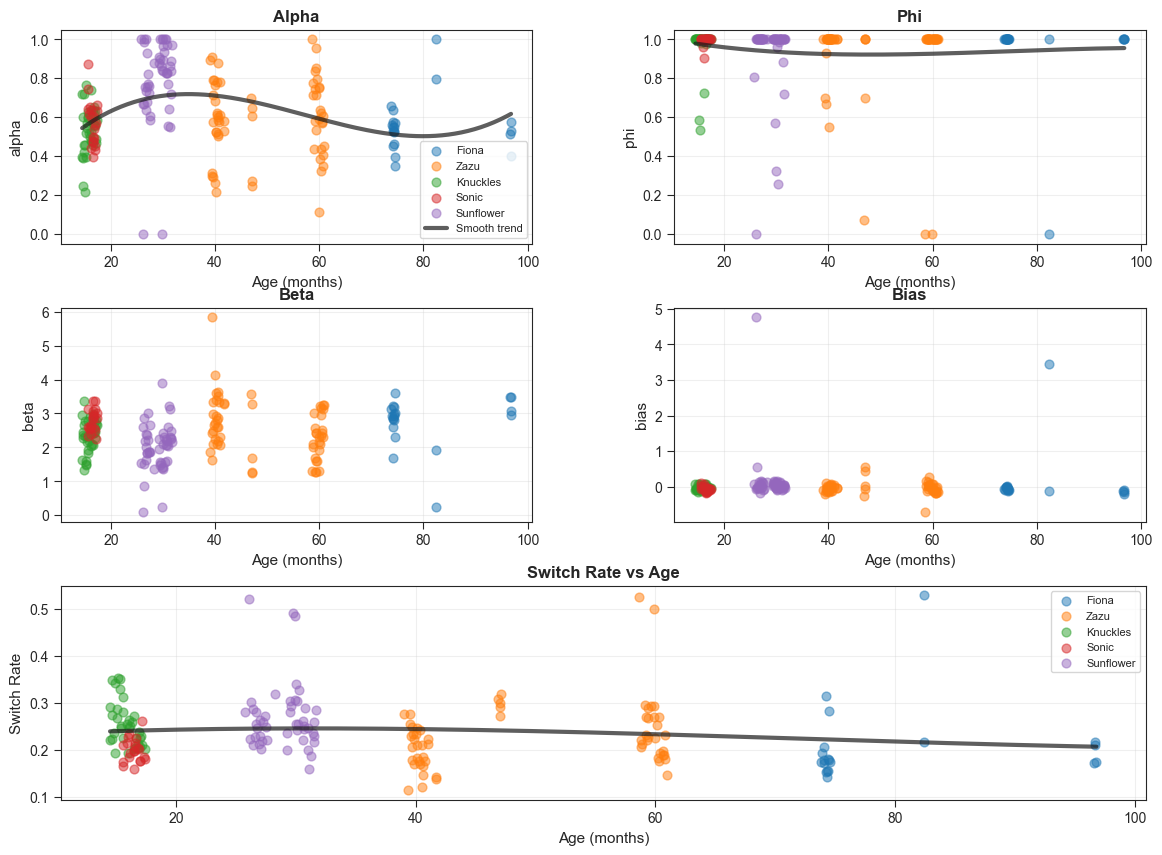


=== Parameter Summary by Age Group ===
                          alpha                       phi                  \
                           mean       std count      mean       std count   
Age_bin                                                                     
Juvenile (<18mo)       0.549220  0.120093    57  0.976475  0.089550    57   
Young Adult (18-36mo)  0.796335  0.213763    48  0.927203  0.209804    48   
Adult (36-72mo)        0.595346  0.200183    60  0.927023  0.226765    60   
Aged (>72mo)           0.557873  0.143349    20  0.950050  0.223383    20   

                           beta                      bias                  
                           mean       std count      mean       std count  
Age_bin                                                                    
Juvenile (<18mo)       2.516479  0.470333    57 -0.036691  0.066771    57  
Young Adult (18-36mo)  2.015898  0.682255    48  0.136515  0.690454    48  
Adult (36-72mo)        2.559857  0.83337

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/1159378277.py:282: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_by_age = session_fits_with_age.groupby('Age_bin')[params].agg(['mean', 'std', 'count'])


In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ============================================================
# 1. MERGE AGE DATA WITH FITTED PARAMETERS
# ============================================================

# Merge age info with fitted parameters
session_fits_with_age = session_fits.merge(
    tmp_8020_reversal[['Session_ID', 'Animal_Name', 'Current_Age_Months']].drop_duplicates(),
    left_on=['Session_ID', 'Animal_Name'],  # Animal_ID in session_fits
    right_on=['Session_ID', 'Animal_Name'],  # Animal_Name in tmp_8020_reversal
    how='left'
)

# Clean up - use Animal_Name consistently
session_fits_with_age['Animal'] = session_fits_with_age['Animal_Name']
session_fits_with_age = session_fits_with_age.drop(columns=['Animal_Name'], errors='ignore')

print(f"\nSessions with age data: {session_fits_with_age['Current_Age_Months'].notna().sum()}")
print(f"Age range: {session_fits_with_age['Current_Age_Months'].min():.1f} - {session_fits_with_age['Current_Age_Months'].max():.1f} months")

# ============================================================
# 2. PARAMETERS VS AGE - SCATTER PLOTS WITH REGRESSION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
params = ['alpha', 'phi', 'beta', 'bias']

for idx, param in enumerate(params):
    ax = axes[idx]
    
    # Plot each animal separately
    for animal in session_fits_with_age['Animal'].unique():
        animal_data = session_fits_with_age[session_fits_with_age['Animal'] == animal]
        animal_data = animal_data.dropna(subset=['Current_Age_Months', param])
        
        if len(animal_data) > 0:
            ax.scatter(animal_data['Current_Age_Months'], animal_data[param], 
                      label=animal, alpha=0.6, s=50)
    
    # Overall regression line
    data_clean = session_fits_with_age.dropna(subset=['Current_Age_Months', param])
    if len(data_clean) > 2:
        z = np.polyfit(data_clean['Current_Age_Months'], data_clean[param], 1)
        p = np.poly1d(z)
        age_range = np.linspace(data_clean['Current_Age_Months'].min(), 
                               data_clean['Current_Age_Months'].max(), 100)
        ax.plot(age_range, p(age_range), 'k--', linewidth=2, alpha=0.5, label='Linear fit')
        
        # Compute correlation
        r, pval = stats.pearsonr(data_clean['Current_Age_Months'], data_clean[param])
        ax.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.3f}', 
               transform=ax.transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Age (months)')
    ax.set_ylabel(param)
    ax.set_title(f'{param.capitalize()} vs Age')
    
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('params_vs_age_scatter.svg', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 3. PARAMETERS VS AGE - SMOOTHED TRAJECTORIES
# ============================================================

from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, param in enumerate(params):
    ax = axes[idx]
    
    for animal in session_fits_with_age['Animal'].unique():
        animal_data = session_fits_with_age[session_fits_with_age['Animal'] == animal]
        animal_data = animal_data.dropna(subset=['Current_Age_Months', param]).sort_values('Current_Age_Months')
        
        if len(animal_data) > 3:
            # Raw data
            ax.scatter(animal_data['Current_Age_Months'], animal_data[param], 
                      alpha=0.3, s=30)
            
            # Smoothed trajectory
            if len(animal_data) > 5:
                smoothed = gaussian_filter1d(animal_data[param].values, sigma=1)
                ax.plot(animal_data['Current_Age_Months'], smoothed, linewidth=2, 
                       label=animal)
    
    ax.set_xlabel('Age (months)')
    ax.set_ylabel(param)
    ax.set_title(f'{param.capitalize()} Trajectory')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('params_vs_age_trajectories.svg', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4. AGE BINS - PARAMETER COMPARISON
# ============================================================

# Create age bins for marmosets (adjust as needed)
# Typical marmoset lifespan ~12-16 years, sexual maturity ~18 months
session_fits_with_age['Age_bin'] = pd.cut(
    session_fits_with_age['Current_Age_Months'], 
    bins=[0, 18, 36, 72, 200],  # juvenile (<18mo), young adult, adult, aged
    labels=['Juvenile (<18mo)', 'Young Adult (18-36mo)', 'Adult (36-72mo)', 'Aged (>72mo)']
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, param in enumerate(params):
    ax = axes[idx]
    
    # Box plot by age bin
    data_clean = session_fits_with_age.dropna(subset=['Age_bin', param])
    
    if len(data_clean) > 0:
        sns.boxplot(data=data_clean, x='Age_bin', y=param, ax=ax)
        sns.stripplot(data=data_clean, x='Age_bin', y=param, ax=ax, 
                      color='black', alpha=0.3, size=3)
        
        ax.set_xlabel('Age Group')
        ax.set_ylabel(param)
        ax.set_title(f'{param.capitalize()} by Age Group')
        ax.tick_params(axis='x', rotation=15)
        
        # Statistical test (Kruskal-Wallis for non-parametric)
        groups = [group[param].dropna().values 
                  for name, group in data_clean.groupby('Age_bin')]
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            from scipy.stats import kruskal
            H, p = kruskal(*groups)
            ax.text(0.05, 0.95, f'H = {H:.2f}\np = {p:.4f}', 
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'params_by_age_bins.svg'), dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. MIXED EFFECTS MODEL WITH AGE
# ============================================================

try:
    import statsmodels.formula.api as smf
    
    print("\n=== Mixed Effects Models: Parameters ~ Age ===")
    
    for param in params:
        # Fit mixed effects: parameter ~ age + (1|Animal)
        data_for_model = session_fits_with_age.dropna(subset=[param, 'Current_Age_Months', 'Animal'])
        
        if len(data_for_model) > 10:
            model = smf.mixedlm(
                f"{param} ~ Current_Age_Months", 
                data=data_for_model,
                groups=data_for_model["Animal"]
            )
            result = model.fit()
            
            print(f"\n{'='*60}")
            print(f"Model: {param} ~ Current_Age_Months + (1|Animal)")
            print(f"{'='*60}")
            print(result.summary().tables[1])
            
            # Extract age effect
            age_coef = result.params['Current_Age_Months']
            age_pval = result.pvalues['Current_Age_Months']
            print(f"\nAge effect: β = {age_coef:.5f}, p = {age_pval:.4f}")
        
except ImportError:
    print("\nInstall statsmodels for mixed effects: pip install statsmodels")

# ============================================================
# 6. DEVELOPMENTAL TRAJECTORY - COMPOSITE PLOT
# ============================================================

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Top row: Learning parameters (alpha, phi)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Middle row: Decision parameters (beta, bias)
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Bottom row: Switch rate analysis
ax5 = fig.add_subplot(gs[2, :])

axes_params = [(ax1, 'alpha'), (ax2, 'phi'), (ax3, 'beta'), (ax4, 'bias')]

for ax, param in axes_params:
    for animal in session_fits_with_age['Animal'].unique():
        animal_data = session_fits_with_age[session_fits_with_age['Animal'] == animal]
        animal_data = animal_data.dropna(subset=['Current_Age_Months', param])
        ax.scatter(animal_data['Current_Age_Months'], animal_data[param], 
                  alpha=0.5, s=40, label=animal)
    
    # LOESS smoothing for overall trend
    data_clean = session_fits_with_age.dropna(subset=['Current_Age_Months', param])
    if len(data_clean) > 10:
        from scipy.interpolate import UnivariateSpline
        sorted_data = data_clean.sort_values('Current_Age_Months')
        try:
            spline = UnivariateSpline(sorted_data['Current_Age_Months'], 
                                     sorted_data[param], s=len(sorted_data)*0.1)
            age_smooth = np.linspace(sorted_data['Current_Age_Months'].min(), 
                                    sorted_data['Current_Age_Months'].max(), 200)
            ax.plot(age_smooth, spline(age_smooth), 'k-', linewidth=3, 
                   alpha=0.7, label='Smooth trend')
        except:
            pass
    
    ax.set_xlabel('Age (months)', fontsize=11)
    ax.set_ylabel(param, fontsize=11)
    ax.set_title(f'{param.capitalize()}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

ax1.legend(fontsize=8, loc='best')

# Bottom: Switch rate vs age
switch_data = []
for sid in session_fits_with_age['Session_ID'].unique():
    session_data = trial_df[trial_df['Session_ID'] == sid]
    age_data = session_fits_with_age[session_fits_with_age['Session_ID'] == sid]
    
    if len(age_data) > 0 and not age_data['Current_Age_Months'].isna().all():
        choices = session_data['Decision'].values
        if len(choices) > 1:
            switch_rate = (np.diff(choices) != 0).mean()
            age = age_data['Current_Age_Months'].iloc[0]
            animal = age_data['Animal'].iloc[0]
            switch_data.append({'Age': age, 'Switch_Rate': switch_rate, 'Animal': animal})

switch_df = pd.DataFrame(switch_data)

for animal in switch_df['Animal'].unique():
    animal_switch = switch_df[switch_df['Animal'] == animal]
    ax5.scatter(animal_switch['Age'], animal_switch['Switch_Rate'], 
               alpha=0.5, s=40, label=animal)

# Overall trend
if len(switch_df) > 10:
    sorted_switch = switch_df.sort_values('Age')
    try:
        spline = UnivariateSpline(sorted_switch['Age'], sorted_switch['Switch_Rate'], 
                                 s=len(sorted_switch)*0.01)
        age_smooth = np.linspace(sorted_switch['Age'].min(), sorted_switch['Age'].max(), 200)
        ax5.plot(age_smooth, spline(age_smooth), 'k-', linewidth=3, alpha=0.7)
    except:
        pass

ax5.set_xlabel('Age (months)', fontsize=11)
ax5.set_ylabel('Switch Rate', fontsize=11)
ax5.set_title('Switch Rate vs Age', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

plt.savefig(os.path.join(save_path, 'developmental_trajectory_composite.svg'), dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. SUMMARY STATISTICS BY AGE
# ============================================================

print("\n=== Parameter Summary by Age Group ===")
summary_by_age = session_fits_with_age.groupby('Age_bin')[params].agg(['mean', 'std', 'count'])
print(summary_by_age)

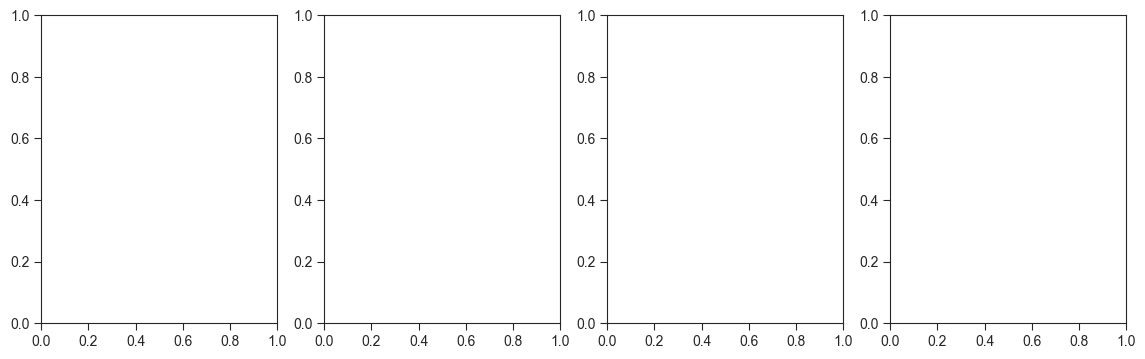

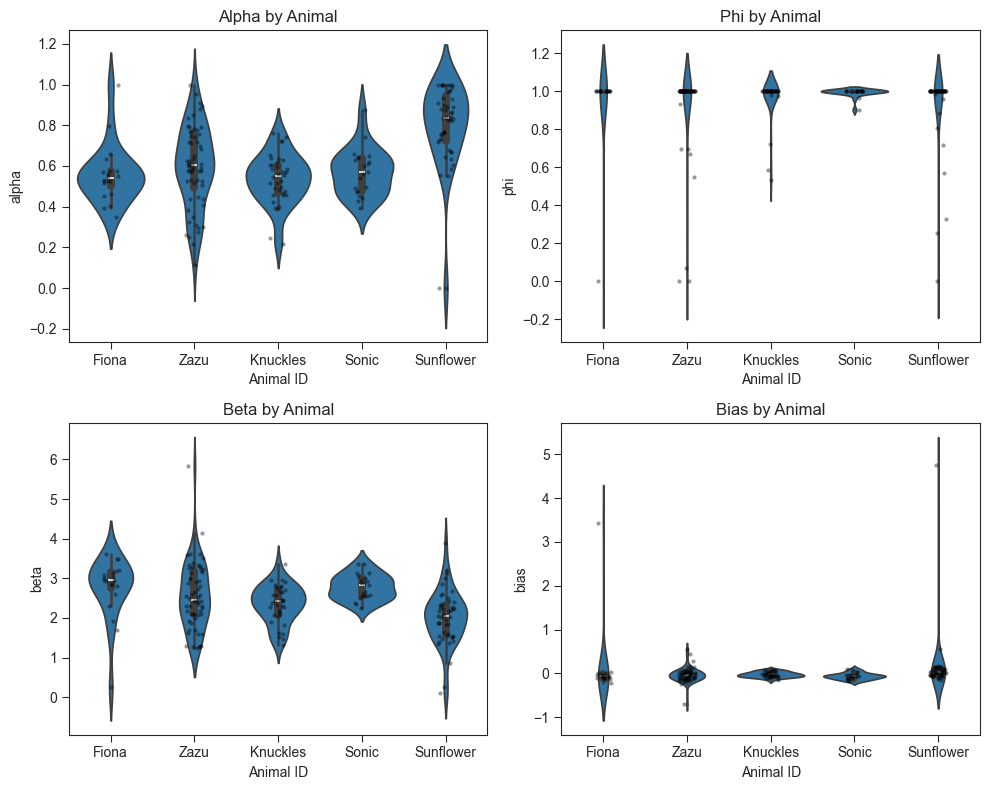

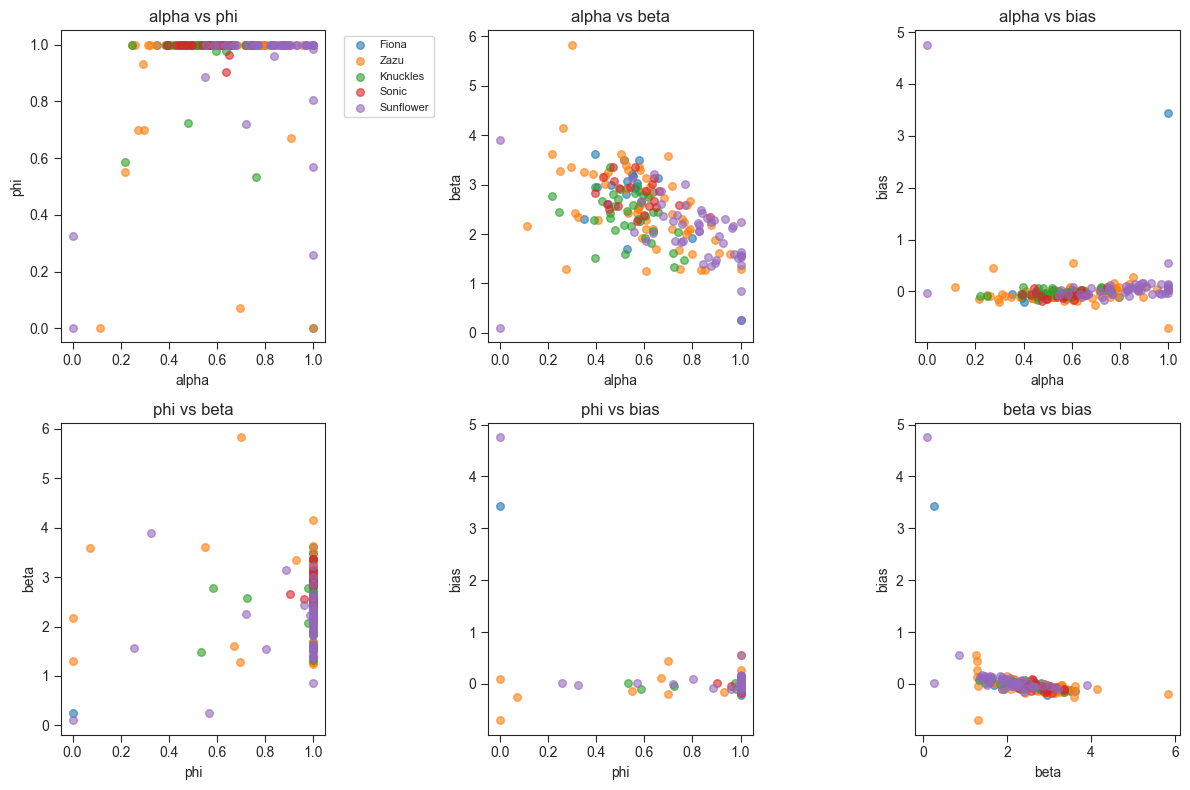

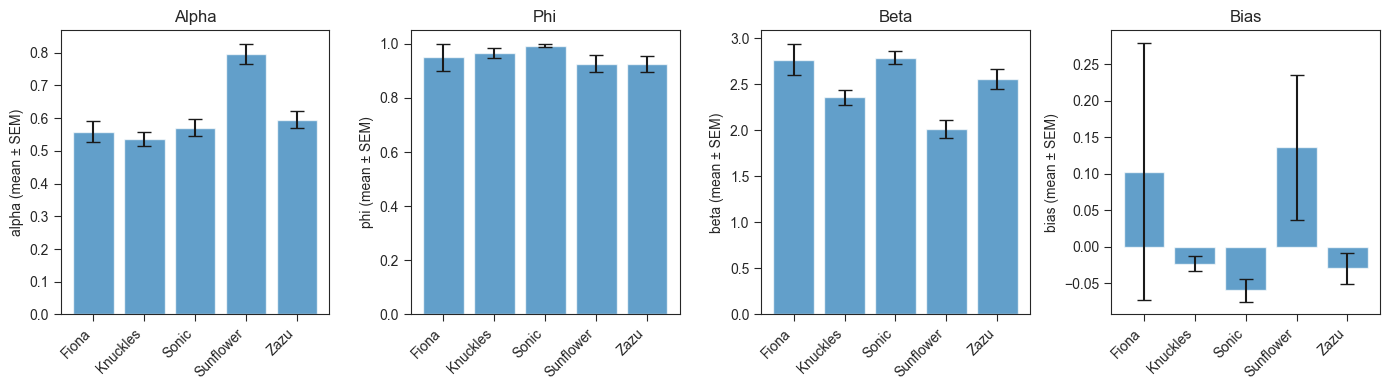


=== Mixed Effects Models ===

alpha:
               Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept      0.606    0.051  11.887  0.000   0.506  0.706
session_order  0.000    0.001   0.384  0.701  -0.002  0.002
Group Var      0.010    0.045                              

phi:
                Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept       0.950    0.031  30.884  0.000   0.890  1.010
session_order  -0.000    0.002  -0.100  0.920  -0.005  0.004
Group Var       0.000    0.019                              


/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



beta:
                Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept       2.512    0.150  16.695  0.000   2.217  2.807
session_order  -0.002    0.004  -0.413  0.679  -0.009  0.006
Group Var       0.075    0.084                              

bias:
                Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept       0.081    0.062   1.308  0.191  -0.040  0.203
session_order  -0.003    0.002  -1.213  0.225  -0.007  0.002
Group Var       0.003    0.014                              

=== Results saved ===
- session_level_forgetting_params.csv
- animal_level_forgetting_params.csv


/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/snn_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [166]:
# ============================================================
# 4. VISUALIZATIONS
# ============================================================

# --- Plot 1: Parameter distributions by animal ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, param in enumerate(params_to_test):
    ax = axes[idx]
    
    # Violin plot
    sns.violinplot(data=session_fits, x='Animal_Name', y=param, ax=ax, inner='box')
    
    # Add individual points
    sns.stripplot(data=session_fits, x='Animal_Name', y=param, ax=ax, 
                  size=3, alpha=0.4, color='black')
    
    ax.set_title(f'{param.capitalize()} by Animal')
    ax.set_xlabel('Animal ID')
    ax.set_ylabel(param)

plt.tight_layout()
plt.show()

# --- Plot 2: Parameter correlations within animal ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

param_pairs = [
    ('alpha', 'phi'),
    ('alpha', 'beta'),
    ('alpha', 'bias'),
    ('phi', 'beta'),
    ('phi', 'bias'),
    ('beta', 'bias')
]

for idx, (p1, p2) in enumerate(param_pairs):
    ax = axes[idx]
    
    for animal in session_fits['Animal_Name'].unique():
        animal_data = session_fits[session_fits['Animal_Name'] == animal]
        ax.scatter(animal_data[p1], animal_data[p2], label=animal, alpha=0.6, s=30)
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f'{p1} vs {p2}')
    
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# --- Plot 3: Mean parameters with error bars ---
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for idx, param in enumerate(params_to_test):
    ax = axes[idx]
    
    means = animal_params[f'{param}_mean'].values
    sems = animal_params[f'{param}_sem'].values
    animals = animal_params['Animal_Name'].values

    x_pos = np.arange(len(animals))
    ax.bar(x_pos, means, yerr=sems, capsize=5, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(animals, rotation=45, ha='right')
    ax.set_ylabel(f'{param} (mean ± SEM)')
    ax.set_title(param.capitalize())

plt.tight_layout()
plt.show()

# ============================================================
# 5. MIXED EFFECTS MODEL (optional - if you have age/session order)
# ============================================================

# If you have age or session order info, you can fit mixed effects:
# Example using statsmodels:

try:
    import statsmodels.formula.api as smf
    
    # Add session order if available
    session_fits['session_order'] = session_fits.groupby('Animal_Name').cumcount()
    
    print("\n=== Mixed Effects Models ===")
    for param in params_to_test:
        # Random intercept for animal
        model = smf.mixedlm(f"{param} ~ session_order", 
                           data=session_fits, 
                           groups=session_fits["Animal_Name"])
        result = model.fit()
        print(f"\n{param}:")
        print(result.summary().tables[1])
        
except ImportError:
    print("\nInstall statsmodels for mixed effects models: pip install statsmodels")

# ============================================================
# 6. SAVE RESULTS
# ============================================================

# Save session-level fits
session_fits.to_csv('session_level_forgetting_params.csv', index=False)

# Save animal-level summaries
animal_params.to_csv('animal_level_forgetting_params.csv', index=False)

print("\n=== Results saved ===")
print("- session_level_forgetting_params.csv")
print("- animal_level_forgetting_params.csv")

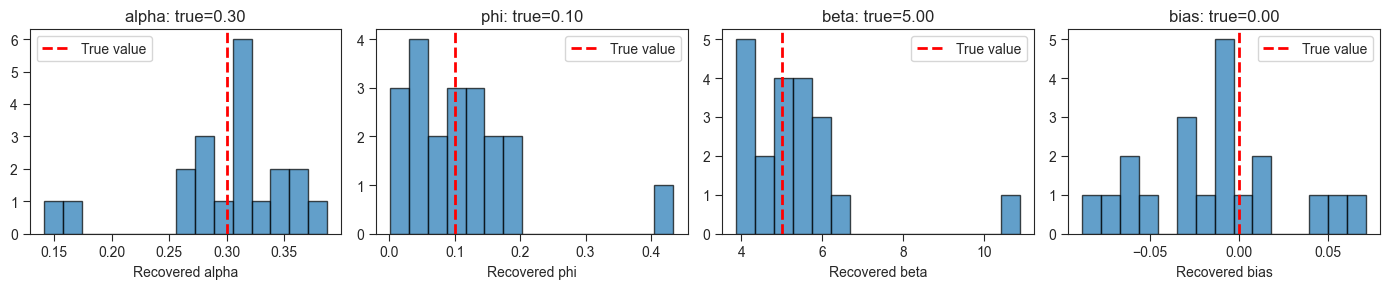

In [167]:
# --- Parameter recovery simulation ---
def simulate_and_recover_params(true_params, n_trials=200, n_reps=20):
    """Test if fitting procedure can recover known parameters."""
    alpha_true, phi_true, beta_true, bias_true = true_params
    recovered = []
    
    for rep in range(n_reps):
        # Simulate data with known params
        rewards = np.random.binomial(1, 0.5, n_trials)  # random rewards
        Q = np.array([0.5, 0.5])
        choices = []
        
        for t in range(n_trials):
            logits = beta_true * np.array([Q[0], Q[1] + bias_true])
            logits -= logits.max()
            probs = np.exp(logits) / np.sum(np.exp(logits))
            choice = np.random.choice([0, 1], p=probs)
            choices.append(choice)
            
            Q[choice] += alpha_true * (rewards[t] - Q[choice])
            Q[1-choice] -= phi_true * Q[1-choice]
        
        # Recover params
        fit = fit_forgetting_model(np.array(choices), rewards)
        recovered.append(fit)
    
    return pd.DataFrame(recovered)

# Run recovery
true_params = [0.3, 0.1, 5.0, 0.0]  # example true values
recovery_df = simulate_and_recover_params(true_params)

# Plot recovery
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
param_names = ['alpha', 'phi', 'beta', 'bias']
for idx, (param, true_val) in enumerate(zip(param_names, true_params)):
    ax = axes[idx]
    ax.hist(recovery_df[param], bins=15, alpha=0.7, edgecolor='black')
    ax.axvline(true_val, color='red', linestyle='--', linewidth=2, label='True value')
    ax.set_xlabel(f'Recovered {param}')
    ax.set_title(f'{param}: true={true_val:.2f}')
    ax.legend()
plt.tight_layout()
plt.show()

In [156]:
def compute_ppc_forgetting_fast(trial_df, comparison_df, n_sims=1000):
    """
    Fast vectorized version of PPC computation.
    """
    ppc_rows = []
    
    for sid in comparison_df['Session_ID'].unique():
        session_data = trial_df[trial_df['Session_ID'] == sid]
        session_params = comparison_df[comparison_df['Session_ID'] == sid].iloc[0]
        
        if len(session_data) < 20:
            continue
        
        choices = session_data['Decision'].values
        rewards = session_data['Reward'].values
        
        # Observed switch rate
        actual_switches = np.diff(choices) != 0
        switch_obs = actual_switches.mean()
        
        # Get parameters
        alpha = session_params['alpha']
        phi = session_params['phi']
        beta = session_params['beta']
        bias = session_params['bias']
        
        n_trials = len(rewards)
        
        # Vectorized simulation across all runs
        Q = np.full((n_sims, 2), 0.5)  # (n_sims, 2) Q-values
        sim_choices = np.zeros((n_sims, n_trials), dtype=int)
        
        for t in range(n_trials):
            # Compute choice probabilities for all simulations at once
            logits = beta * np.stack([Q[:, 0], Q[:, 1] + bias], axis=1)  # (n_sims, 2)
            logits -= logits.max(axis=1, keepdims=True)
            probs = np.exp(logits)
            probs /= probs.sum(axis=1, keepdims=True)
            
            # Sample choices for all simulations
            sim_choices[:, t] = (np.random.rand(n_sims) < probs[:, 1]).astype(int)
            
            # Update Q-values vectorized
            chosen_mask = sim_choices[:, t]  # 1 if left, 0 if right
            
            # Update chosen Q-values
            Q[chosen_mask == 1, 1] += alpha * (rewards[t] - Q[chosen_mask == 1, 1])
            Q[chosen_mask == 0, 0] += alpha * (rewards[t] - Q[chosen_mask == 0, 0])
            
            # Forgetting on unchosen
            Q[chosen_mask == 1, 0] -= phi * Q[chosen_mask == 1, 0]
            Q[chosen_mask == 0, 1] -= phi * Q[chosen_mask == 0, 1]
        
        # Compute switch rates across all simulations
        sim_switches = np.diff(sim_choices, axis=1) != 0
        switch_sim = sim_switches.mean()
        
        ppc_rows.append({
            'Session_ID': sid,
            'switch_obs': switch_obs,
            'switch_sim': switch_sim
        })
    
    return pd.DataFrame(ppc_rows)

# Run the fast version
ppc_forgetting = compute_ppc_forgetting_fast(trial_df, comparison_df, n_sims=1000)

In [153]:
summary_df_filtered.columns.unique()

Index(['Session_ID', 'Animal_Name', 'Date', 'Task_Type', 'Current_Age_Years',
       'Current_Age_Months', 'n_trials', 'n_trials_rewarded',
       'n_trials_not_rewarded', 'n_trials_nan_reward', 'n_rewards',
       'n_switches', 'n_blocks', 'reward_rate', 'switch_rate', 'stay_rate',
       'iti_mean', 'iti_win_prev1', 'iti_loss_prev0', 'trial_duration_mean',
       'trial_duration_win_prev1', 'trial_duration_loss_prev0',
       'mean_reaction_time', 'win_switch_rate_prev1', 'lose_switch_rate_prev0',
       'win_stay_rate_prev1', 'lose_stay_rate_prev0', 'accuracy',
       'precision_pos1', 'recall_pos1', 'f1_pos1', 'age_c', 'Age_Group'],
      dtype='object')

In [114]:
summary_df_filtered.columns.unique()

# make 'Age_Group' based on the Current_Age_Months
bins = [0, 18, 36, 60, np.inf]
labels = ['0-18 months', '18-36 months', '36-60 months', '60+ months']
summary_df_filtered['Age_Group'] = pd.cut(summary_df_filtered['Current_Age_Months'], bins=bins, labels=labels, right=False)

OMNIBUS TEST: Do age groups differ in switch rate?
Kruskal-Wallis H-statistic: 70.2037
P-value: 0.0000
✓ Significant difference detected across age groups!

POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U tests)
      Group1       Group2    Mean1    Mean2  Difference  U-statistic      p-value  p-value (Bonferroni) Significant
18-36 months   60+ months 0.442764 0.284757    0.158007       1463.0 1.286010e-12          7.716060e-12         ***
 0-18 months   60+ months 0.366393 0.284757    0.081636       1546.5 5.935813e-08          3.561488e-07         ***
 0-18 months 18-36 months 0.366393 0.442764   -0.076371        519.5 8.668818e-08          5.201291e-07         ***
18-36 months 36-60 months 0.442764 0.363665    0.079098       1678.0 4.559700e-06          2.735820e-05         ***
36-60 months   60+ months 0.363665 0.284757    0.078908       1152.0 2.417757e-05          1.450654e-04         ***
 0-18 months 36-60 months 0.366393 0.363665    0.002727       1367.5 7.102462e-01          1.0

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/861793540.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = summary_df_filtered.groupby('Age_Group')['lose_switch_rate_prev0'].agg([
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/861793540.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary_df_filtered, x='Age_Group', y='lose_switch_rate_prev0',


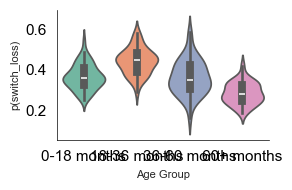

In [115]:
from scipy import stats
import pandas as pd
import numpy as np

# 1. First, check if switch rate differs across age groups (omnibus test)
# Kruskal-Wallis test (non-parametric version of ANOVA)
age_groups = summary_df_filtered['Age_Group'].unique()
groups_data = [summary_df_filtered[summary_df_filtered['Age_Group'] == group]['lose_switch_rate_prev0'].dropna() 
               for group in age_groups]

# Remove empty groups
groups_data = [g for g in groups_data if len(g) > 0]

# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(*groups_data)
print("="*60)
print("OMNIBUS TEST: Do age groups differ in switch rate?")
print("="*60)
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✓ Significant difference detected across age groups!")
else:
    print("✗ No significant difference across age groups")
print()

# 2. Post-hoc pairwise comparisons (if omnibus test is significant)
if p_value < 0.05:
    print("="*60)
    print("POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U tests)")
    print("="*60)
    
    from itertools import combinations
    
    # Get all unique pairs
    age_groups_list = sorted(summary_df_filtered['Age_Group'].dropna().unique())
    pairs = list(combinations(age_groups_list, 2))
    
    # Store results
    pairwise_results = []
    
    for group1, group2 in pairs:
        data1 = summary_df_filtered[summary_df_filtered['Age_Group'] == group1]['lose_switch_rate_prev0'].dropna()
        data2 = summary_df_filtered[summary_df_filtered['Age_Group'] == group2]['lose_switch_rate_prev0'].dropna()
        
        if len(data1) > 0 and len(data2) > 0:
            u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            
            # Bonferroni correction
            n_comparisons = len(pairs)
            p_val_corrected = p_val * n_comparisons
            p_val_corrected = min(p_val_corrected, 1.0)  # Cap at 1.0
            
            mean1 = data1.mean()
            mean2 = data2.mean()
            
            pairwise_results.append({
                'Group1': group1,
                'Group2': group2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Difference': mean1 - mean2,
                'U-statistic': u_stat,
                'p-value': p_val,
                'p-value (Bonferroni)': p_val_corrected,
                'Significant': '***' if p_val_corrected < 0.001 else '**' if p_val_corrected < 0.01 else '*' if p_val_corrected < 0.05 else 'ns'
            })
    
    pairwise_df = pd.DataFrame(pairwise_results).sort_values('p-value')
    print(pairwise_df.to_string(index=False))
    print("\n* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant")
    print(f"Bonferroni correction applied (n={n_comparisons} comparisons)")

# 3. Descriptive statistics by age group
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS BY AGE GROUP")
print("="*60)
desc_stats = summary_df_filtered.groupby('Age_Group')['lose_switch_rate_prev0'].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max')
]).round(4)
print(desc_stats)

# 4. Effect size (if significant)
if p_value < 0.05:
    print("\n" + "="*60)
    print("EFFECT SIZE (Epsilon-squared for Kruskal-Wallis)")
    print("="*60)
    n = len(summary_df_filtered['lose_switch_rate_prev0'].dropna())
    k = len(age_groups_list)
    epsilon_squared = (h_stat - k + 1) / (n - k)
    print(f"Epsilon-squared: {epsilon_squared:.4f}")
    print("Interpretation: < 0.01 = small, 0.01-0.08 = medium, > 0.08 = large")

# 5. Visualization with significance bars
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(3, 2))
sns.reset_defaults()
plt.rcdefaults()
sns.violinplot(data=summary_df_filtered, x='Age_Group', y='lose_switch_rate_prev0', 
               ax=ax, inner='box', palette='Set2')
# sns.stripplot(data=summary_df_filtered, x='Age_Group', y='lose_switch_rate_prev0',
#               ax=ax, color='black', alpha=0.3, size=3)

# ax.set_title(f'Switch Rate by Age Group\nKruskal-Wallis: H={h_stat:.2f}, p={p_value:.4f}', 
            #  fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=8)
ax.set_ylabel('p(switch_loss)', fontsize=8)
ax.grid(False)
ax.tick_params(which='both', direction='out', length=4, width=1)
sns.set_style("ticks")

# Explicitly ensure tick marks are visible
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.tight_layout()
sns.despine()
save_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/forVictoria/job_app_figures'
# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save the figure with a filename
filename = 'switch_rate_by_age.svg'  # or .pdf, .svg, etc.
full_path = os.path.join(save_path, filename)
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(full_path, dpi=300, bbox_inches='tight')
plt.show()

OMNIBUS TEST: Do age groups differ in switch rate?
Kruskal-Wallis H-statistic: 30.4290
P-value: 0.0000
✓ Significant difference detected across age groups!

POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U tests)
      Group1       Group2    Mean1    Mean2  Difference  U-statistic      p-value  p-value (Bonferroni) Significant
18-36 months   60+ months 0.263055 0.197712    0.065343       1280.0 1.379326e-07          8.275956e-07         ***
 0-18 months   60+ months 0.233511 0.197712    0.035799       1349.5 1.867575e-04          1.120545e-03          **
 0-18 months 18-36 months 0.233511 0.263055   -0.029544        881.0 2.776977e-03          1.666186e-02           *
18-36 months 36-60 months 0.263055 0.225417    0.037638       1433.5 6.833323e-03          4.099994e-02           *
36-60 months   60+ months 0.225417 0.197712    0.027705        982.5 1.245493e-02          7.472960e-02          ns
 0-18 months 36-60 months 0.233511 0.225417    0.008094       1341.0 8.448477e-01          1.0

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/371101747.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = summary_df_filtered.groupby('Age_Group')['switch_rate'].agg([
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/371101747.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary_df_filtered, x='Age_Group', y='switch_rate',


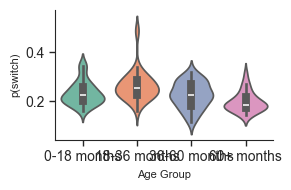

In [116]:
from scipy import stats
import pandas as pd
import numpy as np

# 1. First, check if switch rate differs across age groups (omnibus test)
# Kruskal-Wallis test (non-parametric version of ANOVA)
age_groups = summary_df_filtered['Age_Group'].unique()
groups_data = [summary_df_filtered[summary_df_filtered['Age_Group'] == group]['switch_rate'].dropna() 
               for group in age_groups]

# Remove empty groups
groups_data = [g for g in groups_data if len(g) > 0]

# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(*groups_data)
print("="*60)
print("OMNIBUS TEST: Do age groups differ in switch rate?")
print("="*60)
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✓ Significant difference detected across age groups!")
else:
    print("✗ No significant difference across age groups")
print()

# 2. Post-hoc pairwise comparisons (if omnibus test is significant)
if p_value < 0.05:
    print("="*60)
    print("POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U tests)")
    print("="*60)
    
    from itertools import combinations
    
    # Get all unique pairs
    age_groups_list = sorted(summary_df_filtered['Age_Group'].dropna().unique())
    pairs = list(combinations(age_groups_list, 2))
    
    # Store results
    pairwise_results = []
    
    for group1, group2 in pairs:
        data1 = summary_df_filtered[summary_df_filtered['Age_Group'] == group1]['switch_rate'].dropna()
        data2 = summary_df_filtered[summary_df_filtered['Age_Group'] == group2]['switch_rate'].dropna()
        
        if len(data1) > 0 and len(data2) > 0:
            u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            
            # Bonferroni correction
            n_comparisons = len(pairs)
            p_val_corrected = p_val * n_comparisons
            p_val_corrected = min(p_val_corrected, 1.0)  # Cap at 1.0
            
            mean1 = data1.mean()
            mean2 = data2.mean()
            
            pairwise_results.append({
                'Group1': group1,
                'Group2': group2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Difference': mean1 - mean2,
                'U-statistic': u_stat,
                'p-value': p_val,
                'p-value (Bonferroni)': p_val_corrected,
                'Significant': '***' if p_val_corrected < 0.001 else '**' if p_val_corrected < 0.01 else '*' if p_val_corrected < 0.05 else 'ns'
            })
    
    pairwise_df = pd.DataFrame(pairwise_results).sort_values('p-value')
    print(pairwise_df.to_string(index=False))
    print("\n* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant")
    print(f"Bonferroni correction applied (n={n_comparisons} comparisons)")

# 3. Descriptive statistics by age group
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS BY AGE GROUP")
print("="*60)
desc_stats = summary_df_filtered.groupby('Age_Group')['switch_rate'].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max')
]).round(4)
print(desc_stats)

# 4. Effect size (if significant)
if p_value < 0.05:
    print("\n" + "="*60)
    print("EFFECT SIZE (Epsilon-squared for Kruskal-Wallis)")
    print("="*60)
    n = len(summary_df_filtered['switch_rate'].dropna())
    k = len(age_groups_list)
    epsilon_squared = (h_stat - k + 1) / (n - k)
    print(f"Epsilon-squared: {epsilon_squared:.4f}")
    print("Interpretation: < 0.01 = small, 0.01-0.08 = medium, > 0.08 = large")

# 5. Visualization with significance bars
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(3, 2))
sns.reset_defaults()
plt.rcdefaults()
sns.violinplot(data=summary_df_filtered, x='Age_Group', y='switch_rate', 
               ax=ax, inner='box', palette='Set2')
# sns.stripplot(data=summary_df_filtered, x='Age_Group', y='lose_switch_rate_prev0',
#               ax=ax, color='black', alpha=0.3, size=3)

# ax.set_title(f'Switch Rate by Age Group\nKruskal-Wallis: H={h_stat:.2f}, p={p_value:.4f}', 
            #  fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=8)
ax.set_ylabel('p(switch)', fontsize=8)
ax.grid(False)
ax.tick_params(which='both', direction='out', length=4, width=1)
sns.set_style("ticks")

# Explicitly ensure tick marks are visible
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.tight_layout()
sns.despine()
save_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/forVictoria/job_app_figures'
# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save the figure with a filename
filename = 'switch_rate_by_age.svg'  # or .pdf, .svg, etc.
full_path = os.path.join(save_path, filename)
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(full_path, dpi=300, bbox_inches='tight')
plt.show()

OMNIBUS TEST: Do age groups differ in accuracy?
Kruskal-Wallis H-statistic: 65.2050
P-value: 0.0000
✓ Significant difference detected across age groups!

POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U tests)
      Group1       Group2      Mean1      Mean2  Difference  U-statistic      p-value  p-value (Bonferroni) Significant
 0-18 months 18-36 months 272.771930 170.744681  102.027249       2422.5 1.539130e-12          9.234778e-12         ***
 0-18 months 36-60 months 272.771930 171.782609  100.989321       2276.0 1.563947e-10          9.383685e-10         ***
 0-18 months   60+ months 272.771930 180.593750   92.178180       1516.0 2.462084e-07          1.477250e-06         ***
18-36 months   60+ months 170.744681 180.593750   -9.849069        706.5 6.531245e-01          1.000000e+00          ns
36-60 months   60+ months 171.782609 180.593750   -8.811141        693.0 6.659139e-01          1.000000e+00          ns
18-36 months 36-60 months 170.744681 171.782609   -1.037928       1063.5 

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/2894699906.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = summary_df_filtered.groupby('Age_Group')[feature_of_interest].agg([
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_68876/2894699906.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feature_of_interest,


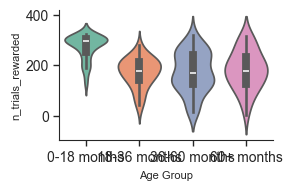

In [154]:
from scipy import stats
import pandas as pd
import numpy as np

feature_of_interest = 'n_trials_rewarded'
# 1. First, check if switch rate differs across age groups (omnibus test)
# Kruskal-Wallis test (non-parametric version of ANOVA)
age_groups = summary_df_filtered['Age_Group'].unique()
groups_data = [summary_df_filtered[summary_df_filtered['Age_Group'] == group][feature_of_interest].dropna() 
               for group in age_groups]

# Remove empty groups
groups_data = [g for g in groups_data if len(g) > 0]

# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(*groups_data)
print("="*60)
print("OMNIBUS TEST: Do age groups differ in accuracy?")
print("="*60)
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✓ Significant difference detected across age groups!")
else:
    print("✗ No significant difference across age groups")
print()

# 2. Post-hoc pairwise comparisons (if omnibus test is significant)
if p_value < 0.05:
    print("="*60)
    print("POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U tests)")
    print("="*60)
    
    from itertools import combinations
    
    # Get all unique pairs
    age_groups_list = sorted(summary_df_filtered['Age_Group'].dropna().unique())
    pairs = list(combinations(age_groups_list, 2))
    
    # Store results
    pairwise_results = []
    
    for group1, group2 in pairs:
        data1 = summary_df_filtered[summary_df_filtered['Age_Group'] == group1][feature_of_interest].dropna()
        data2 = summary_df_filtered[summary_df_filtered['Age_Group'] == group2][feature_of_interest].dropna()

        if len(data1) > 0 and len(data2) > 0:
            u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            
            # Bonferroni correction
            n_comparisons = len(pairs)
            p_val_corrected = p_val * n_comparisons
            p_val_corrected = min(p_val_corrected, 1.0)  # Cap at 1.0
            
            mean1 = data1.mean()
            mean2 = data2.mean()
            
            pairwise_results.append({
                'Group1': group1,
                'Group2': group2,
                'Mean1': mean1,
                'Mean2': mean2,
                'Difference': mean1 - mean2,
                'U-statistic': u_stat,
                'p-value': p_val,
                'p-value (Bonferroni)': p_val_corrected,
                'Significant': '***' if p_val_corrected < 0.001 else '**' if p_val_corrected < 0.01 else '*' if p_val_corrected < 0.05 else 'ns'
            })
    
    pairwise_df = pd.DataFrame(pairwise_results).sort_values('p-value')
    print(pairwise_df.to_string(index=False))
    print("\n* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant")
    print(f"Bonferroni correction applied (n={n_comparisons} comparisons)")

# 3. Descriptive statistics by age group
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS BY AGE GROUP")
print("="*60)
desc_stats = summary_df_filtered.groupby('Age_Group')[feature_of_interest].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max')
]).round(4)
print(desc_stats)

# 4. Effect size (if significant)
if p_value < 0.05:
    print("\n" + "="*60)
    print("EFFECT SIZE (Epsilon-squared for Kruskal-Wallis)")
    print("="*60)
    n = len(summary_df_filtered['accuracy'].dropna())
    k = len(age_groups_list)
    epsilon_squared = (h_stat - k + 1) / (n - k)
    print(f"Epsilon-squared: {epsilon_squared:.4f}")
    print("Interpretation: < 0.01 = small, 0.01-0.08 = medium, > 0.08 = large")

# 5. Visualization with significance bars
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(3, 2))
sns.reset_defaults()
plt.rcdefaults()
sns.violinplot(data=summary_df_filtered, x='Age_Group', y=feature_of_interest, 
               ax=ax, inner='box', palette='Set2')
# sns.stripplot(data=summary_df_filtered, x='Age_Group', y='lose_switch_rate_prev0',
#               ax=ax, color='black', alpha=0.3, size=3)

# ax.set_title(f'Switch Rate by Age Group\nKruskal-Wallis: H={h_stat:.2f}, p={p_value:.4f}', 
            #  fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=8)
ax.set_ylabel(feature_of_interest, fontsize=8)
ax.grid(False)
ax.tick_params(which='both', direction='out', length=4, width=1)
sns.set_style("ticks")

# Explicitly ensure tick marks are visible
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.tight_layout()
sns.despine()
save_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/forVictoria/job_app_figures'
# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save the figure with a filename
filename = f'{feature_of_interest}_by_age.svg'  # or .pdf, .svg, etc.
full_path = os.path.join(save_path, filename)
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(full_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Function to create a new DataFrame based on Task_Type and prob_Condition
def filter_data_by_task_and_prob(task_type, prob_condition):
    # Filter the rows based on the Task_Type and prob_Condition
    filtered_df = df[(df['Task_Type'] == task_type) & (df['prob_Condition'] == prob_condition)]
    
    # Return the filtered DataFrame
    return filtered_df

# Example usage:
# Ask for user input for Task_Type and prob_Condition
task_type_input = input("Enter the Task_Type (e.g., 'Reversal', 'WhereTask', 'What Task'): ")
prob_condition_input = input("Enter the prob_Condition (e.g., '80-20'): ")

# Create the new filtered DataFrame
new_filtered_df = filter_data_by_task_and_prob(task_type_input, prob_condition_input)

# Display the new DataFrame or perform further analysis
print(f"Filtered DataFrame for Task_Type = {task_type_input} and prob_Condition = {prob_condition_input}:")
print(new_filtered_df)

Filtered DataFrame for Task_Type = Reversal and prob_Condition = 80-20:
        Trial  BlockCount  TrialWithinBlock  Block  Condition  TrialError  \
4702        1           1                 1      5          5           6   
4703        2           1                 2      5          5           0   
4704        3           1                 3      5          5           0   
4705        4           1                 4      5          5           6   
4706        5           1                 5      5          5           0   
...       ...         ...               ...    ...        ...         ...   
308604    337          17                17      1          1           0   
308605    338          17                18      1          1           0   
308606    339          17                19      1          1           0   
308607    340          17                20      1          1           0   
308608    341          18                 1      2          2           0   

   

In [ ]:
new_filtered_df

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,Session_ID_Trial,prob_Condition,Switch,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,Task_Type,filename
4702,1,1,1,5,5,6,NaN,0.000000e+00,2022,4,...,2022-04-25_Fiona_1,80-20,NaN,0.0,1,0.000000,0.000000,NaN,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan
4703,2,1,2,5,5,0,NaN,1.360519e+05,2022,4,...,2022-04-25_Fiona_2,80-20,1.0,1.0,1,136.051937,2.267532,136.051937,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan
4704,3,1,3,5,5,0,NaN,1.431673e+05,2022,4,...,2022-04-25_Fiona_3,80-20,0.0,1.0,1,143.167328,2.386122,7.115391,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan
4705,4,1,4,5,5,6,NaN,1.549159e+05,2022,4,...,2022-04-25_Fiona_4,80-20,1.0,0.0,1,154.915893,2.581932,11.748565,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan
4706,5,1,5,5,5,0,NaN,1.627993e+05,2022,4,...,2022-04-25_Fiona_5,80-20,1.0,1.0,1,162.799264,2.713321,7.883370,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308604,337,17,17,1,1,0,NaN,3.686018e+06,2023,11,...,2023-11-13_Sunflower_337,80-20,0.0,1.0,1,3686.018455,61.433641,2.766322,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...
308605,338,17,18,1,1,0,NaN,3.692084e+06,2023,11,...,2023-11-13_Sunflower_338,80-20,0.0,1.0,1,3692.084432,61.534741,6.065978,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...
308606,339,17,19,1,1,0,NaN,3.696984e+06,2023,11,...,2023-11-13_Sunflower_339,80-20,0.0,1.0,1,3696.983879,61.616398,4.899447,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...
308607,340,17,20,1,1,0,NaN,3.702433e+06,2023,11,...,2023-11-13_Sunflower_340,80-20,0.0,1.0,1,3702.433299,61.707222,5.449420,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...


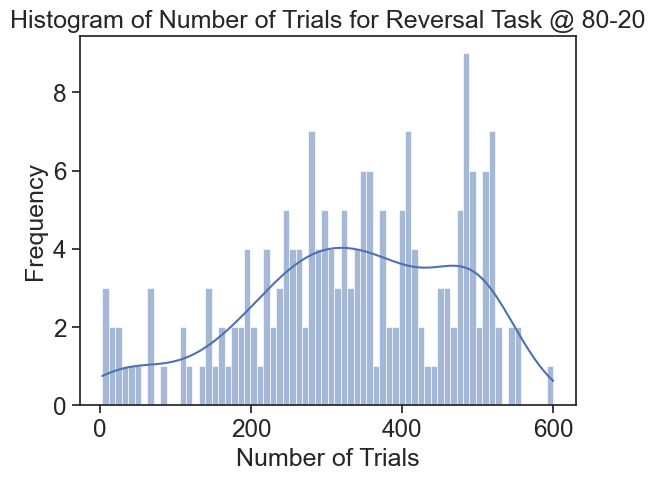

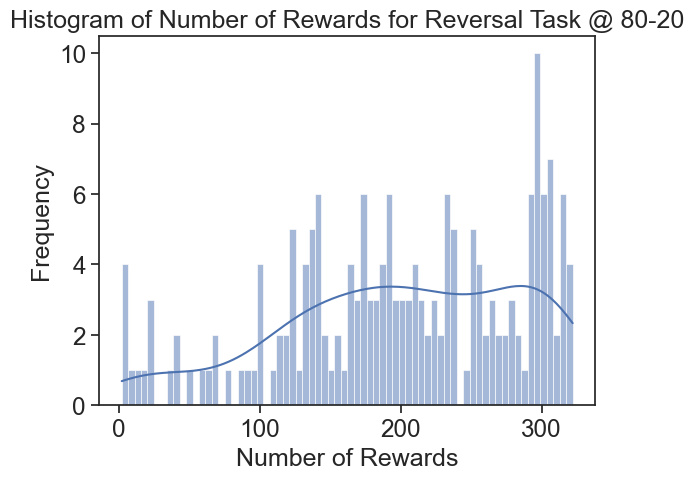

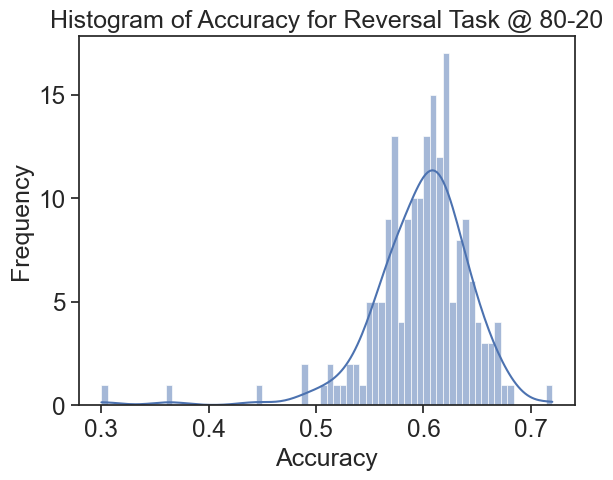

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Iterate through each Session_ID and store the total number of trials in a dictionary
trial_numbers = {}
for session_id in new_filtered_df['Session_ID'].unique():
    # Filter the DataFrame for the current Session_ID
    session_df = new_filtered_df[new_filtered_df['Session_ID'] == session_id]
    
    # Calculate the total number of trials for the current Session_ID
    total_trials = len(session_df)
    
    # Store the total number of trials in the dictionary
    trial_numbers[session_id] = total_trials

# Plotting the histogram with a KDE using seaborn
sns.histplot(list(trial_numbers.values()), bins=70, kde=True)

# Add labels and title
plt.xlabel('Number of Trials')
plt.ylabel('Frequency')
plt.title(f'Histogram of Number of Trials for {task_type_input} Task @ {prob_condition_input}')

# Show the plot
plt.show()

# Iterate through each Session_ID and store the total number of rewards in a dictionary
rewards_numbers = {}
for session_id in new_filtered_df['Session_ID'].unique():
    # Filter the DataFrame for the current Session_ID
    session_df = new_filtered_df[new_filtered_df['Session_ID'] == session_id]
    
    # Calculate the total number of rewards (where 'Reward' == 1) for the current Session_ID
    total_rewards = (session_df['Reward'] == 'Rewarded').sum()  # Sum of True values where 'Reward' == 1
    
    # Store the total number of rewards in the dictionary
    rewards_numbers[session_id] = total_rewards

# Plotting the histogram with a KDE using seaborn
sns.histplot(list(rewards_numbers.values()), bins=70, kde=True)

# Add labels and title
plt.xlabel('Number of Rewards')
plt.ylabel('Frequency')
plt.title(f'Histogram of Number of Rewards for {task_type_input} Task @ {prob_condition_input}')

# Show the plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Iterate through each Session_ID and store the accuracy in a dictionary
accuracy_numbers = {}
for session_id in new_filtered_df['Session_ID'].unique():
    # Filter the DataFrame for the current Session_ID
    session_df = new_filtered_df[new_filtered_df['Session_ID'] == session_id]
    
    # Calculate the accuracy for the current Session_ID
    total_trials = len(session_df)
    total_rewards = (session_df['Reward'] == 'Rewarded').sum()
    
    # Calculate accuracy as the proportion of rewarded trials
    accuracy = total_rewards / total_trials if total_trials > 0 else 0  # Avoid division by zero
    
    # Store the accuracy in the dictionary
    accuracy_numbers[session_id] = accuracy

# Plotting the histogram with a KDE using seaborn
sns.histplot(list(accuracy_numbers.values()), bins=70, kde=True)

# Add labels and title
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title(f'Histogram of Accuracy for {task_type_input} Task @ {prob_condition_input}')

# Show the plot
plt.show()




In [ ]:
len(new_filtered_df['Session_ID'].unique())


# Filter new_filtered_df to include only rows where 'SetChanges" is found  the columsns that start with Filename in each row
# Get the columns that start with 'Filename'
filename_columns = new_filtered_df.columns[new_filtered_df.columns.str.startswith('Filename')]
# Create a mask for rows where any of the filename columns contain 'SetChanges'
mask = new_filtered_df[filename_columns].apply(lambda x: x.str.contains('SetChanges', na=False)).any(axis=1)
# Filter the DataFrame using the mask
filtered_df = new_filtered_df[mask]
# Display the filtered DataFrame
print(len(filtered_df))

0


In [ ]:
# number of unique sessions for each Animal_Name
animal_sessions = new_filtered_df.groupby('Animal_Name')['Session_ID'].nunique()
animal_sessions

# #print the filename of each session
# for session in new_filtered_df['Session_ID'].unique():
#     print(session)

Animal_Name
Fiona        22
Knuckles     36
Sonic        21
Sunflower    48
Zazu         60
Name: Session_ID, dtype: int64

In [ ]:
new_filtered_df['treatment'] = 'Marmoset'

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_88107/209290459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_filtered_df['treatment'] = 'Marmoset'


In [ ]:
#this solves the issue of having multiple events happening per condition (per mouse). 

def bpos_summaries_by_condition(data, condition='Animal_Name', treatments=['Marmoset']):# 'young_2', 'mid']):

    condition_labels = data[condition].unique()

    bpos = pd.DataFrame()
    for c in condition_labels:
        
        d_ = data.loc[data[condition]==c]

        for treatment in treatments:
            if treatment in d_.treatment.unique():
                bpos_tmp = plots.get_block_position_summaries(d_.loc[d_.treatment==treatment])

                bpos_tmp['condition'] = c
                bpos_tmp['treatment'] = treatment

                bpos = pd.concat((bpos, bpos_tmp), ignore_index=True)  

    return bpos

In [ ]:
def exponential_fixedB(x, a, k):
    # fit exponential that's constrained to recover to baseline (mean pHigh of 10 trials preceding block transition)
    return a*np.exp(x*k) + d.phigh.values[10:20].mean()

def double_exp(x, a1, k1, a2, k2):
    return a1 * np.exp(x*k1) + a2 * np.exp(x*k2) + d.phigh.values[10:20].mean()



In [ ]:
data = new_filtered_df.copy()
data.columns.unique()
data=data.rename(columns={'TrialWithinBlock':'blockTrial', 'BlockLength':'blockLength', 'Decision':'highPort'})

# 
# # data=data.rename(columns={'Block Trial':'blockTrial', 'BlockLength':'blockLength', 'TargetPort':'Target', 'Higher p port':'highPort', 'Mouse ID_x': 'Mouse ID'})

mice = data['Animal_Name'].unique()
treat_type = data['treatment'].unique()
data['block_pos_rev'] = data['blockTrial'] - data['blockLength'] # reverse block position from transition
print(len(data))
# filter out sessions with fewer than 20 trials
for session in data['Session_ID'].unique():
    if len(data.loc[data['Session_ID']==session]) < 20:
        data = data.loc[data['Session_ID']!=session]
print(len(data))

df_aggregate = plots.get_block_position_summaries(data)
df = bpos_summaries_by_condition(data, treatments=['Marmoset'])

62054
62013


In [ ]:
df

,block_pos,phigh,phigh_std,pswitch,pswitch_std,n,condition,treatment
0,-19.0,0.273256,0.446280,0.849231,0.358376,325,Fiona,Marmoset
1,-18.0,0.326531,0.469629,0.204082,0.403618,343,Fiona,Marmoset
2,-17.0,0.494152,0.500698,0.225146,0.418291,342,Fiona,Marmoset
3,-16.0,0.633431,0.482575,0.237537,0.426199,341,Fiona,Marmoset
4,-15.0,0.659824,0.474464,0.149560,0.357164,341,Fiona,Marmoset
...,...,...,...,...,...,...,...,...
190,16.0,0.732006,0.443254,0.228178,0.419979,653,Sunflower,Marmoset
191,17.0,0.738059,0.440030,0.203390,0.402831,649,Sunflower,Marmoset
192,18.0,0.757342,0.429022,0.214838,0.411027,647,Sunflower,Marmoset
193,19.0,0.740683,0.438600,0.201863,0.401703,644,Sunflower,Marmoset


MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan


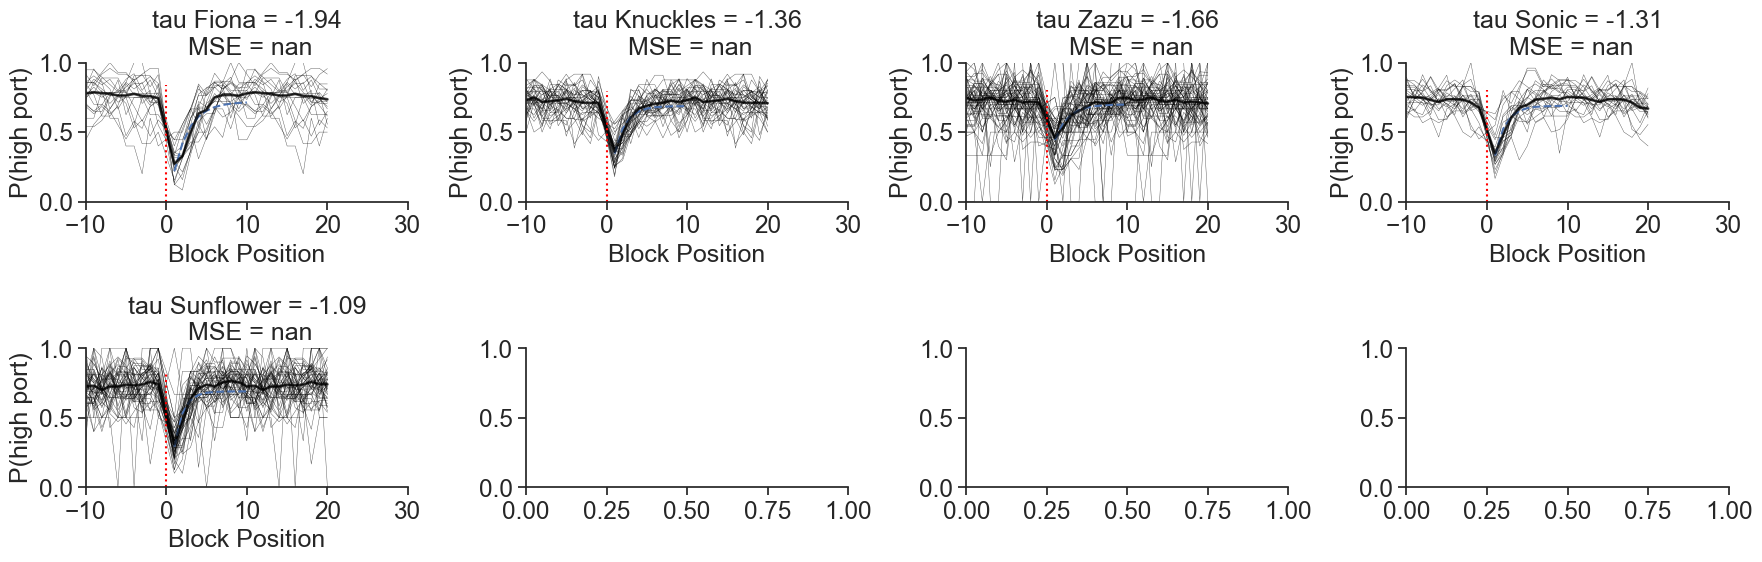

In [ ]:
import scipy 
from sklearn.metrics import mean_squared_error as mse



mice = data['Animal_Name'].unique()

ID, tau_phigh=[], []

fig, axs = plt.subplots(nrows=int(np.ceil(len(mice)/4)), ncols=4, figsize=(6*3, 3*int(np.ceil(len(mice)/4))))
plt.yticks([0,0.5,1.0])
sns.despine() 

for ax, mouse in zip(axs.reshape(-1), mice): 
    
    d = df[df.condition == mouse]        
    ID.append(mouse)
    d_to_fit = d.loc[(d.block_pos>=0) & (d.block_pos<=10)] # change here to adjust plateau of fit
    popt, pcov = scipy.optimize.curve_fit(exponential_fixedB, d_to_fit.block_pos.values, d_to_fit.phigh.values, p0=[0,-0.5])
    #popt, pcov = scipy.optimize.curve_fit(exponential_fixedB, d.block_pos.values[20:], d.phigh.values[20:], p0=[0,-0.5])

    tau_phigh.append(1/popt[1])

    session_traces = bpos_summaries_by_condition(data.loc[data['Animal_Name']==mouse], condition='Session_ID')

    for session in session_traces.condition.unique():
        
        s = session_traces.loc[session_traces.condition==session]
        ax.plot(s.block_pos,s.phigh,'-',label =None,alpha=0.7,linewidth=0.3, color='black')

    tau_phigh.append(1/popt[1])
    
    ax.plot(d.block_pos,d.phigh,'-',label =mouse,alpha=0.7,linewidth=0.8, color='black')
    ax.plot(d_to_fit.block_pos.values, exponential_fixedB(d_to_fit.block_pos.values, popt[0], popt[1]), linestyle='dashed')

    ax.plot(d.block_pos,d.phigh,'-',label =mouse,alpha=0.7,linewidth=2, color='black')
    ax.vlines(x=0,ymin=0,ymax=max(d.phigh)+0.05,linestyle='dotted', color='red')
    # Check if the lengths of the arrays are valid and non-empty
    phigh_values = d['phigh'].values[40:]
    fitted_values = exponential_fixedB(d['block_pos'].values[40:], popt[0], popt[1])

    # Ensure neither array is empty
    if len(phigh_values) > 0 and len(fitted_values) > 0:
        # Check if the lengths match
        if len(phigh_values) == len(fitted_values):
            MSE = mse(phigh_values, fitted_values)  # Calculate the MSE if lengths match
        else:
            # If lengths don't match, trim one of the arrays to match lengths
            # Example trimming the 'fitted_values'
            MSE = mse(phigh_values, fitted_values[:len(phigh_values)])
    else:
        MSE = float('nan')  # If either array is empty, assign NaN to MSE

    print(f"MSE: {MSE}")

    ax.set(xlabel='Block Position', ylabel='P(high port)', xlim=(-10,30), ylim=(0,1), title=f'tau {mouse} = {round(1/popt[1], 2)}\n MSE = {round(MSE, 3)}')

    plt.tight_layout()

In [ ]:
def average_plot(data, stat, individual_traces=True, unit_type='Animal_Name'):

    data=data.rename(columns={'Block Trial':'blockTrial', 'Current Block Length':'blockLength',\
                                'TargetPort':'Target'})

    treat_type = data['treatment'].unique()

    sns.set_style('white')
    sns.set_style('ticks')
    fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(9,4))
    
    colors = ['blue', 'orange']#, 'magenta', 'blue'] #['magenta', 'f0c0ac']#,'blue']#, 'red']


    #array(['old', 'old_2', 'young', 'young_2', 'mid'], dtype=object)

    for data_treat_type, color in zip(treat_type, colors):
        temp_df = data[data['treatment']==data_treat_type]
        df=bpos_summaries_by_condition(temp_df, condition=unit_type)
        units = temp_df[unit_type].unique()

        d_avg = df[['block_pos', stat]].groupby('block_pos', as_index=False).mean()
        ax1.plot(d_avg.block_pos, d_avg[stat], '-', label=data_treat_type, alpha=1, linewidth=2, color=color)

        if individual_traces: # option to include single traces
            for i, unit in enumerate(units):
                d = df[df.condition == unit]
                ax1.plot(d.block_pos,d[stat],'-',label ='_nolegend_',alpha=0.3,linewidth=1, color=color)

        else:
            sem = (df[['block_pos', stat]].groupby('block_pos')[stat].std().values / 
                            np.sqrt(df[['block_pos', stat]].groupby('block_pos')[stat].size().values))

            plt.fill_between(d_avg.block_pos.values, y1 = d_avg[stat] - sem, y2 =d_avg[stat] + sem, alpha=0.2, color=color)
            
        
    
    # format plot
    ymax1=max(df[stat])+0.05
    ax1.axis('on')
    ax1.vlines(x=0,ymin=0,ymax=ymax1,linestyle='dotted', color='black')
    ax1.legend(loc=[.65,0.03], fontsize=17.7,frameon=True) #0.45 0.03
    ax1.set(xlabel='Block Position', ylabel=stat, xlim=(-10,20), ylim=(0,ymax1))
    sns.despine()

    #return average_plot_summary
    return df.sort_values(['condition', 'block_pos'])


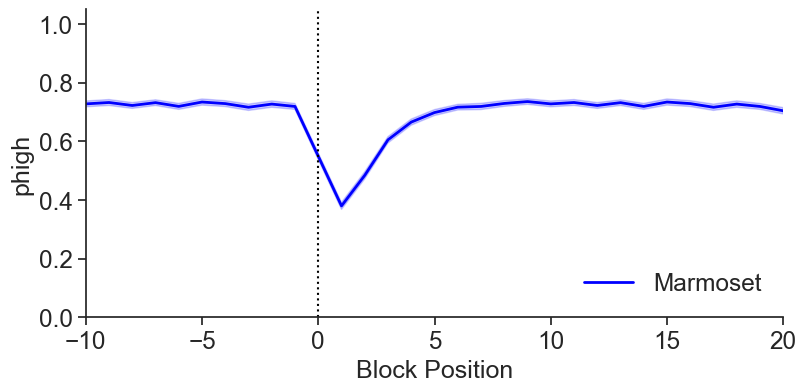

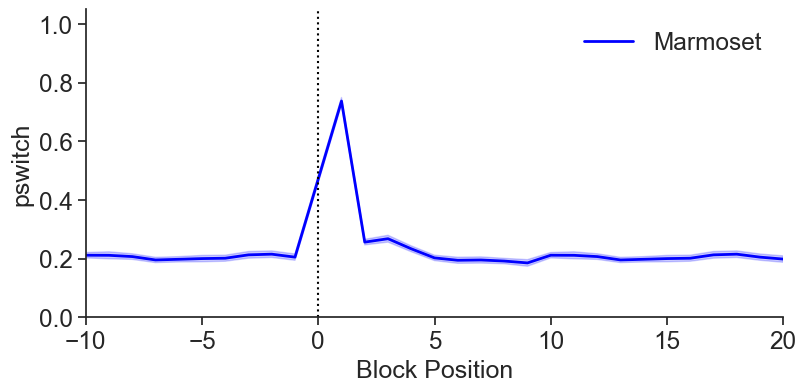

In [ ]:
# Plot and save the second plot with the updated dynamic name
average_plot(data, 'phigh', individual_traces=False, unit_type='Session_ID')
# plt.ylim(0.25, 0.80)
# plt.xlim(2, 15)
# plt.ylim(0.05, 0.35)
# plt.xlim(2, 15)
plt.legend(loc='lower right', frameon=False)

# plt.savefig(f'average_plot_{task_type_input}_{prob_condition_input}.png', dpi=300, bbox_inches='tight')

average_plot(data, 'pswitch', individual_traces=False, unit_type='Session_ID')
# plt.ylim(0.25, 0.80)
# plt.xlim(2, 15)
# plt.ylim(0.05, 0.45)
# plt.xlim(2, 15)
plt.legend(loc='upper right', frameon=False)

In [ ]:
data.columns.unique()



Index(['Trial', 'BlockCount', 'blockTrial', 'Block', 'Condition', 'TrialError',
       'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month', 'Day',
       'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'blockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Color_2',

In [ ]:
# Iterate through each unique 'Session_ID', print the unique 'Block's that are present
for session_id in new_filtered_df['Session_ID'].unique():
    # Filter the DataFrame for the current Session_ID
    session_df = new_filtered_df[new_filtered_df['Session_ID'] == session_id]
    
    # Get the unique 'Block's for the current Session_ID
    unique_blocks = session_df['Block'].unique()

    # Check for the number of BlockCounts in the current Session_ID
    block_counts = session_df['Block'].value_counts()
    
    # Print the Session_ID and its unique Blocks
    # print(f"Session ID: {session_id}, Unique Blocks: {unique_blocks}, Block Counts: {block_counts}")


# subset the dataframe to only include sessions WHERE THE LENGTH OF UNIQUE BLOCKS IS LESS THAN OR EQUAL TO 2


# Filter the DataFrame to include only sessions with 2 or fewer unique blocks
filtered_sessions = []
for session_id in new_filtered_df['Session_ID'].unique():
    # Filter the DataFrame for the current Session_ID
    session_df = new_filtered_df[new_filtered_df['Session_ID'] == session_id]
    
    # Get the unique 'Block's for the current Session_ID
    unique_blocks = session_df['Block'].unique()
    
    # Check if the number of unique blocks is less than or equal to 2
    if len(unique_blocks) == 2:
        filtered_sessions.append(session_id)
# Create a new DataFrame with only the filtered sessions
subset_df = new_filtered_df[new_filtered_df['Session_ID'].isin(filtered_sessions)]



In [ ]:
subset_df

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,prob_Condition,Switch,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,Task_Type,filename,treatment
4702,1,1,1,5,5,6,NaN,0.000000e+00,2022,4,...,80-20,NaN,0.0,1,0.000000,0.000000,NaN,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,Marmoset
4703,2,1,2,5,5,0,NaN,1.360519e+05,2022,4,...,80-20,1.0,1.0,1,136.051937,2.267532,136.051937,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,Marmoset
4704,3,1,3,5,5,0,NaN,1.431673e+05,2022,4,...,80-20,0.0,1.0,1,143.167328,2.386122,7.115391,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,Marmoset
4705,4,1,4,5,5,6,NaN,1.549159e+05,2022,4,...,80-20,1.0,0.0,1,154.915893,2.581932,11.748565,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,Marmoset
4706,5,1,5,5,5,0,NaN,1.627993e+05,2022,4,...,80-20,1.0,1.0,1,162.799264,2.713321,7.883370,Reversal,20220425 Fiona Reversal3.1.csv nan nan nan nan,Marmoset
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308604,337,17,17,1,1,0,NaN,3.686018e+06,2023,11,...,80-20,0.0,1.0,1,3686.018455,61.433641,2.766322,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,Marmoset
308605,338,17,18,1,1,0,NaN,3.692084e+06,2023,11,...,80-20,0.0,1.0,1,3692.084432,61.534741,6.065978,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,Marmoset
308606,339,17,19,1,1,0,NaN,3.696984e+06,2023,11,...,80-20,0.0,1.0,1,3696.983879,61.616398,4.899447,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,Marmoset
308607,340,17,20,1,1,0,NaN,3.702433e+06,2023,11,...,80-20,0.0,1.0,1,3702.433299,61.707222,5.449420,Reversal,231113 Sunflower VDT NoInitiation 100.0 Confli...,Marmoset


(5000.0, 7000.0)

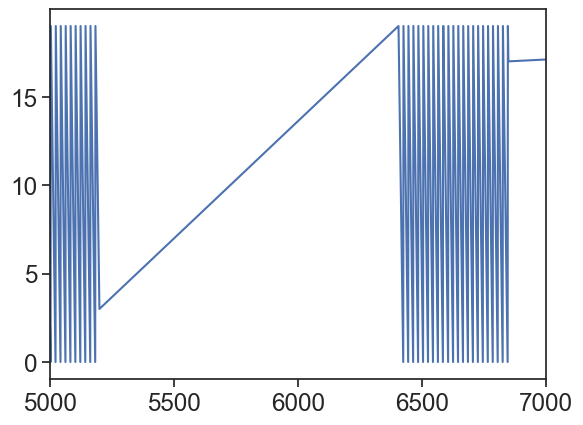

In [ ]:
plt.plot(subset_df['block_pos_rev'])


In [ ]:
subset_df['blockTrial'].min()

np.int64(1)

36087


,block_pos,phigh,phigh_std,pswitch,pswitch_std,n,condition,treatment
0,-20.0,0.253731,0.435960,0.877953,0.327987,254,Fiona,Marmoset
1,-19.0,0.299625,0.458954,0.217228,0.413134,267,Fiona,Marmoset
2,-18.0,0.468165,0.499923,0.228464,0.420632,267,Fiona,Marmoset
3,-17.0,0.620301,0.486227,0.248120,0.432736,266,Fiona,Marmoset
4,-16.0,0.654135,0.476546,0.146617,0.354390,266,Fiona,Marmoset
...,...,...,...,...,...,...,...,...
115,15.0,0.725000,0.447916,0.193750,0.396476,160,Zazu,Marmoset
116,16.0,0.700000,0.459696,0.150000,0.358193,160,Zazu,Marmoset
117,17.0,0.687500,0.464968,0.175000,0.381160,160,Zazu,Marmoset
118,18.0,0.672956,0.470616,0.157233,0.365170,159,Zazu,Marmoset


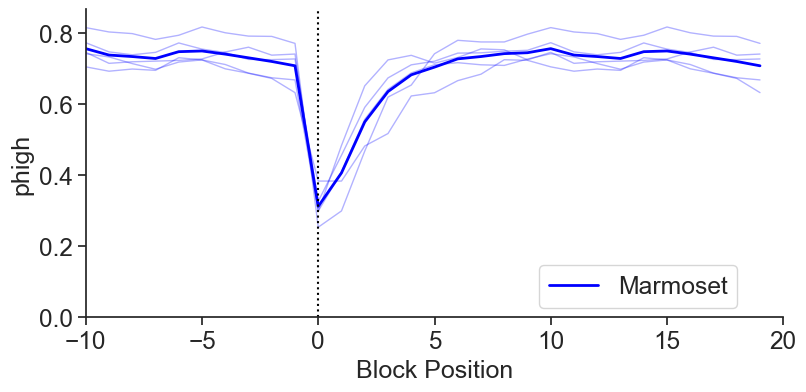

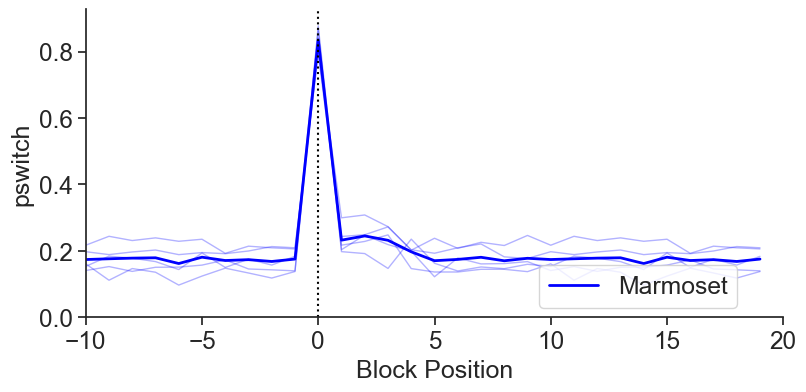

In [ ]:
mice = subset_df['treatment'].unique()

subset_df=subset_df.rename(columns={'TrialWithinBlock':'blockTrial', 'BlockLength':'blockLength', 'Decision':'highPort'})

treat_type = subset_df['treatment'].unique()
subset_df['blockTrial'] = subset_df['blockTrial'] - 1


subset_df['block_pos_rev'] = subset_df['blockTrial'] - subset_df['blockLength'] # reverse block position from transition
# shift block_pos_rev by 1 to account for the fact that the first trial of a block is actually the last trial of the previous block
subset_df



print(len(subset_df))
# # filter out sessions with fewer than 20 trials
# for session in data['Session_ID'].unique():
#     if len(data.loc[data['Session_ID']==session]) < 20:
#         data = data.loc[data['Session_ID']!=session]
# print(len(data))


subset_df_aggregate = plots.get_block_position_summaries(subset_df)
df = bpos_summaries_by_condition(subset_df, treatments=['Marmoset'])
average_plot(subset_df, 'phigh', individual_traces=True, unit_type='Animal_Name')
average_plot(subset_df, 'pswitch', individual_traces=True, unit_type='Animal_Name')


In [ ]:
subset_df.columns

Index(['Trial', 'BlockCount', 'blockTrial', 'Block', 'Condition', 'TrialError',
       'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month', 'Day',
       'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'blockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Color_2',

In [ ]:
subset_df.highPort.mean()

np.float64(0.6852329093579406)

In [ ]:
subset_df[['highPort', 'Switch']]

,highPort,Switch
4702,0.0,NaN
4703,1.0,1.0
4704,1.0,0.0
4705,0.0,1.0
4706,1.0,1.0
...,...,...
308604,1.0,0.0
308605,1.0,0.0
308606,1.0,0.0
308607,1.0,0.0


In [ ]:
df['block_pos'].unique()


array([-18., -17., -16., -15., -14., -13., -12., -11., -10.,  -9.,  -8.,
        -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   1.,   2.,   3.,   4.,
         5.,   6.,   7.,   8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,
        16.,  17.,  18.,  19.,  20.])